# 🏆 Comprehensive Point Cloud Segmentation & Volume Estimation — Benchmarking Framework

A single, beginner-friendly notebook that **trains, profiles, and compares many algorithms**
on the same data, then benchmarks **volume estimation** against ground truth, and
automatically identifies the best methods.

| Section | What happens |
|---|---|
| 1 | Setup: config, hardware manager (GPU→CPU, OOM-proof), MLflow (URI-only) |
| 2 | Data: universal loader, **automatic multi-class discovery**, splits |
| 3 | Handcrafted point features (for classical ML & analysis) |
| 4 | **Segmentation benchmark**: Deep Learning · Classical ML · Geometry · GNN |
| 5 | Segmentation comparison tables + performance visualizations |
| 6 | **Volume estimation benchmark**: Geometry · ML regression · DL/GNN regression |
| 7 | Volume comparison vs Ground Truth + error analysis |
| 8 | Cross-benchmark analysis, overall ranking, strengths & weaknesses |
| 9 | Best-model auto-selection (only best models are saved) |
| 10 | Final inference on `data/test` + interactive Open3D visualization |

**How to use (beginners):** run top-to-bottom. Everything is controlled from the single
`CONFIG` cell — you never need to edit algorithm code. Start with `quick_mode=True`
(small subset, few epochs) to see the whole framework work end-to-end, then set
`quick_mode=False` for the full research-grade run.


## 1 · Setup — Imports, Configuration, Hardware, MLflow

In [1]:
# ================================================================ IMPORTS
# Required: torch numpy pandas scikit-learn scipy matplotlib joblib tqdm laspy open3d psutil mlflow
# Required for PT/GNN models: torch-cluster torch-scatter  (wheels matching your torch+CUDA)
# Optional: xgboost lightgbm catboost plyfile
from __future__ import annotations
import os, sys, gc, glob, json, time, math, copy, random, logging, warnings, tracemalloc
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple, Any, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.spatial import ConvexHull
from scipy.optimize import linear_sum_assignment          # Hungarian matching
from sklearn.model_selection import KFold
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              RandomForestRegressor, ExtraTreesRegressor,
                              GradientBoostingRegressor)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

def _try(name):
    try:
        return __import__(name)
    except Exception:
        return None

o3d      = _try("open3d");   HAS_OPEN3D = o3d is not None
laspy    = _try("laspy")
psutil   = _try("psutil")
mlflow   = _try("mlflow");   HAS_MLFLOW = mlflow is not None
xgboost  = _try("xgboost")
lightgbm = _try("lightgbm")
catboost = _try("catboost")

# torch-cluster / torch-scatter power the transformer & GNN benchmarks
try:
    from torch_cluster import knn as tc_knn
    from torch_scatter import scatter_softmax, scatter_add, scatter_max, scatter_mean
    HAS_SCATTER = True
except Exception:
    HAS_SCATTER = False

logging.basicConfig(level=logging.INFO, force=True,
                    format="%(asctime)s | %(levelname)-7s | %(message)s",
                    handlers=[logging.StreamHandler(sys.stdout)])
log = logging.getLogger("benchmark")
for lib, ok in [("open3d", HAS_OPEN3D), ("laspy", laspy is not None),
                ("mlflow", HAS_MLFLOW), ("psutil", psutil is not None),
                ("xgboost", xgboost is not None), ("lightgbm", lightgbm is not None),
                ("catboost", catboost is not None),
                ("torch-cluster/scatter", HAS_SCATTER)]:
    if not ok:
        log.warning("Optional dependency missing: %s -> the related benchmark "
                    "candidates will be skipped automatically", lib)
log.info("PyTorch %s | CUDA: %s", torch.__version__, torch.cuda.is_available())

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
2026-07-08 23:29:38,580 | WARNING | Optional dependency missing: mlflow -> the related benchmark candidates will be skipped automatically
2026-07-08 23:29:38,580 | WARNING | Optional dependency missing: xgboost -> the related benchmark candidates will be skipped automatically
2026-07-08 23:29:38,580 | WARNING | Optional dependency missing: lightgbm -> the related benchmark candidates will be skipped automatically
2026-07-08 23:29:38,580 | WARNING | Optional dependency missing: catboost -> the related benchmark candidates will be skipped automatically
2026-07-08 23:29:38,584 | INFO    | PyTorch 2.5.1+cu121 | CUDA: True


In [2]:
# ================================================================ CONFIGURATION
# Every knob of the whole framework lives here — nothing is hard-coded elsewhere.
CONFIG: Dict[str, Any] = {
    # ---------------- data ----------------
    "train_dir":     "data/train",     # used for train/val/test-split + CV
    "test_dir":      "data/test",      # used ONLY for final inference (Section 10)
    "gt_volume_csv": "data/gt_volume.csv",   # columns: filename,volume (class-1 objects)
    "checkpoint_dir": "checkpoints",         # ONLY best models are written here
    "file_exts":     [".las", ".laz", ".ply", ".pcd", ".xyz", ".pts", ".txt"],
    "gt_class_original": 1,       # the ORIGINAL label code whose GT volumes you have

    # ---------------- benchmark budget ----------------
    # quick_mode=True lets you validate the entire framework in minutes.
    # For the full research run set quick_mode=False (uses all files/epochs below).
    "quick_mode":        False,
    "quick": {"max_train_files": 12, "max_val_files": 4, "max_eval_files": 4,
              "epochs": 12, "chunks_per_cloud": 2},
    "full":  {"max_train_files": None, "max_val_files": None, "max_eval_files": None,
              "epochs": 400, "chunks_per_cloud": 4},

    # ---------------- which methods to benchmark (flip to skip any) ----------------
    "enabled": {
        # deep learning segmentation
        "PointNet":False, "PointNet++":False, "DGCNN":False, "PointNeXt":False,
        "PointTransformerV1":False, "PointTransformerV2":True, "PointMLP":False,
        # classical ML segmentation
        "RandomForest":True, "ExtraTrees":True, "DecisionTree":True,
        "LogisticRegression":True, "KNN":True, "SVM":True,
        "XGBoost":True, "LightGBM":True, "CatBoost":True,
        # geometry segmentation (unsupervised baselines)
        "RANSAC-Planes":True, "EuclideanClustering":True,
        "RegionGrowing":True, "ConnectedComponents":True,
        # graph neural networks
        "GCN":False, "GraphSAGE":False, "GAT":False,
        # volume: geometry
        "vol_ConvexHull":False, "vol_AlphaShape": False, "vol_VoxelSurface":False,
        "vol_VoxelColumn":False, "vol_BallPivoting": False, "vol_Poisson": False,
        # volume: ML regression
        "vol_RF":True, "vol_ExtraTrees":True, "vol_GBoost":True, "vol_SVR":True,
        "vol_XGBoost":True, "vol_LightGBM":True, "vol_CatBoost":True,
        # volume: DL / GNN regression
        "vol_MLP":False, "vol_PointNetReg":False, "vol_PointNeXtReg":False,
        "vol_PTv1Reg": False, "vol_PTv2Reg": True,      # heavier: enable if desired
        "vol_GCNReg": False, "vol_SAGEReg": False, "vol_GATReg": False,
    },

    # ---------------- shared training hyper-parameters (DL & GNN) ----------------
    "train": {"in_channels": 7, "num_points": 81920, "batch_size": 2, "lr": 5e-4, "weight_decay": 1e-4,
              "patience": 30, "val_ratio": 0.15, "test_ratio": 0.15,   # 63-file dataset -> tighter patience
              "grad_accum": 8, "amp": True},

    # ---------------- fair evaluation protocol ----------------
    # EVERY method is scored on the SAME fixed random subset of points per eval file
    # (deep models predict the full cloud first, then are indexed at these points).
    "eval_points_per_file": 60_000,

    # ---------------- classical ML protocol ----------------
    "ml": {"train_points_per_file": 4000, "knn_features": 24, "svm_cap": 40_000},

    # ---------------- geometry segmentation ----------------
    "geo": {"ransac_dist": 0.02, "ransac_min_ratio": 0.05, "ransac_max_planes": 6,
            "dbscan_eps": 0.05, "dbscan_min_pts": 20,
            "region_normal_deg": 18.0, "region_k": 16,
            "cc_voxel": 0.05},

    # ---------------- volume estimation ----------------
    "vol": {"alpha": 0.08, "voxel": 0.02, "bpa_radii": [0.02, 0.04, 0.08],
            "poisson_depth": 8, "clean_cap": 200_000,
            "reg_cv_folds": 4, "log_target": True,
            "dl_epochs": 25, "dl_points": 2048, "dl_batch": 8, "dl_patience": 6},

    # ---------------- cross-benchmark composite ranking weights ----------------
    "rank_weights": {"miou": 0.40, "dice": 0.15, "accuracy": 0.10,
                     "train_time": 0.10, "infer_time": 0.15, "memory": 0.10},

    # ---------------- visualization ----------------
    "vis": {"show_windows": True,     # set False if Open3D windows crash your kernel
            "save_ply": False,        # per spec: no output files (flip if you want .ply)
            "max_vis_samples": 3, "window": (1280, 800)},

    # ---------------- MLflow (URI-ONLY: no local folder is ever created) ----------
    "mlflow": {"enabled": True, "uri": "http://localhost:5000",
               "experiment": "pointcloud_benchmark"},

    "resume": {"enabled": True,             # skip training if a per-algorithm
                                     # checkpoint already exists in _resume_cache/
              "recompute_eval_on_skip": False},  # True = always refresh metrics
                                                  # False = trust cached metrics (fastest)
    "seed": 42,
}
BUDGET = CONFIG["quick"] if CONFIG["quick_mode"] else CONFIG["full"]
os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)

def set_seed(seed):
    """Reproducibility: one seed drives python/numpy/torch (+cuda)."""
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(CONFIG["seed"])

# -------- hard requirement check: only the two data folders are mandatory --------
_missing = [d for d in (CONFIG["train_dir"], CONFIG["test_dir"])
            if not os.path.isdir(d)]
if _missing:
    raise RuntimeError(f"REQUIRED data folder(s) missing: {_missing}. "
                       "Create data/train and data/test, then rerun.")
log.info("Data folders OK | quick_mode=%s", CONFIG["quick_mode"])

2026-07-08 23:29:38,665 | INFO    | Data folders OK | quick_mode=False


### Resume / skip-if-trained

If `CONFIG["resume"]["enabled"]` is `True` (default), every algorithm below checks
`_resume_cache/` first. If it already trained that **exact** algorithm in a previous
run, training is skipped and the cached weights are loaded directly — only
new/changed algorithms are (re)trained. Delete a specific file in
`checkpoints/_resume_cache/` (or the whole folder) to force a re-train.

In [3]:
# ================================================================ RESUME CACHE (per-algorithm)
# A per-algorithm checkpoint cache, separate from the final "best model only" output
# in CONFIG["checkpoint_dir"]. If CONFIG["resume"]["enabled"], every algorithm below
# first looks for an EXISTING checkpoint before training -- across THREE sources, in
# order: (1) this run's fast cache, (2) the canonical "best_seg_.../best_volume_..."
# name from Section 9, (3) a fuzzy scan of checkpoints/ for older/differently-named
# files from other notebooks (best_dgcnn_seg.pth, best_ptv1_seg.pth, etc.). A file is
# only ever adopted if it actually loads into the matching architecture -- any
# mismatch (wrong shapes/keys) is caught and the algorithm simply trains fresh, so a
# messy or ambiguous checkpoints/ folder can NEVER cause a crash or a silently wrong
# model, only a missed skip.
RESUME_DIR = os.path.join(CONFIG["checkpoint_dir"], "_resume_cache")
os.makedirs(RESUME_DIR, exist_ok=True)

def _resume_path(kind, name, ext):
    """kind: 'seg' or 'vol'. Returns a stable, filesystem-safe cache path."""
    safe = name.replace("+", "p").replace("/", "_").replace(" ", "_")
    return os.path.join(RESUME_DIR, f"{kind}_{safe}.{ext}")

def _legacy_best_path(kind, name, family, ext):
    """Canonical Section-9 'best model' filename from THIS notebook's own convention."""
    safe = name.replace("+", "p")
    if kind == "seg":
        return os.path.join(CONFIG["checkpoint_dir"], f"best_seg_{family}_{safe}.{ext}")
    return os.path.join(CONFIG["checkpoint_dir"], f"best_volume_{safe}.{ext}")

def _slug(s):
    """Lowercase, alnum-only normalization for fuzzy filename matching."""
    return "".join(ch for ch in s.lower() if ch.isalnum())

# Ordered MOST-SPECIFIC-FIRST: once a file is claimed by an earlier (more specific)
# entry, later/shorter entries can no longer match it, so "pointnet" never steals a
# "pointnet2"/"pointnet++" file that was already claimed by the "PointNet++" entry.
# Each entry: (name, include_tokens, exclude_tokens). A filename slug matches if
# it contains ANY include token and NONE of the exclude tokens -- the excludes
# prevent substring collisions, e.g. "gcn" is contained inside "dgcnn", and
# "pointnet" is contained inside "pointnet2"/"pointnet++".
SEG_ALIASES = [
    ("PointTransformerV2", ["pointtransformerv2", "ptv2"], []),
    ("PointTransformerV1", ["pointtransformerv1", "ptv1"], []),
    ("PointNeXt",          ["pointnext"], []),
    ("PointMLP",           ["pointmlp"], []),
    ("PointNet++",         ["pointnet2", "pointnetplusplus", "pointnetpp", "pointnet++"], []),
    ("PointNet",           ["pointnet"], ["pointnet2", "pointnetplusplus", "pointnetpp"]),
    ("DGCNN",              ["dgcnn"], []),
    ("RandomForest",       ["randomforest"], []),
    ("ExtraTrees",         ["extratrees"], []),
    ("DecisionTree",       ["decisiontree"], []),
    ("LogisticRegression", ["logisticregression"], []),
    ("KNN",                ["knn"], []),
    ("SVM",                ["svm"], []),
    ("XGBoost",            ["xgboost"], []),
    ("LightGBM",           ["lightgbm"], []),
    ("CatBoost",           ["catboost"], []),
    ("GraphSAGE",          ["graphsage"], []),
    ("GCN",                ["gcn"], ["dgcnn"]),
    ("GAT",                ["gat"], []),
]
VOL_ALIASES = [
    ("vol_PTv2Reg",        ["ptv2", "pointtransformerv2"], []),
    ("vol_PTv1Reg",        ["ptv1", "pointtransformerv1"], []),
    ("vol_SAGEReg",        ["sagereg", "graphsagereg"], []),
    ("vol_GATReg",         ["gatreg"], []),
    ("vol_GCNReg",         ["gcnreg"], ["dgcnn"]),
    ("vol_PointNeXtReg",   ["pointnextreg", "pointnext"], []),
    ("vol_PointNetReg",    ["pointnetreg"], []),         # deliberately NOT "pointnet" alone
    ("vol_ExtraTrees",     ["extratrees"], []),
    ("vol_GBoost",         ["gboost", "gradientboost"], []),
    ("vol_SVR",            ["svr"], []),
    ("vol_XGBoost",        ["xgboost"], []),
    ("vol_LightGBM",       ["lightgbm"], []),
    ("vol_CatBoost",       ["catboost"], []),
    ("vol_RF",             ["volrf"], []),               # deliberately narrow: avoid
                                                         # colliding with "RandomForest"
                                                         # segmentation files
    # vol_MLP intentionally has NO fuzzy alias: generic names like
    # "volume_regressor.joblib" are too ambiguous to auto-assign safely.
]

_CLAIMED_FILES = set()   # files adopted so far this run -> never offered twice

def _fuzzy_find(kind, name, ext):
    """Scan checkpoints/ top level for an older/differently-named file that looks
    like it belongs to `name`. Returns a path or None. Never raises."""
    table = SEG_ALIASES if kind == "seg" else VOL_ALIASES
    entry = next((e for e in table if e[0] == name), None)
    if entry is None:
        return None
    tokens, excludes = entry[1], entry[2]
    try:
        entries = [f for f in os.listdir(CONFIG["checkpoint_dir"])
                  if os.path.isfile(os.path.join(CONFIG["checkpoint_dir"], f))]
    except FileNotFoundError:
        return None
    pool_key = "seg" if kind == "seg" else ("vol", "volume", "reg")
    candidates = []
    torch_exts, sk_exts = (".pt", ".pth"), (".joblib", ".pkl")
    want_exts = torch_exts if ext in ("pt", "pth") else sk_exts
    for f in entries:
        path = os.path.join(CONFIG["checkpoint_dir"], f)
        if path in _CLAIMED_FILES:
            continue
        base, real_ext = os.path.splitext(f)
        if real_ext.lower() not in want_exts:
            continue
        slug = _slug(base)
        # restrict pool: seg files vs volume files, so e.g. "..._seg.pth" is never
        # mistaken for a volume regressor and vice versa
        looks_seg = "seg" in slug
        looks_vol = any(t in slug for t in ("volume", "volreg", "reg", "vol"))
        if kind == "seg" and not looks_seg:
            continue
        if kind == "vol" and not looks_vol:
            continue
        if any(tok in slug for tok in tokens) and not any(x in slug for x in excludes):
            candidates.append(path)
    if not candidates:
        return None
    candidates.sort(key=os.path.getmtime, reverse=True)   # newest first
    chosen = candidates[0]
    _CLAIMED_FILES.add(chosen)
    return chosen

def find_checkpoint(kind, name, ext, family=""):
    """Returns the first usable checkpoint PATH for this exact algorithm, checked
    in order: (1) fast resume cache, (2) canonical best_seg_/best_volume_ name,
    (3) fuzzy scan of checkpoints/ for older/differently-named files. Loading is
    NOT attempted here -- callers must wrap the actual torch.load/joblib.load in
    try/except and fall back to fresh training on any failure."""
    p1 = _resume_path(kind, name, ext)
    if os.path.exists(p1):
        return p1
    p2 = _legacy_best_path(kind, name, family, ext)
    if os.path.exists(p2):
        _CLAIMED_FILES.add(p2)
        return p2
    p3 = _fuzzy_find(kind, name, ext)
    if p3:
        return p3
    return None

log.info("[resume] enabled=%s | cache dir: %s",
         CONFIG["resume"]["enabled"], RESUME_DIR)

2026-07-08 23:29:38,684 | INFO    | [resume] enabled=True | cache dir: checkpoints/_resume_cache


In [4]:
# ================================================================ HARDWARE MANAGER
class HardwareManager:
    """Detects hardware, prevents OOM crashes, and profiles resource usage.

    Priority CUDA -> CPU. Strategies against VRAM exhaustion:
    dynamic batch-size halving, mixed precision, gradient accumulation,
    automatic cache cleanup, and a final permanent CPU fallback.
    """

    def __init__(self, cfg):
        self.cfg = cfg
        self.device = self._detect()
        self.amp = bool(cfg["train"]["amp"] and self.device.type == "cuda")

    def _detect(self) -> torch.device:
        if not torch.cuda.is_available():
            log.info("[HW] no CUDA -> CPU (%d threads)", os.cpu_count() or 1)
            torch.set_num_threads(max(1, (os.cpu_count() or 2) - 1))
            return torch.device("cpu")
        free, total = torch.cuda.mem_get_info()
        log.info("[HW] CUDA %s | free %.1f/%.1f GB",
                 torch.cuda.get_device_name(0), free / 1e9, total / 1e9)
        if free / 1e9 < 1.5:
            log.warning("[HW] <1.5 GB free VRAM -> CPU fallback")
            return torch.device("cpu")
        return torch.device("cuda")

    def cleanup(self):
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()

    def to_cpu(self):
        """Permanent CPU fallback (called after repeated CUDA OOM)."""
        log.warning("[HW] switching PERMANENTLY to CPU + RAM")
        self.device = torch.device("cpu")
        self.amp = False
        self.cleanup()

HW = HardwareManager(CONFIG)
DEVICE = HW.device        # convenience alias (always read HW.device after OOM events)


class Profiler:
    """Context manager: wall time + peak CPU RAM (MB) + peak GPU VRAM (MB)."""
    def __enter__(self):
        HW.cleanup()
        tracemalloc.start()
        self._rss0 = psutil.Process().memory_info().rss if psutil else 0
        self.t0 = time.perf_counter()
        return self
    def __exit__(self, *a):
        self.seconds = time.perf_counter() - self.t0
        _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
        rss = (psutil.Process().memory_info().rss - self._rss0) if psutil else 0
        self.cpu_mb = max(peak, rss) / 1e6
        self.gpu_mb = (torch.cuda.max_memory_allocated() / 1e6
                       if torch.cuda.is_available() else 0.0)

2026-07-08 23:29:38,805 | INFO    | [HW] CUDA NVIDIA GeForce RTX 3060 | free 12.4/12.5 GB


In [5]:
# ================================================================ MLFLOW (URI-ONLY)
class MLflowTracker:
    """Logs every benchmark run to the tracking SERVER at CONFIG['mlflow']['uri'].
    Never creates local files/folders. Unreachable server -> silent no-op."""

    def __init__(self, cfg):
        self.enabled = bool(cfg["mlflow"]["enabled"] and HAS_MLFLOW)
        self.active = 0
        if not self.enabled:
            log.warning("[MLflow] disabled/missing -> tracking is a no-op")
            return
        os.environ.setdefault("MLFLOW_HTTP_REQUEST_TIMEOUT", "5")
        try:
            mlflow.set_tracking_uri(cfg["mlflow"]["uri"])
            from mlflow.tracking import MlflowClient
            MlflowClient(tracking_uri=cfg["mlflow"]["uri"]).search_experiments(max_results=1)
            mlflow.set_experiment(cfg["mlflow"]["experiment"])
            log.info("[MLflow] tracking -> %s", cfg["mlflow"]["uri"])
        except Exception as e:
            log.warning("[MLflow] server unreachable (%s) -> no-op. Start it with: "
                        "mlflow server --host 127.0.0.1 --port 5000 "
                        "--backend-store-uri sqlite:////your/store/mlflow.db", e)
            self.enabled = False

    def start(self, name, nested=False, tags=None):
        if self.enabled:
            mlflow.start_run(run_name=name, nested=nested, tags=tags or {})
            self.active += 1
    def end(self):
        if self.enabled and self.active:
            mlflow.end_run(); self.active -= 1
    def params(self, d):
        if self.enabled and self.active:
            mlflow.log_params({k: str(v)[:490] for k, v in d.items()})
    def metrics(self, d, step=None):
        if self.enabled and self.active:
            clean = {k: float(v) for k, v in d.items()
                     if v is not None and np.isfinite(float(v))}
            if clean:
                mlflow.log_metrics(clean, step=step)
    def tag(self, k, v):
        if self.enabled and self.active:
            mlflow.set_tag(k, str(v))
    def artifact(self, path):
        if self.enabled and self.active and os.path.exists(path):
            mlflow.log_artifact(path)

TRACKER = MLflowTracker(CONFIG)

2026-07-08 23:29:38,813 | WARNING | [MLflow] disabled/missing -> tracking is a no-op


## 2 · Data — Universal Loader, **Automatic Multi-Class Discovery**, Splits

The loader picks the right reader from the file extension. Class handling is fully
automatic: we scan the training labels, find every distinct class code (e.g. LAS
classification values), and build a remap `original code → 0..K-1`. The number of
classes, model output layers, loss, metrics, palette — everything downstream adapts
to `NUM_CLASSES` with **no hard-coded class count anywhere**.

In [6]:
# ================================================================ UNIVERSAL LOADER
LABEL_KEYS = ("label", "labels", "classification", "class",
              "scalar_label", "scalar_classification", "seg", "pred")

def _load_las(path):
    assert laspy is not None, "pip install laspy for .las/.laz"
    las = laspy.read(path)
    pts = np.column_stack((np.asarray(las.x), np.asarray(las.y),
                           np.asarray(las.z))).astype(np.float64)
    lbl = None
    dims = set(las.point_format.dimension_names)
    for key in LABEL_KEYS:
        if key in dims:
            lbl = np.asarray(las[key], dtype=np.int64); break
    return pts, lbl

def _load_ply(path):
    try:
        from plyfile import PlyData
        v = PlyData.read(path)["vertex"]
        pts = np.column_stack((v["x"], v["y"], v["z"])).astype(np.float64)
        lbl = None
        for key in LABEL_KEYS:
            if key in (v.data.dtype.names or ()):
                lbl = np.asarray(v[key], dtype=np.int64); break
        return pts, lbl
    except Exception:
        assert HAS_OPEN3D, "pip install plyfile or open3d for .ply"
        return np.asarray(o3d.io.read_point_cloud(path).points, np.float64), None

def _load_pcd(path):
    assert HAS_OPEN3D, "pip install open3d for .pcd"
    lbl = None
    try:
        tp = o3d.t.io.read_point_cloud(path)
        pts = tp.point["positions"].numpy().astype(np.float64)
        for key in LABEL_KEYS:
            if key in tp.point:
                lbl = tp.point[key].numpy().reshape(-1).astype(np.int64); break
    except Exception:
        pts = np.asarray(o3d.io.read_point_cloud(path).points, np.float64)
    return pts, lbl

def _load_text(path):
    for kw in (dict(), dict(delimiter=","), dict(skiprows=1),
               dict(delimiter=",", skiprows=1)):
        try:
            arr = np.loadtxt(path, **kw); break
        except ValueError:
            arr = None
    if arr is None:
        arr = np.genfromtxt(path, delimiter=",", skip_header=1)
    arr = np.asarray(arr, np.float64)
    lbl = arr[:, 3].astype(np.int64) if arr.shape[1] >= 4 else None
    return arr[:, :3], lbl

def load_pointcloud(path):
    """(points[N,3] float64, raw labels[N] int64 or None) for any supported format."""
    ext = os.path.splitext(path)[1].lower()
    if ext in (".las", ".laz"): return _load_las(path)
    if ext == ".ply":           return _load_ply(path)
    if ext == ".pcd":           return _load_pcd(path)
    return _load_text(path)     # .xyz .pts .txt

def list_files(folder):
    out = []
    for e in CONFIG["file_exts"]:
        out += glob.glob(os.path.join(folder, "*" + e))
    return sorted(out)

# ================================================================ AUTO CLASS DISCOVERY
TRAIN_FILES_ALL = list_files(CONFIG["train_dir"])
TEST_FILES      = list_files(CONFIG["test_dir"])
assert TRAIN_FILES_ALL, f"No supported point clouds in {CONFIG['train_dir']}"
log.info("Found %d train files, %d final-inference files",
         len(TRAIN_FILES_ALL), len(TEST_FILES))

def discover_classes(files, scan_limit=40):
    """Scan training labels -> sorted unique original codes -> remap to 0..K-1."""
    found = set()
    for f in tqdm(files[:scan_limit], desc="class discovery", leave=False):
        _, lbl = load_pointcloud(f)
        if lbl is not None:
            found |= set(np.unique(lbl).tolist())
    assert found, "No labels found in training files — segmentation needs labels."
    original = sorted(found)
    remap = {orig: i for i, orig in enumerate(original)}
    return original, remap

ORIGINAL_CODES, CLASS_REMAP = discover_classes(TRAIN_FILES_ALL)
NUM_CLASSES = len(ORIGINAL_CODES)
CLASS_NAMES = {CLASS_REMAP[o]: f"Class_{o}" for o in ORIGINAL_CODES}
GT_CLASS = CLASS_REMAP.get(CONFIG["gt_class_original"], None)  # remapped id of the GT-volume class
_remap_lut_max = max(ORIGINAL_CODES) + 1
REMAP_LUT = np.zeros(_remap_lut_max, dtype=np.int64)
for o, i in CLASS_REMAP.items():
    REMAP_LUT[o] = i
log.info("Discovered %d classes: %s (GT-volume class -> id %s)",
         NUM_CLASSES, CLASS_REMAP, GT_CLASS)

def sanitize_labels(lbl):
    """Original codes -> contiguous 0..K-1 ids; unseen/out-of-range codes -> 0."""
    if lbl is None:
        return None
    lbl = np.asarray(lbl, dtype=np.int64).copy()
    bad = (lbl < 0) | (lbl >= _remap_lut_max)
    lbl[bad] = ORIGINAL_CODES[0]
    return REMAP_LUT[lbl]

# ---------------- automatic distinguishable palette (Class0 gray, then vivid) ----------
def make_palette(k):
    base = np.array([[0.55, 0.55, 0.55], [0.90, 0.10, 0.10], [0.00, 0.75, 0.00],
                     [0.10, 0.30, 0.95], [0.95, 0.75, 0.05], [0.75, 0.10, 0.85],
                     [0.05, 0.85, 0.85], [0.95, 0.45, 0.05]])
    if k <= len(base):
        return base[:k]
    extra = plt.cm.hsv(np.linspace(0, 1, k - len(base), endpoint=False))[:, :3]
    return np.vstack([base, extra])
PALETTE = make_palette(NUM_CLASSES)
DARK_COLORS = np.array([
    # [0.35, 0.35, 0.35],   # dark gray
    [0.60, 0.05, 0.05],   # dark red
    [0.05, 0.10, 0.55],   # dark blue
    [0.45, 0.25, 0.05],   # brown
    [0.40, 0.05, 0.45],   # dark purple
    [0.05, 0.35, 0.40],   # dark teal
    [0.30, 0.30, 0.05],   # olive
])
PALETTE = np.zeros((NUM_CLASSES, 3))
_di = 0
for c in range(NUM_CLASSES):
    if c == GT_CLASS:
        PALETTE[c] = [0.0, 0.75, 0.0]                 # target -> green
    else:
        PALETTE[c] = DARK_COLORS[_di % len(DARK_COLORS)]
        _di += 1
# ================================================================ SPLITS + GT VOLUMES
rng = np.random.RandomState(CONFIG["seed"])
_perm = rng.permutation(len(TRAIN_FILES_ALL))
_nv = max(1, int(len(TRAIN_FILES_ALL) * CONFIG["train"]["val_ratio"]))
_nt = max(1, int(len(TRAIN_FILES_ALL) * CONFIG["train"]["test_ratio"]))
SPLIT = {
    "train": [TRAIN_FILES_ALL[i] for i in _perm[_nv + _nt:]][:BUDGET["max_train_files"]],
    "val":   [TRAIN_FILES_ALL[i] for i in _perm[:_nv]][:BUDGET["max_val_files"]],
    "eval":  [TRAIN_FILES_ALL[i] for i in _perm[_nv:_nv + _nt]][:BUDGET["max_eval_files"]],
}
log.info("Split -> train %d | val %d | eval(held-out test) %d",
         len(SPLIT["train"]), len(SPLIT["val"]), len(SPLIT["eval"]))

def load_gt_volumes(csv_path):
    if not os.path.exists(csv_path):
        log.warning("GT volume CSV missing (%s) -> volume benchmark limited to "
                    "geometry methods without error analysis", csv_path)
        return {}
    df = pd.read_csv(csv_path)
    cols = {c.lower().strip(): c for c in df.columns}
    fcol = cols.get("filename") or cols.get("file") or df.columns[0]
    vcol = cols.get("volume") or df.columns[1]
    return {os.path.splitext(os.path.basename(str(r[fcol])))[0]: float(r[vcol])
            for _, r in df.iterrows()}
GT_VOLUMES = load_gt_volumes(CONFIG["gt_volume_csv"])
log.info("GT volumes: %d entries", len(GT_VOLUMES))

2026-07-08 23:29:38,861 | INFO    | Found 45 train files, 18 final-inference files


class discovery:   0%|          | 0/40 [00:00<?, ?it/s]

2026-07-08 23:29:39,505 | INFO    | Discovered 2 classes: {0: 0, 1: 1} (GT-volume class -> id 1)
2026-07-08 23:29:39,506 | INFO    | Split -> train 33 | val 6 | eval(held-out test) 6
2026-07-08 23:29:39,510 | INFO    | GT volumes: 63 entries


In [7]:
# ================================================================ DATASET & CACHE
class CloudCache:
    """Bounded in-RAM cache: normalized cloud + remapped labels + eval indices.
    (No disk cache — the framework writes nothing except best models.)"""
    def __init__(self, limit=24):
        self.limit, self._d, self._order = limit, {}, []

    def get(self, path):
        if path in self._d:
            return self._d[path]
        pts, lbl = load_pointcloud(path)
        lbl = sanitize_labels(lbl)
        center = pts.mean(axis=0, keepdims=True)
        scale = max(np.linalg.norm(pts - center, axis=1).max(), 1e-9)
        norm = ((pts - center) / scale).astype(np.float32)
        # ---- 7-channel per-point features: [norm-xyz, height-above-floor, normals]
        height = ((pts[:, 2] - pts[:, 2].min())
                  / max(pts[:, 2].max() - pts[:, 2].min(), 1e-6)).astype(np.float32)
        if HAS_OPEN3D:
            _p = o3d.geometry.PointCloud()
            _p.points = o3d.utility.Vector3dVector(pts)
            _p.estimate_normals(o3d.geometry.KDTreeSearchParamKNN(16))
            _p.orient_normals_to_align_with_direction([0.0, 0.0, 1.0])
            normals = np.asarray(_p.normals).astype(np.float32)
        else:
            normals = np.zeros_like(norm)
        feat = np.column_stack([norm, height[:, None], normals]).astype(np.float32)
        r = np.random.RandomState(abs(hash(os.path.basename(path))) % (2**31))
        n_eval = min(CONFIG["eval_points_per_file"], len(pts))
        entry = dict(raw=pts, norm=norm, feat=feat, lbl=lbl, center=center,
                     scale=scale,
                     eval_idx=r.choice(len(pts), n_eval, replace=False))
        self._d[path] = entry; self._order.append(path)
        if len(self._order) > self.limit:
            self._d.pop(self._order.pop(0), None)
        return entry

CACHE = CloudCache()

class ChunkDataset(Dataset):
    """Training samples for deep/GNN models: random contiguous chunks of
    `num_points` from a spatially sorted cloud -> (3,N) tensor + labels."""
    def __init__(self, files, augment=True):
        self.files, self.augment = list(files), augment
        self.cpc = BUDGET["chunks_per_cloud"]
        self.N = CONFIG["train"]["num_points"]

    def __len__(self): return len(self.files) * self.cpc

    def __getitem__(self, i):
        e = CACHE.get(self.files[i // self.cpc])
        pts, lbl = e["norm"], e["lbl"]          # xyz used for sphere-crop only
        n = len(pts)
        if n <= self.N:
            idx = np.random.choice(n, self.N, replace=True)
        else:                                   # sphere crop keeps local structure intact
            seed = np.random.randint(n)
            d2 = ((pts - pts[seed]) ** 2).sum(1)
            idx = np.argpartition(d2, self.N - 1)[:self.N]
        x, y = e["feat"][idx].copy(), lbl[idx].copy()       # (N,7)
        if self.augment:                        # rotate xyz AND normals (z-axis safe)
            th = np.random.uniform(0, 2 * np.pi); c, s = np.cos(th), np.sin(th)
            R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], np.float32)
            x[:, :3] = x[:, :3] @ R.T * np.random.uniform(0.9, 1.1) + \
                np.random.normal(0, 0.002, (len(x), 3)).astype(np.float32)
            x[:, 4:7] = x[:, 4:7] @ R.T
        return torch.from_numpy(x.T), torch.from_numpy(y)   # (7,N), (N,)

def make_loader(files, shuffle, batch=None):
    return DataLoader(ChunkDataset(files, augment=shuffle),
                      batch_size=batch or CONFIG["train"]["batch_size"],
                      shuffle=shuffle, num_workers=0, drop_last=shuffle,
                      pin_memory=(HW.device.type == "cuda"))

def class_weights(files, sample=30):
    counts = np.zeros(NUM_CLASSES)
    for f in files[:sample]:
        counts += np.bincount(CACHE.get(f)["lbl"], minlength=NUM_CLASSES)
    w = 1.0 / np.clip(counts / counts.sum(), 1e-6, None)
    w = w / w.sum() * NUM_CLASSES
    log.info("class weights: %s", np.round(w, 3))
    return torch.tensor(w, dtype=torch.float32)

CLASS_W = class_weights(SPLIT["train"])

2026-07-08 23:29:45,260 | INFO    | class weights: [1.24 0.76]


## 3 · Handcrafted Point Features (for Classical ML)

Classical models cannot "see" raw XYZ context, so we describe each point with
geometry features computed from its k-nearest neighbourhood: **eigen-features**
(linearity, planarity, sphericity from the local covariance), height above the
local floor, normal verticality, and local density. These are the standard
features used in the point cloud classification literature.

In [8]:
# ================================================================ POINT FEATURES
FEATURE_NAMES = ["z_rel", "nz_abs", "linearity", "planarity", "sphericity",
                 "curvature", "density", "height_range"]

def point_features(pts_norm, idx=None):
    """Per-point handcrafted features (rows follow `idx` if given, else all points).
    Uses an Open3D KD-tree for kNN neighbourhoods; NumPy fallback for small clouds."""
    k = CONFIG["ml"]["knn_features"]
    q = pts_norm if idx is None else pts_norm[idx]
    z = pts_norm[:, 2]
    z_rel = (q[:, 2] - z.min()) / max(z.max() - z.min(), 1e-9)

    if HAS_OPEN3D and len(pts_norm) > 2000:
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts_norm.astype(np.float64))
        tree = o3d.geometry.KDTreeFlann(pcd)
        neigh = np.empty((len(q), k), np.int64)
        for i, p in enumerate(q):
            _, nn, _ = tree.search_knn_vector_3d(p.astype(np.float64), k)
            neigh[i] = np.asarray(nn)[:k]
    else:                                              # tiny clouds: brute force
        d2 = ((q[:, None, :] - pts_norm[None]) ** 2).sum(-1)
        neigh = np.argsort(d2, axis=1)[:, :k]

    nb = pts_norm[neigh]                               # (M,k,3)
    mu = nb.mean(1, keepdims=True)
    cov = np.einsum("mki,mkj->mij", nb - mu, nb - mu) / k
    ev = np.linalg.eigvalsh(cov)                       # ascending l3<=l2<=l1
    l3, l2, l1 = ev[:, 0], ev[:, 1], ev[:, 2]
    s = np.clip(l1, 1e-12, None)
    linearity = (l1 - l2) / s
    planarity = (l2 - l3) / s
    sphericity = l3 / s
    curvature = l3 / np.clip(l1 + l2 + l3, 1e-12, None)
    # normal = eigenvector of smallest eigenvalue -> |z| = verticality proxy
    w, V = np.linalg.eigh(cov)
    nz_abs = np.abs(V[:, 2, 0])
    r_k = np.linalg.norm(nb[:, -1, :] - q, axis=1)     # distance to k-th neighbour
    density = k / np.clip((4 / 3) * np.pi * r_k ** 3, 1e-9, None)
    height_range = nb[:, :, 2].max(1) - nb[:, :, 2].min(1)
    X = np.column_stack([z_rel, nz_abs, linearity, planarity, sphericity,
                         curvature, np.log1p(density), height_range]).astype(np.float32)
    return np.nan_to_num(X)

## 4 · Segmentation Benchmark — Common Machinery

Every method (any family) is scored **identically**: it must label the *same* fixed
random subset of points in each held-out eval file. Deep models label the full cloud
(chunked, OOM-safe) and are then indexed at those points. The registry below collects
one `SegResult` per method — metrics, timings, memory — which Section 5 turns into
comparison tables and charts. Each method is also logged as a nested MLflow run.

In [9]:
# ================================================================ METRICS
def confusion(gt, pred, k=None):
    k = k or NUM_CLASSES
    return np.bincount(gt * k + pred, minlength=k * k).reshape(k, k)

def seg_metrics(conf):
    """Accuracy, per-class precision/recall/F1/IoU/Dice, macro means (NaN-safe)."""
    conf = conf.astype(np.float64)
    out = {"accuracy": float(np.diag(conf).sum() / max(conf.sum(), 1))}
    ious, dices, f1s, precs, recs = [], [], [], [], []
    for c in range(conf.shape[0]):
        tp = conf[c, c]; fp = conf[:, c].sum() - tp; fn = conf[c, :].sum() - tp
        prec = tp / (tp + fp) if tp + fp > 0 else 0.0
        rec = tp / (tp + fn) if tp + fn > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if prec + rec > 0 else 0.0
        iou = tp / (tp + fp + fn) if tp + fp + fn > 0 else float("nan")
        dice = 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn > 0 else float("nan")
        out[f"iou_{c}"] = float(iou); out[f"dice_{c}"] = float(dice)
        ious.append(iou); dices.append(dice); f1s.append(f1)
        precs.append(prec); recs.append(rec)
    out.update(miou=float(np.nanmean(ious)), dice=float(np.nanmean(dices)),
               f1=float(np.mean(f1s)), precision=float(np.mean(precs)),
               recall=float(np.mean(recs)))
    return out

def volume_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    ok = np.isfinite(y_pred) & np.isfinite(y_true)
    if ok.sum() < 1:
        return {m: float("nan") for m in
                ("MAE", "RMSE", "MSE", "RelErr", "PctErr", "R2")} | {"n": 0}
    yt, yp = y_true[ok], y_pred[ok]
    rel = np.abs(yp - yt) / np.clip(np.abs(yt), 1e-9, None)
    return {"MAE": float(np.abs(yp - yt).mean()),
            "RMSE": float(np.sqrt(((yp - yt) ** 2).mean())),
            "MSE": float(((yp - yt) ** 2).mean()),
            "RelErr": float(rel.mean()), "PctErr": float(rel.mean() * 100),
            "R2": float(r2_score(yt, yp)) if ok.sum() > 1 else float("nan"),
            "n": int(ok.sum())}

# ================================================================ REGISTRY
@dataclass
class SegResult:
    name: str; family: str
    metrics: Dict[str, float] = field(default_factory=dict)
    conf: Optional[np.ndarray] = None
    train_time: float = 0.0; infer_time: float = 0.0
    gpu_mb: float = 0.0; cpu_mb: float = 0.0
    history: List[Dict] = field(default_factory=list)   # per-epoch curves (DL/GNN)
    predictor: Any = None                               # callable(entry)->labels@eval_idx
    model: Any = None                                   # for best-model saving

SEG_RESULTS: Dict[str, SegResult] = {}

def register_seg(res: SegResult):
    SEG_RESULTS[res.name] = res
    m = res.metrics
    log.info("[%s/%s] acc %.4f | mIoU %.4f | Dice %.4f | train %.1fs | infer %.2fs/file",
             res.family, res.name, m["accuracy"], m["miou"], m["dice"],
             res.train_time, res.infer_time)

def evaluate_predictor(predict_fn, files):
    """Fair protocol: labels at the fixed eval points of every eval file."""
    conf = np.zeros((NUM_CLASSES, NUM_CLASSES), np.int64)
    t = 0.0
    for f in files:
        e = CACHE.get(f)
        t0 = time.perf_counter()
        pred = predict_fn(e)                     # labels at e["eval_idx"]
        t += time.perf_counter() - t0
        conf += confusion(e["lbl"][e["eval_idx"]], np.asarray(pred, np.int64))
    return seg_metrics(conf), conf, t / max(len(files), 1)

In [10]:
# ================================================================ TORCH HARNESS
# One training loop shared by every deep / GNN model:
#   AMP + gradient accumulation + dynamic batch halving on CUDA OOM
#   + permanent CPU fallback + early stopping on val mIoU. No files are written.
def train_torch_seg(model, name):
    epochs, pat = BUDGET["epochs"], CONFIG["train"]["patience"]
    batch = CONFIG["train"]["batch_size"]
    accum = max(1, CONFIG["train"]["grad_accum"])
    crit = nn.CrossEntropyLoss(weight=CLASS_W.to(HW.device))
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["train"]["lr"],
                            weight_decay=CONFIG["train"]["weight_decay"])
    scaler = torch.amp.GradScaler(enabled=HW.amp)
    best_state, best_miou, bad, history = None, -1.0, 0, []

    def run_epoch(loader, training):
        nonlocal batch
        model.train(training)
        tot, conf = 0.0, np.zeros((NUM_CLASSES, NUM_CLASSES), np.int64)
        ctx = torch.enable_grad() if training else torch.no_grad()
        with ctx:
            for step, (x, y) in enumerate(loader):
                try:
                    x, y = x.to(HW.device), y.to(HW.device)
                    with torch.autocast(HW.device.type, enabled=HW.amp):
                        logits = model(x)                       # (B,C,N)
                        loss = crit(logits, y) / accum
                    if training:
                        scaler.scale(loss).backward()
                        if (step + 1) % accum == 0:
                            scaler.step(opt); scaler.update()
                            opt.zero_grad(set_to_none=True)
                except torch.cuda.OutOfMemoryError:
                    # OOM strategy: halve batch, retry epoch; batch==1 -> CPU forever
                    HW.cleanup()
                    if batch > 1:
                        batch = max(1, batch // 2)
                        log.warning("[%s] CUDA OOM -> retrying with batch=%d", name, batch)
                    else:
                        HW.to_cpu(); model.to(HW.device)
                        crit.to(HW.device)
                        for st in opt.state.values():
                            for k2, v2 in st.items():
                                if torch.is_tensor(v2):
                                    st[k2] = v2.cpu()
                    raise _RetryEpoch()
                tot += loss.item() * accum * x.size(0)
                conf_local = confusion(y.cpu().numpy().ravel(),
                                       logits.argmax(1).detach().cpu().numpy().ravel())
                conf += conf_local
        return tot / max(len(loader.dataset), 1), seg_metrics(conf)

    class _RetryEpoch(Exception): pass

    model.to(HW.device)
    ep = 1
    while ep <= epochs:
        try:
            tr = make_loader(SPLIT["train"], True, batch)
            va = make_loader(SPLIT["val"], False, batch)
            tr_loss, tr_m = run_epoch(tr, True)
            va_loss, va_m = run_epoch(va, False)
        except _RetryEpoch:
            continue                                   # same epoch, new batch/device
        history.append({"epoch": ep, "train_loss": tr_loss, "val_loss": va_loss,
                        "train_miou": tr_m["miou"], "val_miou": va_m["miou"],
                        "val_dice": va_m["dice"], "val_acc": va_m["accuracy"]})
        TRACKER.metrics({"train_loss": tr_loss, "val_loss": va_loss,
                         "val_miou": va_m["miou"], "val_dice": va_m["dice"],
                         "val_accuracy": va_m["accuracy"]}, step=ep)
        star = ""
        if va_m["miou"] > best_miou + 1e-4:
            best_miou, bad = va_m["miou"], 0
            best_state = copy.deepcopy(model.state_dict()); star = "  *best"
        else:
            bad += 1
        log.info("[%s] ep %02d | tr %.4f | va %.4f | val mIoU %.4f%s",
                 name, ep, tr_loss, va_loss, va_m["miou"], star)
        if bad >= pat:
            log.info("[%s] early stop (no val mIoU gain for %d epochs)", name, pat)
            break
        ep += 1
    if best_state:
        model.load_state_dict(best_state)
    return model, history

@torch.no_grad()
def predict_full_cloud(model, entry, chunk=None):
    """Label EVERY point: shuffled fixed-size chunks -> batched forward -> scatter.
    Halves the chunk batch on OOM; final resort CPU."""
    model.eval(); model.to(HW.device)          # reload to GPU on demand
    N = CONFIG["train"]["num_points"]
    B = chunk or CONFIG["train"]["batch_size"]
    pts = entry["feat"]                          # (N,7) features
    n = len(pts)
    perm = np.random.RandomState(0).permutation(n)
    pad = (N - n % N) % N
    if pad:
        perm = np.concatenate([perm, perm[:pad]])
    chunks = perm.reshape(-1, N)
    out = np.zeros(n, np.int64)
    i = 0
    while i < len(chunks):
        cid = chunks[i:i + B]
        x = torch.from_numpy(pts[cid].transpose(0, 2, 1)).to(HW.device)
        try:
            pred = model(x).argmax(1).cpu().numpy()
        except torch.cuda.OutOfMemoryError:
            HW.cleanup()
            if B > 1:
                B = max(1, B // 2); continue
            HW.to_cpu(); model.to(HW.device); continue
        out[cid.ravel()] = pred.ravel()
        i += B
    return out

def benchmark_torch_model(name, family, build_fn):
    """Full pipeline for one deep/GNN model: train -> eval -> profile -> register."""
    if not CONFIG["enabled"].get(name, False):
        log.info("[skip] %s disabled in CONFIG", name); return
    if family in ("DeepLearning", "GNN") and name.startswith(("PointTransformer", "G")) \
       and not HAS_SCATTER:
        log.warning("[skip] %s needs torch-cluster/torch-scatter", name); return
    cache_path = _resume_path("seg", name, "pt")
    found_path = find_checkpoint("seg", name, "pt", family) \
        if CONFIG["resume"]["enabled"] else None
    if found_path:
        try:
            ckpt = torch.load(found_path, map_location="cpu", weights_only=False)
            model = build_fn(); model.load_state_dict(ckpt["model_state"])
        except Exception as e:
            log.warning("[resume] %s -> candidate %s did not load (%s) -> "
                       "training fresh instead", name, found_path, e)
            found_path = None
        if found_path:
            log.info("[resume] %s -> found existing checkpoint (%s), SKIPPING training",
                     name, found_path)
            def predictor(entry, _m=model):
                out = predict_full_cloud(_m, entry)[entry["eval_idx"]]
                _m.to("cpu"); HW.cleanup()
                return out
            _ckpt_complete = all(k in ckpt for k in ("metrics", "conf", "infer_time"))
            if CONFIG["resume"]["recompute_eval_on_skip"] or not _ckpt_complete:
                with Profiler() as p_ev:
                    metrics, conf, per_file = evaluate_predictor(predictor, SPLIT["eval"])
            else:
                metrics, conf, per_file = ckpt["metrics"], ckpt["conf"], ckpt["infer_time"]
            register_seg(SegResult(name=name, family=family, metrics=metrics, conf=conf,
                                   train_time=ckpt.get("train_time", 0.0), infer_time=per_file,
                                   gpu_mb=ckpt.get("gpu_mb", 0.0), cpu_mb=ckpt.get("cpu_mb", 0.0),
                                   history=ckpt.get("history", []), predictor=predictor,
                                   model=model))
            if CONFIG["resume"]["enabled"] and found_path != cache_path:
                torch.save(ckpt, cache_path)   # adopt legacy file into the fast-path cache
            return

    HW.cleanup(); set_seed(CONFIG["seed"])
    TRACKER.start(f"seg_{name}", nested=True,
                  tags={"family": family, "phase": "segmentation"})
    TRACKER.params({"model": name, "epochs": BUDGET["epochs"],
                    "num_points": CONFIG["train"]["num_points"],
                    "num_classes": NUM_CLASSES, "quick_mode": CONFIG["quick_mode"]})
    with Profiler() as p_tr:
        model = build_fn()
        model, history = train_torch_seg(model, name)
    def predictor(entry, _m=model):
        out = predict_full_cloud(_m, entry)[entry["eval_idx"]]
        _m.to("cpu"); HW.cleanup()               # release VRAM after each file batch
        return out
    with Profiler() as p_ev:
        metrics, conf, per_file = evaluate_predictor(predictor, SPLIT["eval"])
    model.to("cpu"); HW.cleanup()                # model done -> weights to RAM, VRAM free
    TRACKER.metrics({f"test_{k}": v for k, v in metrics.items()
                     if isinstance(v, float)})
    TRACKER.metrics({"train_time_s": p_tr.seconds, "infer_time_s_per_file": per_file,
                     "gpu_peak_mb": max(p_tr.gpu_mb, p_ev.gpu_mb),
                     "cpu_peak_mb": max(p_tr.cpu_mb, p_ev.cpu_mb)})
    TRACKER.end()
    register_seg(SegResult(name=name, family=family, metrics=metrics, conf=conf,
                           train_time=p_tr.seconds, infer_time=per_file,
                           gpu_mb=max(p_tr.gpu_mb, p_ev.gpu_mb),
                           cpu_mb=max(p_tr.cpu_mb, p_ev.cpu_mb),
                           history=history, predictor=predictor, model=model))
    if CONFIG["resume"]["enabled"]:
        torch.save({"model_state": model.state_dict(), "metrics": metrics, "conf": conf,
                   "train_time": p_tr.seconds, "infer_time": per_file,
                   "gpu_mb": max(p_tr.gpu_mb, p_ev.gpu_mb),
                   "cpu_mb": max(p_tr.cpu_mb, p_ev.cpu_mb), "history": history},
                  cache_path)
        log.info("[resume] %s -> cached at %s", name, cache_path)

### 4a · Deep Learning Models

All seven share one interface — `model(x)` with `x (B,3,N)` → logits `(B,C,N)`, and
`model(x, return_embedding=True)` → a global feature (reused later for DL volume
regression). One-line intuition for each:

- **PointNet** — per-point MLP + global max-pool: fast baseline, no local context.
- **PointNet++** — hierarchical FPS + ball-query grouping: adds local neighbourhoods.
- **DGCNN** — EdgeConv on a *dynamically recomputed* kNN graph in feature space.
- **PointNeXt** — PointNet++ modernized with residual InvResMLP blocks.
- **PointTransformer V1** — vector attention over kNN (softmax over *neighbours*).
- **PointTransformer V2** — grouped vector attention + grid pooling.
- **PointMLP** — pure residual MLPs with a geometric affine normalization; shows how
  far you can get *without* attention or graphs.

In [11]:
# ================================================================ POINTNET & POINTNET++
IN_CH = CONFIG["train"]["in_channels"]

class PointNetSeg(nn.Module):
    """PointNet: shared per-point MLPs + a global max-pooled context vector that is
    concatenated back to every point. No neighbourhood information."""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv1d(IN_CH, 64, 1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 128, 1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, 1024, 1), nn.BatchNorm1d(1024), nn.ReLU())
        self.head = nn.Sequential(
            nn.Conv1d(1024 + 128, 256, 1), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Conv1d(256, 128, 1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout(0.4), nn.Conv1d(128, num_classes, 1))
        self.mid = nn.Sequential(nn.Conv1d(IN_CH, 64, 1), nn.BatchNorm1d(64), nn.ReLU(),
                                 nn.Conv1d(64, 128, 1), nn.BatchNorm1d(128), nn.ReLU())
        self.emb_dims = 1024

    def forward(self, x, return_embedding=False):
        g = self.enc(x).max(-1)[0]                       # (B,1024) global feature
        if return_embedding:
            return g
        local = self.mid(x)                              # (B,128,N)
        gexp = g.unsqueeze(-1).expand(-1, -1, x.shape[-1])
        return self.head(torch.cat([gexp, local], 1))    # (B,C,N)


# ---- PointNet++ utilities (shared with PointNeXt) ----
def square_distance(a, b):
    return ((a[:, :, None, :] - b[:, None, :, :]) ** 2).sum(-1)

def index_points(pts, idx):
    B = pts.shape[0]
    view = [B] + [1] * (idx.dim() - 1)
    bidx = torch.arange(B, device=pts.device).view(view).expand_as(idx)
    return pts[bidx, idx]

def farthest_point_sample(xyz, npoint):
    B, N, _ = xyz.shape
    idx = torch.zeros(B, npoint, dtype=torch.long, device=xyz.device)
    dist = torch.full((B, N), 1e10, device=xyz.device)
    far = torch.randint(0, N, (B,), device=xyz.device)
    b = torch.arange(B, device=xyz.device)
    for i in range(npoint):
        idx[:, i] = far
        d = ((xyz - xyz[b, far].unsqueeze(1)) ** 2).sum(-1)
        dist = torch.minimum(dist, d)
        far = dist.argmax(-1)
    return idx

def query_ball_point(radius, nsample, xyz, new_xyz):
    B, N, _ = xyz.shape
    nsample = min(nsample, N)          # FIX: never request more neighbours than points
    S = new_xyz.shape[1]
    group = torch.arange(N, device=xyz.device).view(1, 1, N).repeat(B, S, 1)
    group[square_distance(new_xyz, xyz) > radius ** 2] = N
    group = group.sort(-1)[0][:, :, :nsample]
    first = group[:, :, :1].expand(-1, -1, nsample)
    mask = group == N
    group[mask] = first[mask]
    return group

class SetAbstraction(nn.Module):
    def __init__(self, npoint, radius, nsample, in_ch, mlp):
        super().__init__()
        self.npoint, self.radius, self.nsample = npoint, radius, nsample
        layers, last = [], in_ch + 3
        for out in mlp:
            layers += [nn.Conv2d(last, out, 1), nn.BatchNorm2d(out), nn.ReLU()]
            last = out
        self.mlp = nn.Sequential(*layers)

    def forward(self, xyz, feats):
        xyz_t = xyz.permute(0, 2, 1)
        fps = farthest_point_sample(xyz_t, self.npoint)
        new_xyz = index_points(xyz_t, fps)
        idx = query_ball_point(self.radius, self.nsample, xyz_t, new_xyz)
        grouped = index_points(xyz_t, idx) - new_xyz.unsqueeze(2)
        if feats is not None:
            grouped = torch.cat([grouped, index_points(feats.permute(0, 2, 1), idx)], -1)
        new_feats = self.mlp(grouped.permute(0, 3, 2, 1)).max(2)[0]
        return new_xyz.permute(0, 2, 1), new_feats

class FeaturePropagation(nn.Module):
    def __init__(self, in_ch, mlp):
        super().__init__()
        layers, last = [], in_ch
        for out in mlp:
            layers += [nn.Conv1d(last, out, 1), nn.BatchNorm1d(out), nn.ReLU()]
            last = out
        self.mlp = nn.Sequential(*layers)

    def forward(self, xyz1, xyz2, f1, f2):
        x1, x2 = xyz1.permute(0, 2, 1), xyz2.permute(0, 2, 1)
        d = square_distance(x1, x2)
        d, idx = d.sort(-1)
        d, idx = d[:, :, :3].clamp(min=1e-10), idx[:, :, :3]
        w = (1.0 / d); w = w / w.sum(-1, keepdim=True)
        interp = (index_points(f2.permute(0, 2, 1), idx) * w.unsqueeze(-1)).sum(2)
        out = interp.permute(0, 2, 1)
        if f1 is not None:
            out = torch.cat([f1, out], 1)
        return self.mlp(out)

class PointNet2Seg(nn.Module):
    """PointNet++ (SSG): 4 SA encoder levels + 4 FP decoder levels."""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.sa1 = SetAbstraction(1024, 0.1, 32, IN_CH, [32, 32, 64])
        self.sa2 = SetAbstraction(256, 0.2, 32, 64, [64, 64, 128])
        self.sa3 = SetAbstraction(64, 0.4, 32, 128, [128, 128, 256])
        self.sa4 = SetAbstraction(16, 0.8, 32, 256, [256, 256, 512])
        self.fp4 = FeaturePropagation(512 + 256, [256, 256])
        self.fp3 = FeaturePropagation(256 + 128, [256, 256])
        self.fp2 = FeaturePropagation(256 + 64, [256, 128])
        self.fp1 = FeaturePropagation(128, [128, 128, 128])
        self.head = nn.Sequential(nn.Conv1d(128, 128, 1), nn.BatchNorm1d(128),
                                  nn.ReLU(), nn.Dropout(0.4),
                                  nn.Conv1d(128, num_classes, 1))
        self.emb_dims = 512

    def forward(self, x, return_embedding=False):
        xyz = x[:, :3, :].contiguous()           # coordinates = first 3 channels
        l1x, l1f = self.sa1(xyz, x)              # all 7 channels as features
        l2x, l2f = self.sa2(l1x, l1f)
        l3x, l3f = self.sa3(l2x, l2f)
        l4x, l4f = self.sa4(l3x, l3f)
        if return_embedding:
            return l4f.max(-1)[0]
        l3f = self.fp4(l3x, l4x, l3f, l4f)
        l2f = self.fp3(l2x, l3x, l2f, l3f)
        l1f = self.fp2(l1x, l2x, l1f, l2f)
        l0f = self.fp1(xyz, l1x, None, l1f)
        return self.head(l0f)

In [12]:
# ================================================================ DGCNN · POINTNEXT · POINTMLP
def knn_graph(x, k):
    """x (B,C,N) -> kNN indices (B,N,k) in feature space (the 'dynamic' in DGCNN)."""
    inner = -2 * torch.matmul(x.transpose(2, 1), x)
    xx = (x ** 2).sum(1, keepdim=True)
    d = -xx - inner - xx.transpose(2, 1)
    return d.topk(k, dim=-1)[1]

def edge_features(x, k):
    B, C, N = x.shape
    idx = knn_graph(x, k) + torch.arange(B, device=x.device).view(-1, 1, 1) * N
    flat = x.transpose(2, 1).reshape(B * N, C)
    nb = flat[idx.view(-1)].view(B, N, k, C)
    xc = x.transpose(2, 1).unsqueeze(2).expand(-1, -1, k, -1)
    return torch.cat([nb - xc, xc], -1).permute(0, 3, 1, 2)     # (B,2C,N,k)

class DGCNNSeg(nn.Module):
    """DGCNN: stacked EdgeConv layers on dynamically recomputed feature-space graphs."""
    def __init__(self, num_classes=NUM_CLASSES, k=20):
        super().__init__()
        self.k = k
        def conv(i, o):
            return nn.Sequential(nn.Conv2d(i, o, 1), nn.BatchNorm2d(o),
                                 nn.LeakyReLU(0.2))
        self.c1, self.c2, self.c3 = conv(2 * IN_CH, 64), conv(128, 64), conv(128, 128)
        self.glob = nn.Sequential(nn.Conv1d(256, 1024, 1), nn.BatchNorm1d(1024),
                                  nn.LeakyReLU(0.2))
        self.head = nn.Sequential(nn.Conv1d(1024 + 256, 256, 1), nn.BatchNorm1d(256),
                                  nn.LeakyReLU(0.2), nn.Dropout(0.4),
                                  nn.Conv1d(256, num_classes, 1))
        self.emb_dims = 1024

    def forward(self, x, return_embedding=False):
        k = min(self.k, x.shape[-1] - 1)
        x1 = self.c1(edge_features(x, k)).max(-1)[0]
        x2 = self.c2(edge_features(x1, k)).max(-1)[0]
        x3 = self.c3(edge_features(x2, k)).max(-1)[0]
        cat = torch.cat([x1, x2, x3], 1)                        # (B,256,N)
        g = self.glob(cat).max(-1)[0]                           # (B,1024)
        if return_embedding:
            return g
        gexp = g.unsqueeze(-1).expand(-1, -1, x.shape[-1])
        return self.head(torch.cat([gexp, cat], 1))


class LocalAggregation(nn.Module):
    """PointNeXt building block: ball-query aggregation at constant resolution."""
    def __init__(self, ch, radius, nsample):
        super().__init__()
        self.radius, self.nsample = radius, nsample
        self.conv = nn.Sequential(nn.Conv2d(ch + 3, ch, 1), nn.BatchNorm2d(ch), nn.ReLU())

    def forward(self, xyz, feats):
        xyz_t = xyz.permute(0, 2, 1)
        idx = query_ball_point(self.radius, self.nsample, xyz_t, xyz_t)
        gx = index_points(xyz_t, idx) - xyz_t.unsqueeze(2)
        gf = index_points(feats.permute(0, 2, 1), idx)
        return self.conv(torch.cat([gx, gf], -1).permute(0, 3, 2, 1)).max(2)[0]

class InvResMLP(nn.Module):
    def __init__(self, ch, radius, nsample, exp=4):
        super().__init__()
        self.agg = LocalAggregation(ch, radius, nsample)
        self.mlp = nn.Sequential(nn.Conv1d(ch, ch * exp, 1), nn.BatchNorm1d(ch * exp),
                                 nn.ReLU(), nn.Conv1d(ch * exp, ch, 1),
                                 nn.BatchNorm1d(ch))
    def forward(self, xyz, feats):
        return F.relu(feats + self.mlp(self.agg(xyz, feats)))

class PointNeXtSeg(nn.Module):
    """PointNeXt-S: PointNet++ encoder with residual InvResMLP blocks per stage."""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.sa1 = SetAbstraction(1024, 0.1, 32, IN_CH, [32, 32, 64])
        self.sa2 = SetAbstraction(256, 0.2, 32, 64, [64, 64, 128])
        self.sa3 = SetAbstraction(64, 0.4, 32, 128, [128, 128, 256])
        self.sa4 = SetAbstraction(16, 0.8, 16, 256, [256, 256, 512])
        self.res = nn.ModuleList([InvResMLP(64, 0.2, 32), InvResMLP(128, 0.4, 32),
                                  InvResMLP(256, 0.8, 32), InvResMLP(512, 1.6, 16)])
        self.fp4 = FeaturePropagation(512 + 256, [256, 256])
        self.fp3 = FeaturePropagation(256 + 128, [256, 256])
        self.fp2 = FeaturePropagation(256 + 64, [256, 128])
        self.fp1 = FeaturePropagation(128, [128, 128, 128])
        self.head = nn.Sequential(nn.Conv1d(128, 128, 1), nn.BatchNorm1d(128),
                                  nn.ReLU(), nn.Dropout(0.4),
                                  nn.Conv1d(128, num_classes, 1))
        self.emb_dims = 512

    def forward(self, x, return_embedding=False):
        xyz = x[:, :3, :].contiguous()
        l1x, l1f = self.sa1(xyz, x);  l1f = self.res[0](l1x, l1f)
        l2x, l2f = self.sa2(l1x, l1f); l2f = self.res[1](l2x, l2f)
        l3x, l3f = self.sa3(l2x, l2f); l3f = self.res[2](l3x, l3f)
        l4x, l4f = self.sa4(l3x, l3f); l4f = self.res[3](l4x, l4f)
        if return_embedding:
            return l4f.max(-1)[0]
        l3f = self.fp4(l3x, l4x, l3f, l4f)
        l2f = self.fp3(l2x, l3x, l2f, l3f)
        l1f = self.fp2(l1x, l2x, l1f, l2f)
        return self.head(self.fp1(xyz, l1x, None, l1f))


class GeometricAffine(nn.Module):
    """PointMLP trick: normalize grouped neighbourhoods with learnable alpha/beta."""
    def __init__(self, ch):
        super().__init__()
        self.alpha = nn.Parameter(torch.ones(1, ch, 1, 1))
        self.beta = nn.Parameter(torch.zeros(1, ch, 1, 1))
    def forward(self, g):
        std = g.std(dim=(2, 3), keepdim=True) + 1e-5
        return self.alpha * (g - g.mean(dim=(2, 3), keepdim=True)) / std + self.beta

class PointMLPSeg(nn.Module):
    """PointMLP(-elite flavour): grouped points -> geometric affine -> residual MLPs.
    Demonstrates that plain MLPs + good normalization rival attention models."""
    def __init__(self, num_classes=NUM_CLASSES, k=24):
        super().__init__()
        self.k = k
        self.embed = nn.Sequential(nn.Conv1d(IN_CH, 64, 1), nn.BatchNorm1d(64), nn.ReLU())
        self.affine = GeometricAffine(64 + 3)
        self.local = nn.Sequential(nn.Conv2d(64 + 3, 128, 1), nn.BatchNorm2d(128),
                                   nn.ReLU())
        def res_block(ch):
            return nn.Sequential(nn.Conv1d(ch, ch, 1), nn.BatchNorm1d(ch), nn.ReLU(),
                                 nn.Conv1d(ch, ch, 1), nn.BatchNorm1d(ch))
        self.res1, self.res2 = res_block(128), res_block(128)
        self.glob = nn.Sequential(nn.Conv1d(128, 512, 1), nn.BatchNorm1d(512), nn.ReLU())
        self.head = nn.Sequential(nn.Conv1d(512 + 128, 256, 1), nn.BatchNorm1d(256),
                                  nn.ReLU(), nn.Dropout(0.4),
                                  nn.Conv1d(256, num_classes, 1))
        self.emb_dims = 512

    def forward(self, x, return_embedding=False):
        B, _, N = x.shape
        f = self.embed(x)                                       # (B,64,N)
        xyz_t = x[:, :3, :].permute(0, 2, 1).contiguous()       # xyz for ball query
        idx = query_ball_point(0.2, min(self.k, N), xyz_t, xyz_t)
        gx = index_points(xyz_t, idx) - xyz_t.unsqueeze(2)      # (B,N,k,3)
        gf = index_points(f.permute(0, 2, 1), idx)              # (B,N,k,64)
        g = torch.cat([gx, gf], -1).permute(0, 3, 1, 2)         # (B,67,N,k)
        f = self.local(self.affine(g)).max(-1)[0]               # (B,128,N)
        f = F.relu(f + self.res1(f))
        f = F.relu(f + self.res2(f))
        g = self.glob(f).max(-1)[0]                             # (B,512)
        if return_embedding:
            return g
        gexp = g.unsqueeze(-1).expand(-1, -1, N)
        return self.head(torch.cat([gexp, f], 1))

In [13]:
# ================================================================ POINT TRANSFORMERS
if HAS_SCATTER:
    class PTLayer(nn.Module):
        """PTv1 vector attention: softmax over each point's k neighbours."""
        def __init__(self, ch, k=16):
            super().__init__()
            self.k = k
            self.q, self.kk, self.v = (nn.Linear(ch, ch) for _ in range(3))
            self.pos = nn.Sequential(nn.Linear(3, ch), nn.ReLU(), nn.Linear(ch, ch))
            self.att = nn.Sequential(nn.Linear(ch, ch), nn.ReLU(), nn.Linear(ch, ch))

        def forward(self, x, pos, batch):
            e = tc_knn(pos, pos, self.k, batch, batch)
            c, nb = e[0], e[1]
            pe = self.pos(pos[c] - pos[nb])
            w = scatter_softmax(self.att(self.q(x)[c] - self.kk(x)[nb] + pe), c, dim=0)
            return scatter_add(w * (self.v(x)[nb] + pe), c, dim=0, dim_size=x.size(0))

    class PTBlock(nn.Module):
        def __init__(self, ch, k=16):
            super().__init__()
            self.n1, self.n2 = nn.LayerNorm(ch), nn.LayerNorm(ch)
            self.attn = PTLayer(ch, k)
            self.mlp = nn.Sequential(nn.Linear(ch, ch * 2), nn.ReLU(),
                                     nn.Linear(ch * 2, ch))
        def forward(self, x, pos, batch):
            x = x + self.attn(self.n1(x), pos, batch)
            return x + self.mlp(self.n2(x))

    class PTv1Seg(nn.Module):
        def __init__(self, num_classes=NUM_CLASSES, k=16, dim=64):
            super().__init__()
            self.embed = nn.Sequential(nn.Linear(IN_CH, dim), nn.ReLU(),
                                       nn.Linear(dim, dim))
            self.b1 = PTBlock(dim, k)
            self.up = nn.Linear(dim, dim * 2)
            self.b2, self.b3 = PTBlock(dim * 2, k), PTBlock(dim * 2, k)
            self.head = nn.Sequential(nn.LayerNorm(dim * 2), nn.Linear(dim * 2, 128),
                                      nn.ReLU(), nn.Dropout(0.4),
                                      nn.Linear(128, num_classes))
            self.emb_dims = dim * 4

        def _bb(self, x):
            B, C, N = x.shape
            flat = x.permute(0, 2, 1).reshape(-1, C).contiguous()
            pos = flat[:, :3].contiguous()               # xyz for kNN attention
            batch = torch.arange(B, device=x.device).repeat_interleave(N)
            h = self.embed(flat)                          # all 7 channels
            h = self.b1(h, pos, batch)
            h = F.relu(self.up(h))
            h = self.b3(self.b2(h, pos, batch), pos, batch)
            return h.view(B, N, -1)

        def forward(self, x, return_embedding=False):
            h = self._bb(x)
            if return_embedding:
                return torch.cat([h.max(1)[0], h.mean(1)], -1)
            return self.head(h).permute(0, 2, 1)

    class GVA(nn.Module):
        """PTv2 grouped vector attention with multiplier+bias position encoding."""
        def __init__(self, ch, groups=6, k=16):
            super().__init__()
            assert ch % groups == 0
            self.k, self.g, self.gc = k, groups, ch // groups
            self.q, self.kk, self.v = (nn.Linear(ch, ch) for _ in range(3))
            self.pm = nn.Sequential(nn.Linear(3, ch), nn.ReLU(), nn.Linear(ch, ch))
            self.pb = nn.Sequential(nn.Linear(3, ch), nn.ReLU(), nn.Linear(ch, ch))
            self.w = nn.Sequential(nn.Linear(ch, ch), nn.ReLU(), nn.Linear(ch, groups))

        def forward(self, x, pos, batch):
            e = tc_knn(pos, pos, self.k, batch, batch)
            c, nb = e[0], e[1]
            dp = pos[c] - pos[nb]
            pb = self.pb(dp)
            rel = (self.q(x)[c] - self.kk(x)[nb]) * self.pm(dp) + pb
            w = scatter_softmax(self.w(rel), c, dim=0)
            vg = (self.v(x)[nb] + pb).view(-1, self.g, self.gc)
            out = scatter_add(vg * w.unsqueeze(-1), c, dim=0, dim_size=x.size(0))
            return out.view(-1, self.g * self.gc)

    class PTv2Block(nn.Module):
        def __init__(self, ch, groups=6, k=16):
            super().__init__()
            self.n1, self.n2 = nn.LayerNorm(ch), nn.LayerNorm(ch)
            self.attn = GVA(ch, groups, k)
            self.mlp = nn.Sequential(nn.Linear(ch, ch * 2), nn.ReLU(),
                                     nn.Linear(ch * 2, ch))
        def forward(self, x, pos, batch):
            x = x + self.attn(self.n1(x), pos, batch)
            return x + self.mlp(self.n2(x))

    class GridPool(nn.Module):
        def __init__(self, i, o, grid):
            super().__init__()
            self.grid = grid
            self.proj = nn.Sequential(nn.Linear(i, o), nn.ReLU())
        def forward(self, x, pos, batch):
            vox = torch.floor(pos / self.grid).long()
            key = torch.cat([batch.unsqueeze(1), vox], 1)
            _, cl = torch.unique(key, dim=0, return_inverse=True)
            xp, _ = scatter_max(self.proj(x), cl, dim=0)
            return xp, scatter_mean(pos, cl, dim=0), \
                   scatter_max(batch, cl, dim=0)[0], cl

    class PTv2Seg(nn.Module):
        def __init__(self, num_classes=NUM_CLASSES, k=16, dims=(48, 96, 192), g=6):
            super().__init__()
            d = dims
            self.embed = nn.Sequential(nn.Linear(IN_CH, d[0]), nn.ReLU(),
                                       nn.Linear(d[0], d[0]))
            self.e1 = PTv2Block(d[0], g, k)
            self.p1 = GridPool(d[0], d[1], 0.08)
            self.e2 = PTv2Block(d[1], g, k)
            self.p2 = GridPool(d[1], d[2], 0.16)
            self.e3 = PTv2Block(d[2], g, k)
            self.u2 = nn.Sequential(nn.Linear(d[2] + d[1], d[1]), nn.ReLU())
            self.d2 = PTv2Block(d[1], g, k)
            self.u1 = nn.Sequential(nn.Linear(d[1] + d[0], d[0]), nn.ReLU())
            self.d1 = PTv2Block(d[0], g, k)
            self.head = nn.Sequential(nn.LayerNorm(d[0]), nn.Linear(d[0], 128),
                                      nn.ReLU(), nn.Dropout(0.4),
                                      nn.Linear(128, num_classes))
            self.emb_dims = d[2] * 2

        def _bb(self, x):
            B, C, N = x.shape
            flat = x.permute(0, 2, 1).reshape(-1, C).contiguous()
            p0 = flat[:, :3].contiguous()
            b0 = torch.arange(B, device=x.device).repeat_interleave(N)
            h0 = self.e1(self.embed(flat), p0, b0)
            h1, p1, b1, c1 = self.p1(h0, p0, b0)
            h1 = self.e2(h1, p1, b1)
            h2, p2, b2, c2 = self.p2(h1, p1, b1)
            h2 = self.e3(h2, p2, b2)
            return h0, p0, b0, h1, p1, b1, c1, h2, b2, c2, B, N

        def forward(self, x, return_embedding=False):
            h0, p0, b0, h1, p1, b1, c1, h2, b2, c2, B, N = self._bb(x)
            if return_embedding:
                gmax, _ = scatter_max(h2, b2, dim=0, dim_size=B)
                return torch.cat([gmax, scatter_mean(h2, b2, dim=0, dim_size=B)], -1)
            u1 = self.d2(self.u2(torch.cat([h1, h2[c2]], 1)), p1, b1)
            u0 = self.d1(self.u1(torch.cat([h0, u1[c1]], 1)), p0, b0)
            return self.head(u0).view(B, N, -1).permute(0, 2, 1)

In [14]:
# ================================================================ RUN DL BENCHMARK
DL_BUILDERS = {
    "PointNet":            lambda: PointNetSeg(),
    "PointNet++":          lambda: PointNet2Seg(),
    "DGCNN":               lambda: DGCNNSeg(),
    "PointNeXt":           lambda: PointNeXtSeg(),
    "PointMLP":            lambda: PointMLPSeg(),
}
if HAS_SCATTER:
    DL_BUILDERS["PointTransformerV1"] = lambda: PTv1Seg()
    DL_BUILDERS["PointTransformerV2"] = lambda: PTv2Seg()

for _name, _build in DL_BUILDERS.items():
    benchmark_torch_model(_name, "DeepLearning", _build)

2026-07-08 23:29:45,379 | INFO    | [skip] PointNet disabled in CONFIG
2026-07-08 23:29:45,379 | INFO    | [skip] PointNet++ disabled in CONFIG
2026-07-08 23:29:45,379 | INFO    | [skip] DGCNN disabled in CONFIG
2026-07-08 23:29:45,380 | INFO    | [skip] PointNeXt disabled in CONFIG
2026-07-08 23:29:45,380 | INFO    | [skip] PointMLP disabled in CONFIG
2026-07-08 23:29:45,380 | INFO    | [skip] PointTransformerV1 disabled in CONFIG
2026-07-08 23:29:45,390 | INFO    | [resume] PointTransformerV2 -> found existing checkpoint (checkpoints/_resume_cache/seg_PointTransformerV2.pt), SKIPPING training
2026-07-08 23:29:45,391 | INFO    | [DeepLearning/PointTransformerV2] acc 0.7418 | mIoU 0.4647 | Dice 0.5906 | train 190.6s | infer 2.81s/file


### 4b · Classical Machine Learning

Each classifier learns `handcrafted features → class` on points sampled from the
training files, then labels the eval points of the held-out files. SVM and KNN are
capped to a subsample (they do not scale to millions of points — an honest,
documented limitation that itself is a benchmark finding).

In [15]:
# ================================================================ CLASSICAL ML SEG
def build_ml_matrix(files, per_file):
    X, y = [], []
    for f in tqdm(files, desc="ML features", leave=False):
        e = CACHE.get(f)
        r = np.random.RandomState(CONFIG["seed"])
        idx = r.choice(len(e["norm"]), min(per_file, len(e["norm"])), replace=False)
        X.append(point_features(e["norm"], idx))
        y.append(e["lbl"][idx])
    return np.vstack(X), np.concatenate(y)

def ml_candidates():
    seed = CONFIG["seed"]
    c = {"RandomForest": RandomForestClassifier(200, n_jobs=-1, random_state=seed),
         "ExtraTrees": ExtraTreesClassifier(200, n_jobs=-1, random_state=seed),
         "DecisionTree": DecisionTreeClassifier(random_state=seed),
         "LogisticRegression": LogisticRegression(max_iter=500),
         "KNN": KNeighborsClassifier(15, n_jobs=-1),
         "SVM": SVC(kernel="rbf", C=1.0)}
    if xgboost:
        c["XGBoost"] = xgboost.XGBClassifier(n_estimators=300, max_depth=6,
                                             learning_rate=0.1, n_jobs=-1,
                                             random_state=seed, verbosity=0)
    if lightgbm:
        c["LightGBM"] = lightgbm.LGBMClassifier(n_estimators=300, random_state=seed,
                                                n_jobs=-1, verbose=-1)
    if catboost:
        c["CatBoost"] = catboost.CatBoostClassifier(iterations=300, depth=6,
                                                    random_seed=seed, verbose=False)
    return c

X_ml, y_ml = build_ml_matrix(SPLIT["train"], CONFIG["ml"]["train_points_per_file"])
SCALER = StandardScaler().fit(X_ml)
X_ml_s = SCALER.transform(X_ml)
# feature caches for eval files, computed ONCE and reused by every classifier (fair timing)
EVAL_FEATS = {f: SCALER.transform(point_features(CACHE.get(f)["norm"],
                                                 CACHE.get(f)["eval_idx"]))
              for f in tqdm(SPLIT["eval"], desc="eval features", leave=False)}

for _name, _clf in ml_candidates().items():
    if not CONFIG["enabled"].get(_name, False):
        continue
    def _pred(entry, _c=_clf, _f=EVAL_FEATS):
        # entries map 1:1 to files; look up the precomputed features by identity
        for kf, feats in _f.items():
            if CACHE.get(kf)["eval_idx"] is entry["eval_idx"]:
                return _c.predict(feats)
        return _c.predict(SCALER.transform(
            point_features(entry["norm"], entry["eval_idx"])))

    cache_path = _resume_path("seg", _name, "joblib")
    found_path = find_checkpoint("seg", _name, "joblib", "ClassicalML") \
        if CONFIG["resume"]["enabled"] else None
    if found_path:
        try:
            blob = joblib.load(found_path)
            _clf_loaded = blob["model"]
            _ = _clf_loaded.predict  # sanity check: must be a fitted predictor
        except Exception as e:
            log.warning("[resume] %s -> candidate %s did not load (%s) -> "
                       "training fresh instead", _name, found_path, e)
            found_path = None
        if found_path:
            log.info("[resume] %s -> found existing checkpoint (%s), SKIPPING training",
                     _name, found_path)
            _clf = _clf_loaded
            def _pred(entry, _c=_clf, _f=EVAL_FEATS):
                for kf, feats in _f.items():
                    if CACHE.get(kf)["eval_idx"] is entry["eval_idx"]:
                        return _c.predict(feats)
                return _c.predict(SCALER.transform(
                    point_features(entry["norm"], entry["eval_idx"])))
            _blob_complete = all(k in blob for k in ("metrics", "conf", "infer_time"))
            if CONFIG["resume"]["recompute_eval_on_skip"] or not _blob_complete:
                metrics, conf, per_file = evaluate_predictor(_pred, SPLIT["eval"])
            else:
                metrics, conf, per_file = blob["metrics"], blob["conf"], blob["infer_time"]
            register_seg(SegResult(name=_name, family="ClassicalML", metrics=metrics,
                                   conf=conf, train_time=blob.get("train_time", 0.0),
                                   infer_time=per_file, cpu_mb=blob.get("cpu_mb", 0.0),
                                   predictor=_pred, model=_clf))
            if CONFIG["resume"]["enabled"] and found_path != cache_path:
                joblib.dump({"model": _clf, "metrics": metrics, "conf": conf,
                            "infer_time": per_file, "train_time": blob.get("train_time", 0.0),
                            "cpu_mb": blob.get("cpu_mb", 0.0)}, cache_path)
            continue

    set_seed(CONFIG["seed"]); HW.cleanup()
    TRACKER.start(f"seg_{_name}", nested=True,
                  tags={"family": "ClassicalML", "phase": "segmentation"})
    Xtr, ytr = X_ml_s, y_ml
    if _name in ("SVM", "KNN") and len(Xtr) > CONFIG["ml"]["svm_cap"]:
        sub = np.random.RandomState(0).choice(len(Xtr), CONFIG["ml"]["svm_cap"],
                                              replace=False)
        Xtr, ytr = Xtr[sub], ytr[sub]     # documented cap: O(N^2)/O(N) methods
    with Profiler() as p_tr:
        _clf.fit(Xtr, ytr)
    with Profiler() as p_ev:
        metrics, conf, per_file = evaluate_predictor(_pred, SPLIT["eval"])
    TRACKER.params({"model": _name, "train_points": len(Xtr)})
    TRACKER.metrics({f"test_{k}": v for k, v in metrics.items()
                     if isinstance(v, float)})
    TRACKER.metrics({"train_time_s": p_tr.seconds,
                     "infer_time_s_per_file": per_file,
                     "cpu_peak_mb": max(p_tr.cpu_mb, p_ev.cpu_mb)})
    TRACKER.end()
    register_seg(SegResult(name=_name, family="ClassicalML", metrics=metrics,
                           conf=conf, train_time=p_tr.seconds, infer_time=per_file,
                           cpu_mb=max(p_tr.cpu_mb, p_ev.cpu_mb),
                           predictor=_pred, model=_clf))
    if CONFIG["resume"]["enabled"]:
        joblib.dump({"model": _clf, "metrics": metrics, "conf": conf,
                    "infer_time": per_file, "train_time": p_tr.seconds,
                    "cpu_mb": max(p_tr.cpu_mb, p_ev.cpu_mb)}, cache_path)
        log.info("[resume] %s -> cached at %s", _name, cache_path)

ML features:   0%|          | 0/33 [00:00<?, ?it/s]

eval features:   0%|          | 0/6 [00:00<?, ?it/s]

2026-07-08 23:29:59,636 | INFO    | [resume] RandomForest -> found existing checkpoint (checkpoints/_resume_cache/seg_RandomForest.joblib), SKIPPING training
2026-07-08 23:29:59,636 | INFO    | [ClassicalML/RandomForest] acc 0.9303 | mIoU 0.8402 | Dice 0.9117 | train 4.2s | infer 0.14s/file
2026-07-08 23:30:00,064 | INFO    | [resume] ExtraTrees -> found existing checkpoint (checkpoints/_resume_cache/seg_ExtraTrees.joblib), SKIPPING training
2026-07-08 23:30:00,064 | INFO    | [ClassicalML/ExtraTrees] acc 0.9296 | mIoU 0.8382 | Dice 0.9104 | train 1.3s | infer 0.16s/file
2026-07-08 23:30:00,065 | INFO    | [resume] DecisionTree -> found existing checkpoint (checkpoints/_resume_cache/seg_DecisionTree.joblib), SKIPPING training
2026-07-08 23:30:00,065 | INFO    | [ClassicalML/DecisionTree] acc 0.8932 | mIoU 0.7712 | Dice 0.8678 | train 1.4s | infer 0.00s/file
2026-07-08 23:30:00,066 | INFO    | [resume] LogisticRegression -> found existing checkpoint (checkpoints/_resume_cache/seg_Logist

### 4c · Geometry-Based Segmentation (Unsupervised Baselines)

These methods use *no labels at all* — they partition the cloud by geometric rules
(planes, density clusters, smooth regions, connectivity). To score them against the
semantic GT we assign each discovered segment to a class via **Hungarian matching**
(maximum-overlap assignment). They are honest baselines: expect lower mIoU, but
near-zero "training" cost.

In [16]:
# ================================================================ GEOMETRY SEG
def hungarian_to_classes(cluster_ids, gt):
    """Optimally map cluster ids -> class ids by maximizing overlap (Hungarian)."""
    clusters = np.unique(cluster_ids)
    inter = np.zeros((len(clusters), NUM_CLASSES))
    for i, c in enumerate(clusters):
        m = cluster_ids == c
        inter[i] = np.bincount(gt[m], minlength=NUM_CLASSES)
    rows, cols = linear_sum_assignment(-inter)
    mapping = {clusters[r]: c for r, c in zip(rows, cols)}
    for i, c in enumerate(clusters):          # unmatched clusters -> best overlap
        mapping.setdefault(c, int(inter[i].argmax()))
    return np.vectorize(mapping.get)(cluster_ids)

def geo_ransac(entry):
    """Iterative plane extraction (adaptive stop): plane i -> cluster i, rest -> last."""
    pts = entry["norm"][entry["eval_idx"]].astype(np.float64)
    if not HAS_OPEN3D:
        return np.zeros(len(pts), np.int64)
    cl = np.full(len(pts), -1, np.int64)
    remaining = np.arange(len(pts))
    g = CONFIG["geo"]
    for pi in range(g["ransac_max_planes"]):
        if len(remaining) < max(50, g["ransac_min_ratio"] * len(pts)):
            break
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts[remaining])
        try:
            _, inl = pcd.segment_plane(g["ransac_dist"], 3, 300)
        except Exception:
            break
        if len(inl) < g["ransac_min_ratio"] * len(pts):
            break
        cl[remaining[np.asarray(inl)]] = pi
        remaining = remaining[np.setdiff1d(np.arange(len(remaining)), inl,
                                           assume_unique=False)]
    cl[cl == -1] = cl.max() + 1
    return cl

def geo_dbscan(entry):
    pts = entry["norm"][entry["eval_idx"]].astype(np.float64)
    if not HAS_OPEN3D:
        return np.zeros(len(pts), np.int64)
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    lab = np.asarray(pcd.cluster_dbscan(CONFIG["geo"]["dbscan_eps"],
                                        CONFIG["geo"]["dbscan_min_pts"]))
    lab[lab < 0] = lab.max() + 1
    return lab

def geo_region_growing(entry):
    """Normal-smoothness BFS region growing on the eval subset."""
    pts = entry["norm"][entry["eval_idx"]].astype(np.float64)
    if not HAS_OPEN3D:
        return np.zeros(len(pts), np.int64)
    g = CONFIG["geo"]
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    pcd.estimate_normals(o3d.geometry.KDTreeSearchParamKNN(g["region_k"]))
    nrm = np.asarray(pcd.normals)
    tree = o3d.geometry.KDTreeFlann(pcd)
    cos_thr = np.cos(np.deg2rad(g["region_normal_deg"]))
    lab = np.full(len(pts), -1, np.int64)
    cur = 0
    for seed in np.argsort(-np.abs(nrm[:, 2])):        # start from flattest points
        if lab[seed] != -1:
            continue
        stack = [seed]; lab[seed] = cur
        while stack:
            p = stack.pop()
            _, nb, _ = tree.search_knn_vector_3d(pts[p], g["region_k"])
            for q in nb:
                if lab[q] == -1 and abs(np.dot(nrm[p], nrm[q])) >= cos_thr:
                    lab[q] = cur; stack.append(q)
        cur += 1
        if cur > 200:                                   # safety cap
            break
    lab[lab == -1] = cur
    return lab

def geo_connected_components(entry):
    """Voxel-graph connected components (26-connectivity via voxel hashing)."""
    pts = entry["norm"][entry["eval_idx"]]
    v = np.floor(pts / CONFIG["geo"]["cc_voxel"]).astype(np.int64)
    keys, inv = np.unique(v, axis=0, return_inverse=True)
    key_set = {tuple(k): i for i, k in enumerate(keys)}
    parent = np.arange(len(keys))
    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]; a = parent[a]
        return a
    offs = [np.array(o) for o in np.ndindex(3, 3, 3) if o != (1, 1, 1)]
    for i, k in enumerate(keys):
        for off in offs:
            j = key_set.get(tuple(k + off - 1))
            if j is not None:
                ra, rb = find(i), find(j)
                if ra != rb:
                    parent[rb] = ra
    roots = np.array([find(i) for i in range(len(keys))])
    _, comp = np.unique(roots, return_inverse=True)
    return comp[inv]

GEO_METHODS = {"RANSAC-Planes": geo_ransac, "EuclideanClustering": geo_dbscan,
               "RegionGrowing": geo_region_growing,
               "ConnectedComponents": geo_connected_components}

for _name, _fn in GEO_METHODS.items():
    if not CONFIG["enabled"].get(_name, False):
        continue
    TRACKER.start(f"seg_{_name}", nested=True,
                  tags={"family": "Geometry", "phase": "segmentation"})
    def _pred(entry, _f=_fn):
        clusters = _f(entry)
        return hungarian_to_classes(clusters, entry["lbl"][entry["eval_idx"]])
    with Profiler() as p_ev:
        metrics, conf, per_file = evaluate_predictor(_pred, SPLIT["eval"])
    TRACKER.metrics({f"test_{k}": v for k, v in metrics.items()
                     if isinstance(v, float)})
    TRACKER.metrics({"train_time_s": 0.0, "infer_time_s_per_file": per_file,
                     "cpu_peak_mb": p_ev.cpu_mb})
    TRACKER.end()
    register_seg(SegResult(name=_name, family="Geometry", metrics=metrics, conf=conf,
                           train_time=0.0, infer_time=per_file, cpu_mb=p_ev.cpu_mb,
                           predictor=_pred))

2026-07-08 23:30:00,738 | INFO    | [Geometry/RANSAC-Planes] acc 0.8249 | mIoU 0.6373 | Dice 0.7677 | train 0.0s | infer 0.10s/file
2026-07-08 23:30:02,587 | INFO    | [Geometry/EuclideanClustering] acc 0.7222 | mIoU 0.3637 | Dice 0.4249 | train 0.0s | infer 0.30s/file
2026-07-08 23:30:22,930 | INFO    | [Geometry/RegionGrowing] acc 0.6905 | mIoU 0.3808 | Dice 0.4793 | train 0.0s | infer 3.38s/file
2026-07-08 23:30:25,084 | INFO    | [Geometry/ConnectedComponents] acc 0.7214 | mIoU 0.3621 | Dice 0.4220 | train 0.0s | infer 0.35s/file


### 4d · Graph Neural Networks

Points become graph nodes (features: xyz + our handcrafted descriptors would also
work; we use xyz + learned embedding), edges come from kNN. **GCN** averages
neighbours, **GraphSAGE** concatenates self + neighbour means, **GAT** learns
per-edge attention. DGCNN (Section 4a) is the *dynamic*-graph member of this family
— here graphs are static per chunk. Skipped automatically if
`torch-cluster`/`torch-scatter` are missing.

In [17]:
# ================================================================ GNN SEG
if HAS_SCATTER:
    class GCNLayer(nn.Module):
        def __init__(self, i, o):
            super().__init__()
            self.lin = nn.Linear(i, o)
        def forward(self, x, edge, n):
            c, nb = edge
            deg = scatter_add(torch.ones_like(c, dtype=x.dtype), c,
                              dim=0, dim_size=n).clamp(min=1)
            agg = scatter_add(x[nb], c, dim=0, dim_size=n) / deg.unsqueeze(-1)
            return self.lin(agg + x)

    class SAGELayer(nn.Module):
        def __init__(self, i, o):
            super().__init__()
            self.self_lin, self.nb_lin = nn.Linear(i, o), nn.Linear(i, o)
        def forward(self, x, edge, n):
            c, nb = edge
            mean = scatter_mean(x[nb], c, dim=0, dim_size=n)
            return self.self_lin(x) + self.nb_lin(mean)

    class GATLayer(nn.Module):
        def __init__(self, i, o):
            super().__init__()
            self.lin = nn.Linear(i, o)
            self.att = nn.Linear(2 * o, 1)
        def forward(self, x, edge, n):
            c, nb = edge
            h = self.lin(x)
            a = F.leaky_relu(self.att(torch.cat([h[c], h[nb]], -1)), 0.2)
            w = scatter_softmax(a, c, dim=0)
            return scatter_add(w * h[nb], c, dim=0, dim_size=n)

    class GNNSeg(nn.Module):
        """Generic 3-layer GNN segmenter on a per-chunk kNN graph."""
        def __init__(self, layer_cls, num_classes=NUM_CLASSES, k=16, h=64):
            super().__init__()
            self.k = k
            self.embed = nn.Linear(IN_CH, h)
            self.l1, self.l2, self.l3 = layer_cls(h, h), layer_cls(h, h), layer_cls(h, h)
            self.head = nn.Sequential(nn.LayerNorm(h), nn.Linear(h, 64), nn.ReLU(),
                                      nn.Dropout(0.3), nn.Linear(64, num_classes))
            self.emb_dims = h * 2

        def _bb(self, x):
            B, C, N = x.shape
            flat = x.permute(0, 2, 1).reshape(-1, C).contiguous()
            pos = flat[:, :3].contiguous()
            batch = torch.arange(B, device=x.device).repeat_interleave(N)
            edge = tc_knn(pos, pos, self.k, batch, batch)
            h = F.relu(self.embed(flat)); n = pos.size(0)
            h = F.relu(self.l1(h, edge, n))
            h = F.relu(self.l2(h, edge, n))
            h = F.relu(self.l3(h, edge, n))
            return h.view(B, N, -1)

        def forward(self, x, return_embedding=False):
            h = self._bb(x)
            if return_embedding:
                return torch.cat([h.max(1)[0], h.mean(1)], -1)
            return self.head(h).permute(0, 2, 1)

    for _name, _layer in {"GCN": GCNLayer, "GraphSAGE": SAGELayer,
                          "GAT": GATLayer}.items():
        benchmark_torch_model(_name, "GNN",
                              lambda _l=_layer: GNNSeg(_l))
else:
    log.warning("GNN benchmarks skipped: torch-cluster/torch-scatter missing")

2026-07-08 23:30:25,100 | INFO    | [skip] GCN disabled in CONFIG
2026-07-08 23:30:25,100 | INFO    | [skip] GraphSAGE disabled in CONFIG
2026-07-08 23:30:25,100 | INFO    | [skip] GAT disabled in CONFIG


## 5 · Segmentation Comparison — Tables & Visualizations

Master table (sorted by mIoU), per-metric winners, training curves, per-class IoU
heatmap, resource-vs-accuracy trade-off, and confusion matrices of the leaders —
everything a paper's benchmark section needs.

SEGMENTATION BENCHMARK — MASTER TABLE (sorted by mIoU)


,method,family,accuracy,miou,dice,f1,precision,recall,train_time_s,infer_s_per_file,gpu_MB,cpu_MB,IoU[Class_0],IoU[Class_1]
0,RandomForest,ClassicalML,0.9303,0.8402,0.9117,0.9117,0.9212,0.9033,4.1541,0.1361,0.0000,512.5530,0.7717,0.9088
1,ExtraTrees,ClassicalML,0.9296,0.8382,0.9104,0.9104,0.9227,0.9000,1.3054,0.1616,0.0000,757.3176,0.7681,0.9083
2,SVM,ClassicalML,0.9271,0.8320,0.9065,0.9065,0.9222,0.8938,4.8548,7.5698,0.0000,5.4493,0.7586,0.9055
3,KNN,ClassicalML,0.9246,0.8260,0.9028,0.9028,0.9216,0.8880,0.0237,1.2194,0.0000,40.6265,0.7492,0.9027
4,LogisticRegression,ClassicalML,0.9090,0.7959,0.8838,0.8838,0.8968,0.8730,0.2121,0.0022,0.0000,2.2969,0.7088,0.8831
5,DecisionTree,ClassicalML,0.8932,0.7712,0.8678,0.8678,0.8671,0.8686,1.4481,0.0047,0.0000,7.5354,0.6805,0.8618
6,RANSAC-Planes,Geometry,0.8249,0.6373,0.7677,0.7677,0.7920,0.7525,0.0000,0.0985,0.0000,14.6514,0.4842,0.7905
7,PointTransformerV2,DeepLearning,0.7418,0.4647,0.5906,0.5906,0.6784,0.5883,190.6300,2.8060,558.2853,1190.4635,0.2062,0.7233
8,RegionGrowing,Geometry,0.6905,0.3808,0.4793,0.4793,0.5222,0.5085,0.0000,3.3785,0.0000,6.1235,0.0797,0.6819
9,EuclideanClustering,Geometry,0.7222,0.3637,0.4249,0.4249,0.8609,0.5029,0.0000,0.2955,0.0000,55.1977,0.0057,0.7218



PER-METRIC WINNERS
     best accuracy          : RandomForest           (0.9303)
     best miou              : RandomForest           (0.8402)
     best dice              : RandomForest           (0.9117)
     best f1                : RandomForest           (0.9117)
   lowest train_time_s      : RANSAC-Planes          (0.0000)
   lowest infer_s_per_file  : LogisticRegression     (0.0022)


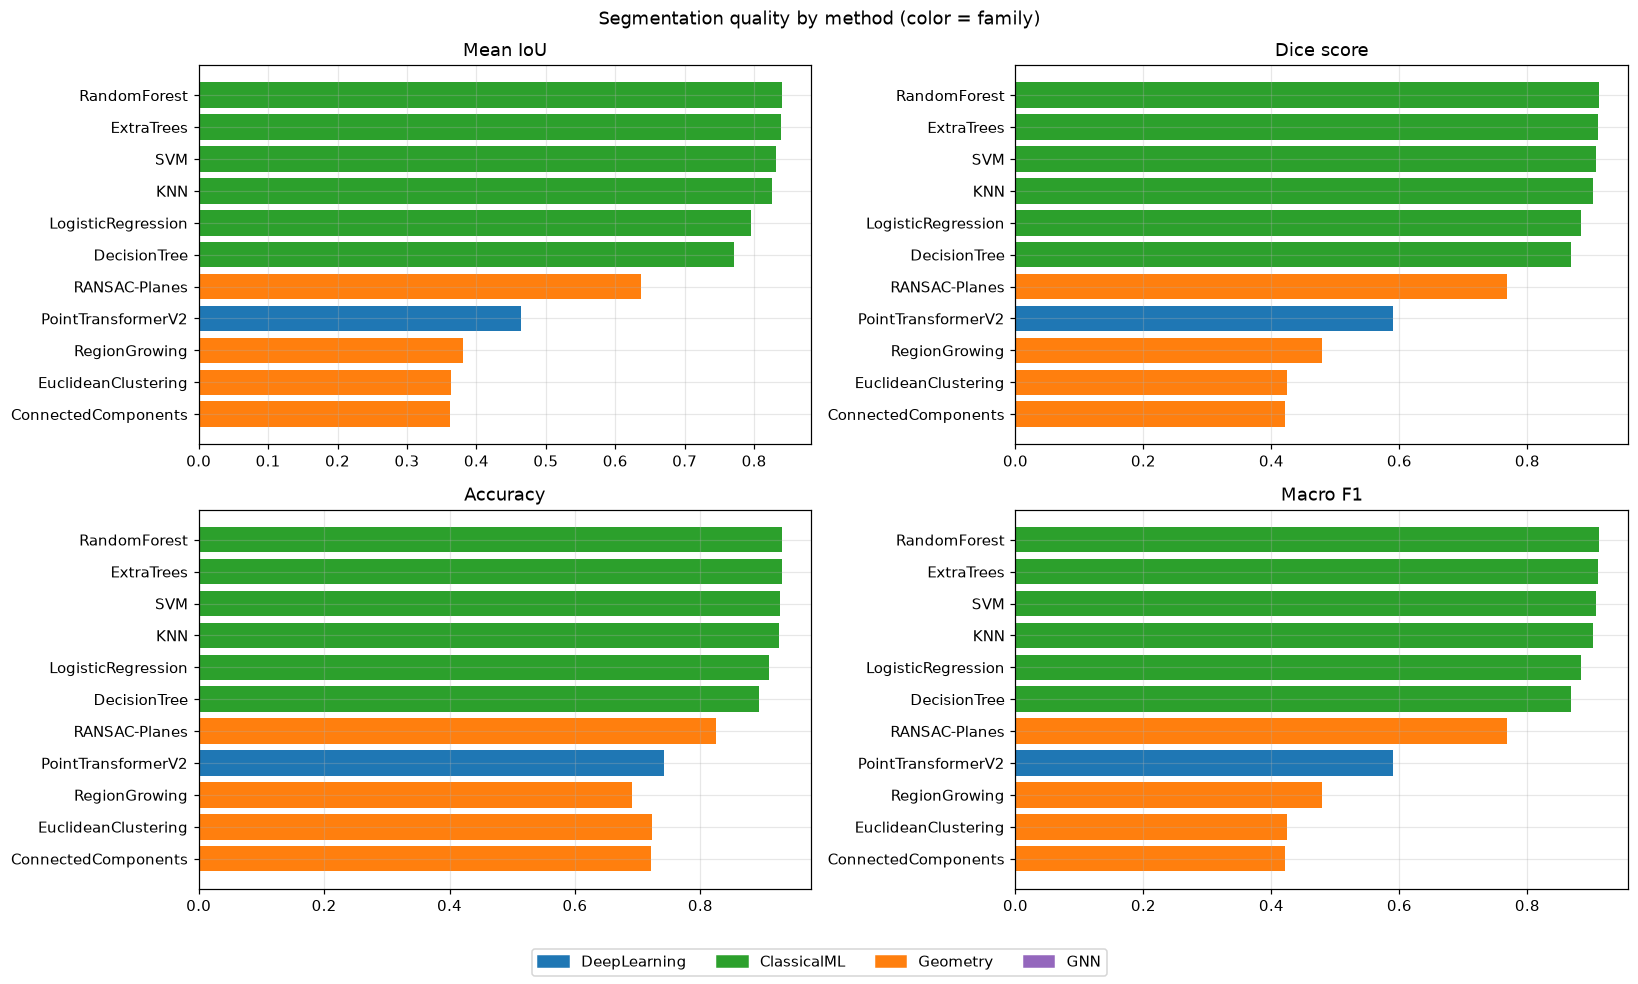

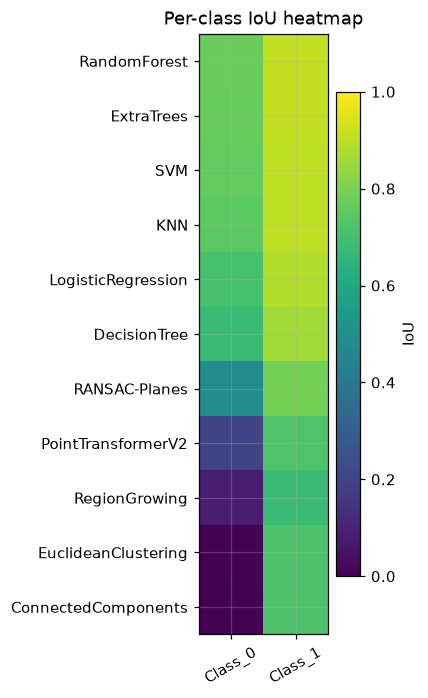

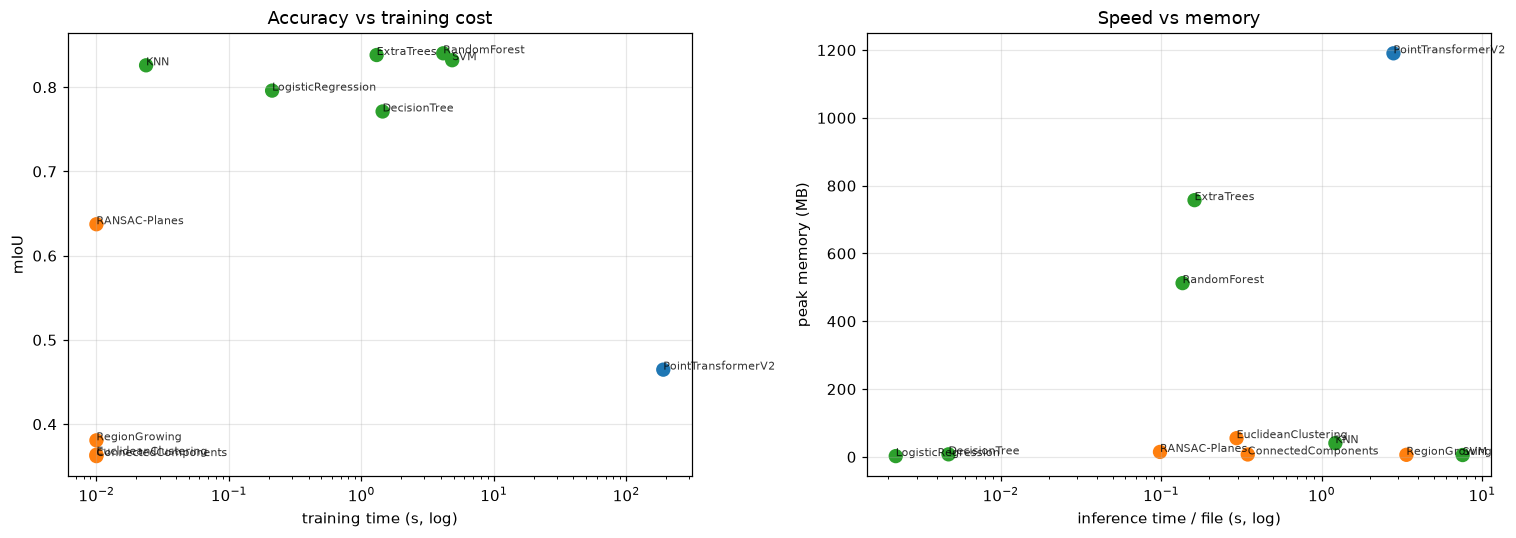

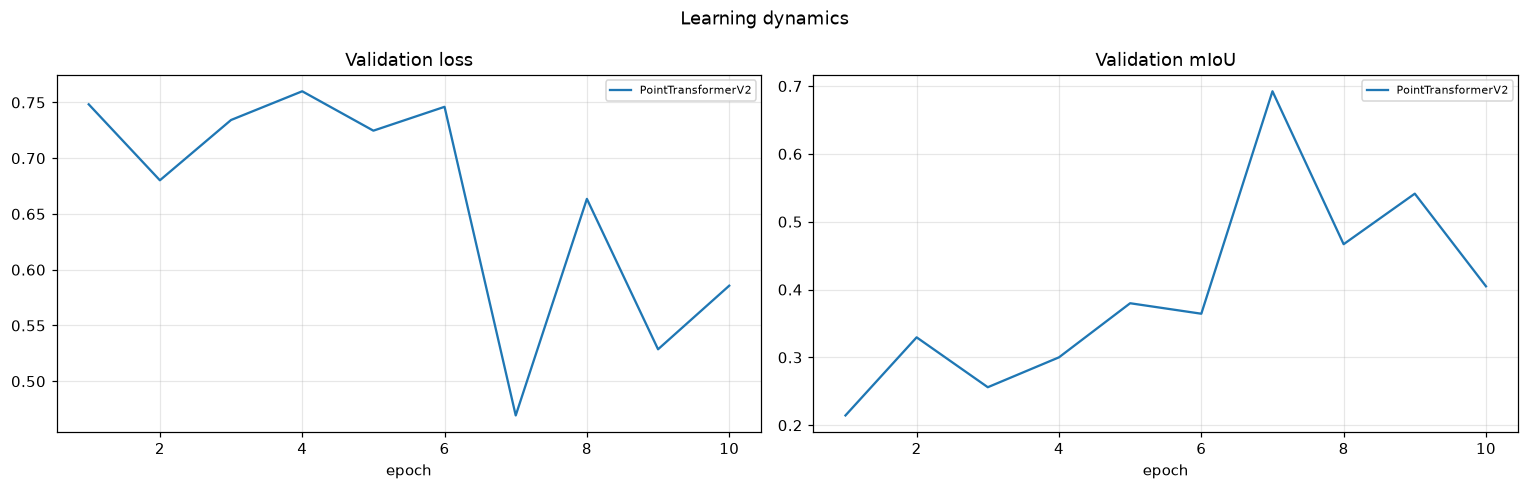

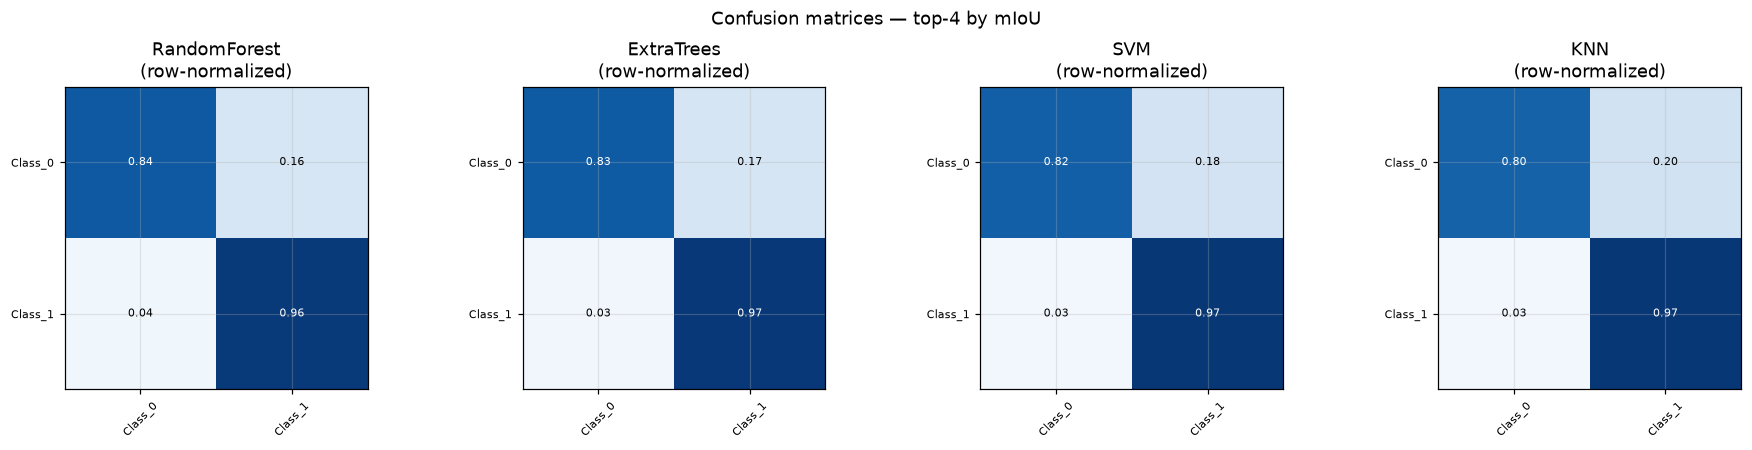


>>> Best segmentation model: RandomForest (mIoU 0.8402) — its predictions feed the end-to-end volume benchmark below.


In [18]:
# ================================================================ SEG COMPARISON
rows = []
for r in SEG_RESULTS.values():
    row = {"method": r.name, "family": r.family, **{k: v for k, v in r.metrics.items()
           if not k.startswith(("iou_", "dice_"))},
           "train_time_s": r.train_time, "infer_s_per_file": r.infer_time,
           "gpu_MB": r.gpu_mb, "cpu_MB": r.cpu_mb}
    for c in range(NUM_CLASSES):
        row[f"IoU[{CLASS_NAMES[c]}]"] = r.metrics.get(f"iou_{c}", np.nan)
    rows.append(row)
SEG_TABLE = pd.DataFrame(rows).sort_values("miou", ascending=False).reset_index(drop=True)
print("=" * 100)
print("SEGMENTATION BENCHMARK — MASTER TABLE (sorted by mIoU)")
print("=" * 100)
display(SEG_TABLE.round(4))

print("\nPER-METRIC WINNERS")
for metric, best_low in [("accuracy", False), ("miou", False), ("dice", False),
                         ("f1", False), ("train_time_s", True),
                         ("infer_s_per_file", True)]:
    s = SEG_TABLE.set_index("method")[metric].dropna()
    if len(s):
        winner = s.idxmin() if best_low else s.idxmax()
        print(f"  {'lowest' if best_low else 'best':>7} {metric:<18}: "
              f"{winner:<22} ({s[winner]:.4f})")

FAMILY_COLORS = {"DeepLearning": "#1f77b4", "ClassicalML": "#2ca02c",
                 "Geometry": "#ff7f0e", "GNN": "#9467bd"}
colors = [FAMILY_COLORS[f] for f in SEG_TABLE["family"]]

fig, ax = plt.subplots(2, 2, figsize=(15, 9))
for a, metric, title in [(ax[0, 0], "miou", "Mean IoU"),
                         (ax[0, 1], "dice", "Dice score"),
                         (ax[1, 0], "accuracy", "Accuracy"),
                         (ax[1, 1], "f1", "Macro F1")]:
    a.barh(SEG_TABLE["method"], SEG_TABLE[metric], color=colors)
    a.set_title(title); a.invert_yaxis()
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in FAMILY_COLORS.values()]
fig.legend(handles, FAMILY_COLORS.keys(), loc="lower center", ncol=4)
plt.suptitle("Segmentation quality by method (color = family)")
plt.tight_layout(rect=[0, 0.05, 1, 1]); plt.show()

# ---- per-class IoU heatmap ----
iou_cols = [c for c in SEG_TABLE.columns if c.startswith("IoU[")]
plt.figure(figsize=(1.6 + 1.1 * len(iou_cols), 0.45 * len(SEG_TABLE) + 1.5))
plt.imshow(SEG_TABLE[iou_cols].values, cmap="viridis", vmin=0, vmax=1, aspect="auto")
plt.colorbar(label="IoU")
plt.xticks(range(len(iou_cols)), [c[4:-1] for c in iou_cols], rotation=30)
plt.yticks(range(len(SEG_TABLE)), SEG_TABLE["method"])
plt.title("Per-class IoU heatmap"); plt.tight_layout(); plt.show()

# ---- accuracy vs resources trade-off ----
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(SEG_TABLE["train_time_s"].clip(lower=1e-2), SEG_TABLE["miou"],
              c=colors, s=70)
for _, r in SEG_TABLE.iterrows():
    ax[0].annotate(r["method"], (max(r["train_time_s"], 1e-2), r["miou"]),
                   fontsize=7, alpha=0.8)
ax[0].set_xscale("log"); ax[0].set_xlabel("training time (s, log)")
ax[0].set_ylabel("mIoU"); ax[0].set_title("Accuracy vs training cost")
mem = SEG_TABLE[["gpu_MB", "cpu_MB"]].max(axis=1)
ax[1].scatter(SEG_TABLE["infer_s_per_file"].clip(lower=1e-3), mem, c=colors, s=70)
for (_, r), m in zip(SEG_TABLE.iterrows(), mem):
    ax[1].annotate(r["method"], (max(r["infer_s_per_file"], 1e-3), m),
                   fontsize=7, alpha=0.8)
ax[1].set_xscale("log"); ax[1].set_xlabel("inference time / file (s, log)")
ax[1].set_ylabel("peak memory (MB)"); ax[1].set_title("Speed vs memory")
plt.tight_layout(); plt.show()

# ---- training curves (DL & GNN) ----
curve_res = [r for r in SEG_RESULTS.values() if r.history]
if curve_res:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    for r in curve_res:
        h = pd.DataFrame(r.history)
        ax[0].plot(h["epoch"], h["val_loss"], label=r.name)
        ax[1].plot(h["epoch"], h["val_miou"], label=r.name)
    ax[0].set_title("Validation loss"); ax[1].set_title("Validation mIoU")
    for a in ax:
        a.set_xlabel("epoch"); a.legend(fontsize=7)
    plt.suptitle("Learning dynamics"); plt.tight_layout(); plt.show()

# ---- confusion matrices of the top-4 ----
top = SEG_TABLE.head(4)["method"].tolist()
fig, axes = plt.subplots(1, len(top), figsize=(4.2 * len(top), 4))
axes = np.atleast_1d(axes)
for a, name in zip(axes, top):
    cm = SEG_RESULTS[name].conf.astype(float)
    cm = cm / cm.sum(1, keepdims=True).clip(min=1)
    a.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    a.set_title(f"{name}\n(row-normalized)")
    a.set_xticks(range(NUM_CLASSES)); a.set_yticks(range(NUM_CLASSES))
    a.set_xticklabels([CLASS_NAMES[c] for c in range(NUM_CLASSES)],
                      rotation=45, fontsize=7)
    a.set_yticklabels([CLASS_NAMES[c] for c in range(NUM_CLASSES)], fontsize=7)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            a.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                   color="white" if cm[i, j] > 0.5 else "black", fontsize=7)
plt.suptitle("Confusion matrices — top-4 by mIoU"); plt.tight_layout(); plt.show()

BEST_SEG_NAME = SEG_TABLE.iloc[0]["method"]
BEST_SEG = SEG_RESULTS[BEST_SEG_NAME]
print(f"\n>>> Best segmentation model: {BEST_SEG_NAME} "
      f"(mIoU {BEST_SEG.metrics['miou']:.4f}) — its predictions feed the "
      f"end-to-end volume benchmark below.")

## 6 · Volume Estimation Benchmark

**Research-grade error decomposition.** Every volume method is evaluated on two
inputs per eval file: (a) **GT-segmented** object points — isolates the *intrinsic*
error of the volume method itself, and (b) points segmented by the **best model**
from Section 5 — the honest *end-to-end* error. Comparing the two columns tells you
how much error comes from segmentation vs the volume algorithm.

*Why geometry methods struggle:* surface-only LiDAR scans are never watertight, so
mesh volumes (alpha shape, Poisson, Ball-Pivoting) rely on fragile hole-filling;
convex hulls bridge concavities (systematic over-estimate); the column-filled voxel
method assumes a pile shape (no overhangs). ML/DL regression sidesteps all of this by
*learning the correction* from ground truth — usually the winner.

In [19]:
# ================================================================ VOLUME: GEOMETRY
def _clean_pts(pts, cap=None, seed=42):
    """Qhull/alpha-shape segfault guard: finite, deduped, capped points."""
    pts = np.asarray(pts, np.float64)
    pts = pts[np.isfinite(pts).all(1)]
    if len(pts) > 1:
        pts = np.unique(pts, axis=0)
    cap = cap or CONFIG["vol"]["clean_cap"]
    if len(pts) > cap:
        pts = pts[np.random.RandomState(seed).choice(len(pts), cap, replace=False)]
    return pts

def vol_convex_hull(pts):
    pts = _clean_pts(pts, cap=500_000)
    if len(pts) < 4:
        return float("nan")
    try:
        return float(ConvexHull(pts, qhull_options="QJ").volume)
    except Exception:
        return float("nan")

def _mesh_volume(mesh):
    if mesh.is_watertight():
        return float(mesh.get_volume())
    vs = CONFIG["vol"]["voxel"]                      # non-watertight -> voxelized shell
    vox = o3d.geometry.VoxelGrid.create_from_triangle_mesh(mesh, vs)
    return float(len(vox.get_voxels()) * vs ** 3)

# def vol_alpha_shape(pts):
#     pts = _clean_pts(pts)
#     if not HAS_OPEN3D or len(pts) < 10:
#         return float("nan")
#     try:
#         pcd = o3d.geometry.PointCloud()
#         pcd.points = o3d.utility.Vector3dVector(pts)
#         mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(
#             pcd, CONFIG["vol"]["alpha"])
#         return _mesh_volume(mesh)
#     except Exception:
#         return float("nan")

def vol_alpha_shape(pts):
    pts = _clean_pts(pts)
    if not HAS_OPEN3D or len(pts) < 10:
        return float("nan")
    try:
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)
        pcd = pcd.voxel_down_sample(CONFIG["vol"]["voxel"])          # thin out density
        p = np.asarray(pcd.points)
        p += np.random.RandomState(0).normal(0, 1e-6, p.shape)      # break coplanarity
        pcd.points = o3d.utility.Vector3dVector(p)
        mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(
            pcd, CONFIG["vol"]["alpha"])
        return _mesh_volume(mesh)
    except Exception:
        return float("nan")

def vol_voxel_surface(pts):
    """Occupied-voxel count x voxel volume (counts only the scanned shell)."""
    pts = _clean_pts(pts, cap=1_000_000)
    if len(pts) < 4:
        return float("nan")
    vs = CONFIG["vol"]["voxel"]
    vox = np.unique(np.floor((pts - pts.min(0)) / vs).astype(np.int64), axis=0)
    return float(len(vox) * vs ** 3)

def vol_voxel_column(pts):
    """Column-filled occupancy: every (x,y) column filled floor->top voxel.
    The right prior for pile-shaped objects sitting on the ground."""
    pts = _clean_pts(pts, cap=1_000_000)
    if len(pts) < 4:
        return float("nan")
    vs = CONFIG["vol"]["voxel"]
    ijk = np.floor((pts - pts.min(0)) / vs).astype(np.int64)
    key = ijk[:, 0] * 1_000_003 + ijk[:, 1]
    order = np.argsort(key)
    ks, zs = key[order], ijk[order, 2]
    bounds = np.flatnonzero(np.diff(ks)) + 1
    col_top = np.maximum.reduceat(zs, np.r_[0, bounds])
    return float((col_top + 1).sum() * vs ** 3)

def _recon_volume(pts, kind):
    pts = _clean_pts(pts)
    if not HAS_OPEN3D or len(pts) < 30:
        return float("nan")
    try:
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)
        pcd.estimate_normals(o3d.geometry.KDTreeSearchParamKNN(24))
        pcd.orient_normals_to_align_with_direction([0, 0, 1.0])
        if kind == "bpa":
            mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
                pcd, o3d.utility.DoubleVector(CONFIG["vol"]["bpa_radii"]))
        else:
            mesh, _ = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
                pcd, depth=CONFIG["vol"]["poisson_depth"])
            mesh = mesh.crop(pcd.get_axis_aligned_bounding_box())
        mesh.remove_degenerate_triangles(); mesh.remove_duplicated_vertices()
        return _mesh_volume(mesh)
    except Exception:
        return float("nan")

GEO_VOLUME_FNS = {
    "vol_ConvexHull":   vol_convex_hull,
    "vol_AlphaShape":   vol_alpha_shape,
    "vol_VoxelSurface": vol_voxel_surface,
    "vol_VoxelColumn":  vol_voxel_column,
    "vol_BallPivoting": lambda p: _recon_volume(p, "bpa"),
    "vol_Poisson":      lambda p: _recon_volume(p, "poisson"),
}

In [20]:
def full_cloud_labels(entry):
    """Full-cloud prediction for ANY best model: torch -> chunked GPU;
    sklearn -> handcrafted features in batches."""
    if isinstance(BEST_SEG.model, nn.Module):
        out = predict_full_cloud(BEST_SEG.model, entry)
        BEST_SEG.model.to("cpu"); HW.cleanup()   # release VRAM after each cloud
        return out
    # classical ML: compute features for all points in batches, then predict
    n = len(entry["norm"])
    out = np.empty(n, np.int64)
    for s in range(0, n, 100_000):
        idx = np.arange(s, min(s + 100_000, n))
        out[idx] = BEST_SEG.model.predict(
            SCALER.transform(point_features(entry["norm"], idx)))
    return out

# ================================================================ VOLUME: EVAL INPUTS
# Build the two point sets per eval file ONCE: GT-segmented and best-model-segmented
# object points (original coordinates, class = GT_CLASS).
assert GT_CLASS is not None, ("gt_class_original not found among discovered classes "
                              "— set CONFIG['gt_class_original'] correctly.")
VOL_EVAL = []          # dicts: name, gt_volume, pts_gt_seg, pts_pred_seg
for f in tqdm(SPLIT["eval"], desc="volume eval inputs"):
    name = os.path.splitext(os.path.basename(f))[0]
    if name not in GT_VOLUMES:
        continue
    e = CACHE.get(f)
    # full_pred = predict_full_cloud(BEST_SEG.model, e) if BEST_SEG.model is not None \
    #     else None
    # pred_lbl = full_pred if full_pred is not None else e["lbl"]
    pred_lbl = full_cloud_labels(e) if BEST_SEG.model is not None else e["lbl"]
    VOL_EVAL.append(dict(
        name=name, gt_volume=GT_VOLUMES[name],
        pts_gt_seg=e["raw"][e["lbl"] == GT_CLASS],
        pts_pred_seg=e["raw"][pred_lbl == GT_CLASS]))
log.info("Volume eval files with GT volume: %d", len(VOL_EVAL))
if not VOL_EVAL:
    log.warning("No GT volumes for the eval split -> volume benchmark will only "
                "produce raw estimates without error analysis.")

# Training set for the LEARNED volume methods (GT-segmented train/val files)
VOL_TRAIN = []
for f in tqdm(SPLIT["train"] + SPLIT["val"], desc="volume train inputs"):
    name = os.path.splitext(os.path.basename(f))[0]
    if name in GT_VOLUMES:
        e = CACHE.get(f)
        VOL_TRAIN.append(dict(name=name, gt_volume=GT_VOLUMES[name],
                              pts=e["raw"][e["lbl"] == GT_CLASS]))
log.info("Volume training samples (files with GT): %d", len(VOL_TRAIN))

# ---- shared geometric feature vector for the regression methods ----
VOL_FEATURE_NAMES = (["n_points", "bbox_vol", "ext_x", "ext_y", "ext_z", "z_mean",
                      "z_std", "spread", "hull_vol", "hull_area"]
                     + ["voxA", "voxB", "voxC"] + ["density"])
def volume_features(pts):
    f = {"n_points": float(len(pts))}
    if len(pts) < 4:
        return np.zeros(len(VOL_FEATURE_NAMES), np.float64)
    mins, maxs = pts.min(0), pts.max(0)
    ext = np.clip(maxs - mins, 1e-9, None)
    f.update(bbox_vol=float(np.prod(ext)), ext_x=float(ext[0]), ext_y=float(ext[1]),
             ext_z=float(ext[2]), z_mean=float(pts[:, 2].mean() - mins[2]),
             z_std=float(pts[:, 2].std()), spread=float(np.trace(np.cov(pts.T))))
    try:
        h = ConvexHull(_clean_pts(pts, cap=200_000), qhull_options="QJ")
        f["hull_vol"], f["hull_area"] = float(h.volume), float(h.area)
    except Exception:
        f["hull_vol"] = f["hull_area"] = 0.0
    for tag, vs in zip(("voxA", "voxB", "voxC"), (0.01, 0.02, 0.05)):
        vox = np.unique(np.floor((pts - mins) / vs).astype(np.int64), axis=0)
        f[tag] = float(len(vox) * vs ** 3)
    f["density"] = f["n_points"] / max(f["hull_vol"], 1e-9)
    return np.array([f[k] for k in VOL_FEATURE_NAMES], np.float64)

X_VOL = np.vstack([volume_features(s["pts"]) for s in VOL_TRAIN]) if VOL_TRAIN else None
Y_VOL = np.array([s["gt_volume"] for s in VOL_TRAIN]) if VOL_TRAIN else None

volume eval inputs:   0%|          | 0/6 [00:00<?, ?it/s]

2026-07-08 23:30:50,294 | INFO    | Volume eval files with GT volume: 6


volume train inputs:   0%|          | 0/39 [00:00<?, ?it/s]

2026-07-08 23:30:57,702 | INFO    | Volume training samples (files with GT): 39


In [21]:
# ================================================================ VOLUME: REGISTRY & RUNNERS
@dataclass
class VolResult:
    name: str; family: str
    pred_gt_seg: List[float]; pred_model_seg: List[float]
    fit_time: float = 0.0; est_time: float = 0.0; cpu_mb: float = 0.0; gpu_mb: float = 0.0
VOL_RESULTS: Dict[str, VolResult] = {}

def run_volume_method(name, family, estimate_fn, fit_time=0.0, extra_prof=None):
    """Estimate every eval file with both segmentations + profile + MLflow."""
    TRACKER.start(name, nested=True, tags={"family": family, "phase": "volume"})
    with Profiler() as p:
        pg = [estimate_fn(s["pts_gt_seg"]) for s in VOL_EVAL]
        pm = [estimate_fn(s["pts_pred_seg"]) for s in VOL_EVAL]
    gt = [s["gt_volume"] for s in VOL_EVAL]
    m_end = volume_metrics(gt, pm)
    m_gt = volume_metrics(gt, pg)
    TRACKER.metrics({f"end2end_{k}": v for k, v in m_end.items()})
    TRACKER.metrics({f"gtseg_{k}": v for k, v in m_gt.items()})
    TRACKER.metrics({"fit_time_s": fit_time,
                     "estimate_time_s": p.seconds / max(len(VOL_EVAL) * 2, 1),
                     "cpu_peak_mb": p.cpu_mb, "gpu_peak_mb": p.gpu_mb})
    TRACKER.end()
    VOL_RESULTS[name] = VolResult(name, family, pg, pm, fit_time,
                                  p.seconds / max(len(VOL_EVAL) * 2, 1),
                                  p.cpu_mb, p.gpu_mb)
    log.info("[%s/%s] end-to-end MAE %.4f | with-GT-seg MAE %.4f | %.3fs/est",
             family, name, m_end["MAE"], m_gt["MAE"],
             p.seconds / max(len(VOL_EVAL) * 2, 1))

# ---- 6a geometry methods ----
for _n, _fn in GEO_VOLUME_FNS.items():
    if CONFIG["enabled"].get(_n, False) and VOL_EVAL:
        run_volume_method(_n, "Geometry", _fn)

In [22]:
# ================================================================ VOLUME: ML REGRESSION
def vol_reg_candidates():
    s = CONFIG["seed"]
    c = {"vol_RF": RandomForestRegressor(400, min_samples_leaf=2, n_jobs=-1,
                                         random_state=s),
         "vol_ExtraTrees": ExtraTreesRegressor(400, n_jobs=-1, random_state=s),
         "vol_GBoost": GradientBoostingRegressor(n_estimators=400,
                                                 learning_rate=0.05, random_state=s),
         "vol_SVR": SVR(kernel="rbf", C=10.0)}
    if xgboost:
        c["vol_XGBoost"] = xgboost.XGBRegressor(n_estimators=500, max_depth=5,
                                                learning_rate=0.05, n_jobs=-1,
                                                random_state=s, verbosity=0)
    if lightgbm:
        c["vol_LightGBM"] = lightgbm.LGBMRegressor(n_estimators=500, random_state=s,
                                                   n_jobs=-1, verbose=-1)
    if catboost:
        c["vol_CatBoost"] = catboost.CatBoostRegressor(iterations=500, depth=6,
                                                       random_seed=s, verbose=False)
    return c

VOL_REG_MODELS = {}
if X_VOL is not None and len(X_VOL) >= CONFIG["vol"]["reg_cv_folds"]:
    _scaler = StandardScaler().fit(X_VOL)
    Xs = _scaler.transform(X_VOL)
    yt = np.log1p(Y_VOL) if CONFIG["vol"]["log_target"] else Y_VOL
    kf = KFold(CONFIG["vol"]["reg_cv_folds"], shuffle=True,
               random_state=CONFIG["seed"])
    for _n, _est in vol_reg_candidates().items():
        if not CONFIG["enabled"].get(_n, False):
            continue
        cache_path = _resume_path("vol", _n, "joblib")
        found_path = find_checkpoint("vol", _n, "joblib") \
            if CONFIG["resume"]["enabled"] else None
        if found_path:
            try:
                blob = joblib.load(found_path)
                _est_loaded = blob["model"]
                _ = _est_loaded.predict
            except Exception as e:
                log.warning("[resume] %s -> candidate %s did not load (%s) -> "
                           "training fresh instead", _n, found_path, e)
                found_path = None
        if found_path:
            log.info("[resume] %s -> found existing regressor (%s), SKIPPING CV+fit",
                     _n, found_path)
            _est, fit_time = _est_loaded, 0.0
            if CONFIG["resume"]["enabled"] and found_path != cache_path:
                joblib.dump({"model": _est}, cache_path)
        else:
            with Profiler() as p_fit:
                maes = []
                for tr, va in kf.split(Xs):                  # honest CV on train files
                    e = copy.deepcopy(_est); e.fit(Xs[tr], yt[tr])
                    pv = e.predict(Xs[va])
                    if CONFIG["vol"]["log_target"]:
                        pv = np.expm1(pv)
                    maes.append(mean_absolute_error(Y_VOL[va], pv))
                _est.fit(Xs, yt)                             # final fit on all
            fit_time = p_fit.seconds
            log.info("    %s CV MAE (train files): %.4f", _n, np.mean(maes))
            if CONFIG["resume"]["enabled"]:
                joblib.dump({"model": _est}, cache_path)
                log.info("[resume] %s -> cached at %s", _n, cache_path)
        VOL_REG_MODELS[_n] = (_est, _scaler)
        def _estimate(pts, _m=_est, _s=_scaler):
            x = _s.transform(volume_features(pts).reshape(1, -1))
            v = float(_m.predict(x)[0])
            return max(float(np.expm1(v)) if CONFIG["vol"]["log_target"] else v, 0.0)
        if VOL_EVAL:
            run_volume_method(_n, "ML-Regression", _estimate, fit_time=fit_time)
else:
    log.warning("Too few GT-volume training files -> ML volume regression skipped")

2026-07-08 23:31:26,135 | INFO    | [resume] vol_RF -> found existing regressor (checkpoints/_resume_cache/vol_vol_RF.joblib), SKIPPING CV+fit
2026-07-08 23:31:37,108 | INFO    | [ML-Regression/vol_RF] end-to-end MAE 11.2729 | with-GT-seg MAE 15.8536 | 0.908s/est
2026-07-08 23:31:37,136 | INFO    | [resume] vol_ExtraTrees -> found existing regressor (checkpoints/_resume_cache/vol_vol_ExtraTrees.joblib), SKIPPING CV+fit
2026-07-08 23:31:48,210 | INFO    | [ML-Regression/vol_ExtraTrees] end-to-end MAE 11.8978 | with-GT-seg MAE 14.3654 | 0.917s/est
2026-07-08 23:31:48,215 | INFO    | [resume] vol_GBoost -> found existing regressor (checkpoints/_resume_cache/vol_vol_GBoost.joblib), SKIPPING CV+fit
2026-07-08 23:31:57,994 | INFO    | [ML-Regression/vol_GBoost] end-to-end MAE 11.4720 | with-GT-seg MAE 15.0353 | 0.809s/est
2026-07-08 23:31:57,995 | INFO    | [resume] vol_SVR -> found existing regressor (checkpoints/_resume_cache/vol_vol_SVR.joblib), SKIPPING CV+fit
2026-07-08 23:32:07,591 | I

In [23]:
# ================================================================ VOLUME: DL & GNN REGRESSION
def object_feat7(pts):
    """7-ch features for a segmented object: [norm-xyz, height, normals]."""
    if len(pts) < 8:
        pts = np.zeros((8, 3))
    c = pts.mean(0, keepdims=True)
    sc = max(np.linalg.norm(pts - c, axis=1).max(), 1e-9)
    pn = ((pts - c) / sc).astype(np.float32)
    h = ((pts[:, 2] - pts[:, 2].min())
         / max(pts[:, 2].max() - pts[:, 2].min(), 1e-6)).astype(np.float32)
    if HAS_OPEN3D and len(pts) > 32:
        _p = o3d.geometry.PointCloud()
        _p.points = o3d.utility.Vector3dVector(np.asarray(pts, np.float64))
        _p.estimate_normals(o3d.geometry.KDTreeSearchParamKNN(16))
        _p.orient_normals_to_align_with_direction([0.0, 0.0, 1.0])
        nrm = np.asarray(_p.normals).astype(np.float32)
    else:
        nrm = np.zeros_like(pn)
    return np.column_stack([pn, h[:, None], nrm]).astype(np.float32)

class VolPointDataset(Dataset):
    """GT-class object points -> 7-ch features -> log1p(volume) target."""
    def __init__(self, items):
        self.items = items
        self.N = CONFIG["vol"]["dl_points"]
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        s = self.items[i]
        if "feat7" not in s:                    # compute once, reuse across epochs
            s["feat7"] = object_feat7(s["pts"])
        f = s["feat7"]
        idx = np.random.choice(len(f), self.N, replace=len(f) < self.N)
        return torch.from_numpy(f[idx].T), torch.tensor(
            np.log1p(s["gt_volume"]), dtype=torch.float32)

class EmbRegressor(nn.Module):
    """Any segmentation backbone -> global embedding -> MLP -> log1p(volume)."""
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(nn.Linear(backbone.emb_dims, 128), nn.ReLU(),
                                  nn.Dropout(0.3), nn.Linear(128, 1))
    def forward(self, x):
        return self.head(self.backbone(x, return_embedding=True)).squeeze(-1)

def train_vol_regressor(model, name):
    v = CONFIG["vol"]
    n_val = max(1, int(0.2 * len(VOL_TRAIN)))
    tr = DataLoader(VolPointDataset(VOL_TRAIN[n_val:]), batch_size=v["dl_batch"],
                    shuffle=True, drop_last=len(VOL_TRAIN[n_val:]) > v["dl_batch"])
    va = DataLoader(VolPointDataset(VOL_TRAIN[:n_val]), batch_size=v["dl_batch"])
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
    lossf = nn.SmoothL1Loss()
    best, best_state, bad = np.inf, None, 0
    model.to(HW.device)
    for ep in range(1, v["dl_epochs"] + 1):
        model.train()
        for x, y in tr:
            try:
                loss = lossf(model(x.to(HW.device)), y.to(HW.device))
                opt.zero_grad(); loss.backward(); opt.step()
            except torch.cuda.OutOfMemoryError:
                HW.to_cpu(); model.to(HW.device)
                for st in opt.state.values():
                    for k2, v2 in st.items():
                        if torch.is_tensor(v2):
                            st[k2] = v2.cpu()
        model.eval(); preds, gts = [], []
        with torch.no_grad():
            for x, y in va:
                preds += np.expm1(model(x.to(HW.device)).cpu().numpy()).tolist()
                gts += np.expm1(y.numpy()).tolist()
        mae = mean_absolute_error(gts, preds) if gts else np.inf
        TRACKER.metrics({"val_mae": mae}, step=ep)
        if mae < best - 1e-6:
            best, best_state, bad = mae, copy.deepcopy(model.state_dict()), 0
        else:
            bad += 1
        if bad >= v["dl_patience"]:
            break
    if best_state:
        model.load_state_dict(best_state)
    model.to("cpu"); HW.cleanup()                # training done -> VRAM free
    return model

@torch.no_grad()
def dl_estimate(model, pts):
    if len(pts) < 8:
        return float("nan")
    f = object_feat7(pts)
    idx = np.random.RandomState(0).choice(len(f), CONFIG["vol"]["dl_points"],
                                          replace=len(f) < CONFIG["vol"]["dl_points"])
    model.to(HW.device)                          # GPU on demand
    x = torch.from_numpy(f[idx].T).unsqueeze(0).to(HW.device)
    v = max(float(np.expm1(model(x).item())), 0.0)
    model.to("cpu"); HW.cleanup()                # release right after
    return v

# simple MLP on the geometric feature vector (the "MLP Regression" baseline)
class FeatMLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d, 64), nn.ReLU(), nn.Dropout(0.2),
                                 nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x):
        return self.net(x).squeeze(-1)

DL_VOL_BUILDERS = {
    "vol_MLP":          None,                                   # handled separately
    "vol_PointNetReg":  (lambda: EmbRegressor(PointNetSeg())),
    "vol_PointNeXtReg": (lambda: EmbRegressor(PointNeXtSeg())),
}
if HAS_SCATTER:
    DL_VOL_BUILDERS["vol_PTv1Reg"] = lambda: EmbRegressor(PTv1Seg())
    DL_VOL_BUILDERS["vol_PTv2Reg"] = lambda: EmbRegressor(PTv2Seg())
    DL_VOL_BUILDERS["vol_GCNReg"] = lambda: EmbRegressor(GNNSeg(GCNLayer))
    DL_VOL_BUILDERS["vol_SAGEReg"] = lambda: EmbRegressor(GNNSeg(SAGELayer))
    DL_VOL_BUILDERS["vol_GATReg"] = lambda: EmbRegressor(GNNSeg(GATLayer))

if VOL_TRAIN and VOL_EVAL:
    # ---- feature-vector MLP ----
    if CONFIG["enabled"].get("vol_MLP", False) and X_VOL is not None:
        set_seed(CONFIG["seed"])
        _s = StandardScaler().fit(X_VOL)
        mlp = FeatMLP(X_VOL.shape[1]).to(HW.device)
        cache_path = _resume_path("vol", "vol_MLP", "pt")
        found_path = find_checkpoint("vol", "vol_MLP", "pt") \
            if CONFIG["resume"]["enabled"] else None
        if found_path:
            try:
                ckpt = torch.load(found_path, map_location=HW.device, weights_only=False)
                mlp.load_state_dict(ckpt["model_state"])
            except Exception as e:
                log.warning("[resume] vol_MLP -> candidate %s did not load (%s) -> "
                           "training fresh instead", found_path, e)
                found_path = None
        if found_path:
            log.info("[resume] vol_MLP -> found existing weights (%s), SKIPPING training",
                     found_path)
            fit_time = 0.0
            if CONFIG["resume"]["enabled"] and found_path != cache_path:
                torch.save(ckpt, cache_path)
        else:
            optm = torch.optim.Adam(mlp.parameters(), lr=1e-3)
            Xt = torch.tensor(_s.transform(X_VOL), dtype=torch.float32, device=HW.device)
            Yt = torch.tensor(np.log1p(Y_VOL), dtype=torch.float32, device=HW.device)
            with Profiler() as p_fit:
                for _ in range(400):
                    loss = F.smooth_l1_loss(mlp(Xt), Yt)
                    optm.zero_grad(); loss.backward(); optm.step()
            fit_time = p_fit.seconds
            if CONFIG["resume"]["enabled"]:
                torch.save({"model_state": mlp.state_dict()}, cache_path)
                log.info("[resume] vol_MLP -> cached at %s", cache_path)
        mlp.eval()
        def _mlp_est(pts, _m=mlp, _sc=_s):
            with torch.no_grad():
                x = torch.tensor(_sc.transform(volume_features(pts).reshape(1, -1)),
                                 dtype=torch.float32, device=HW.device)
                return max(float(np.expm1(_m(x).item())), 0.0)
        run_volume_method("vol_MLP", "DL-Regression", _mlp_est, fit_time=fit_time)
        VOL_REG_MODELS["vol_MLP"] = (mlp, _s)

    # ---- point-based DL / GNN regressors ----
    for _n, _build in DL_VOL_BUILDERS.items():
        if _build is None or not CONFIG["enabled"].get(_n, False):
            continue
        set_seed(CONFIG["seed"]); HW.cleanup()
        cache_path = _resume_path("vol", _n, "pt")
        found_path = find_checkpoint("vol", _n, "pt") \
            if CONFIG["resume"]["enabled"] else None
        if found_path:
            try:
                _reg_loaded = _build()
                ckpt = torch.load(found_path, map_location="cpu", weights_only=False)
                _reg_loaded.load_state_dict(ckpt["model_state"])
            except Exception as e:
                log.warning("[resume] %s -> candidate %s did not load (%s) -> "
                           "training fresh instead", _n, found_path, e)
                found_path = None
        if found_path:
            log.info("[resume] %s -> found existing weights (%s), SKIPPING training",
                     _n, found_path)
            _reg, fit_time = _reg_loaded, 0.0
            if CONFIG["resume"]["enabled"] and found_path != cache_path:
                torch.save(ckpt, cache_path)
        else:
            TRACKER.start(f"fit_{_n}", nested=True,
                          tags={"family": "DL-Regression", "phase": "volume_fit"})
            with Profiler() as p_fit:
                _reg = train_vol_regressor(_build(), _n)
            TRACKER.end()
            fit_time = p_fit.seconds
            if CONFIG["resume"]["enabled"]:
                torch.save({"model_state": _reg.state_dict()}, cache_path)
                log.info("[resume] %s -> cached at %s", _n, cache_path)
        fam = "GNN-Regression" if "GCN" in _n or "SAGE" in _n or "GAT" in _n \
            else "DL-Regression"
        run_volume_method(_n, fam, lambda p, _m=_reg: dl_estimate(_m, p),
                          fit_time=fit_time)
        VOL_REG_MODELS[_n] = (_reg, None)

2026-07-08 23:32:07,701 | INFO    | [resume] vol_PTv2Reg -> found existing weights (checkpoints/_resume_cache/vol_vol_PTv2Reg.pt), SKIPPING training
2026-07-08 23:32:10,294 | INFO    | [DL-Regression/vol_PTv2Reg] end-to-end MAE 25.0999 | with-GT-seg MAE 23.3588 | 0.210s/est


### 7·A — Per-file volume error table (testing / eval split)

One row per eval file with GT volume; one column per volume method — estimates,
percentage errors, and the per-file winner. Uses predictions already stored in
`VOL_RESULTS` (end-to-end, i.e. best-model segmentation) — nothing is recomputed.

PER-FILE VOLUME ESTIMATES (end-to-end: best-seg-model points) — eval split


,file,gt_volume,vol_RF,vol_ExtraTrees,vol_GBoost,vol_SVR,vol_PTv2Reg
0,sample_data_0013,65.0,64.7685,66.7866,62.4825,74.5740,48.5433
1,sample_data_0020,80.0,88.7016,90.3455,90.0418,71.4707,123.2561
2,sample_data_0017,70.0,85.6770,84.5680,84.3380,70.7845,54.1000
3,sample_data_0012,92.0,87.6773,87.8178,87.2926,76.5586,119.8638
4,sample_data_0015,88.0,82.6728,80.7939,83.3419,83.5240,113.4771
5,sample_data_0031,88.0,54.6225,54.7015,55.4305,63.6757,66.3544



PER-FILE |%% ERROR| BY METHOD (last column = winner for that file)


,file,vol_RF,vol_ExtraTrees,vol_GBoost,vol_SVR,vol_PTv2Reg,best_method
0,sample_data_0013,0.36,2.75,3.87,14.73,25.32,vol_RF
1,sample_data_0020,10.88,12.93,12.55,10.66,54.07,vol_SVR
2,sample_data_0017,22.40,20.81,20.48,1.12,22.71,vol_SVR
3,sample_data_0012,4.70,4.55,5.12,16.78,30.29,vol_ExtraTrees
4,sample_data_0015,6.05,8.19,5.29,5.09,28.95,vol_SVR
5,sample_data_0031,37.93,37.84,37.01,27.64,24.60,vol_PTv2Reg



SUMMARY ACROSS EVAL FILES


,mean_pct_err,median_pct_err,worst_pct_err,files_won
vol_SVR,12.67,12.70,27.64,3
vol_RF,13.72,8.46,37.93,1
vol_GBoost,14.05,8.92,37.01,0
vol_ExtraTrees,14.51,10.56,37.84,1
vol_PTv2Reg,30.99,27.14,54.07,1


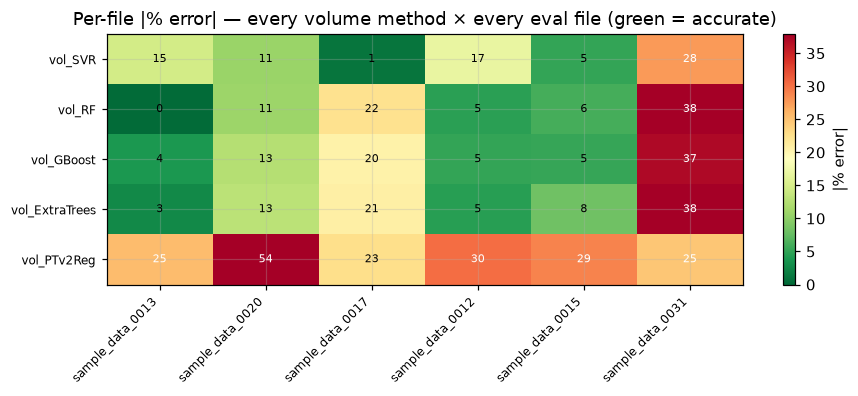

In [24]:
# ================================================================ PER-FILE VOLUME ERROR TABLE (EVAL)
if VOL_RESULTS and VOL_EVAL:
    _files = [s["name"] for s in VOL_EVAL]
    _gt = np.array([s["gt_volume"] for s in VOL_EVAL], float)

    est = pd.DataFrame({"file": _files, "gt_volume": _gt})
    err = pd.DataFrame({"file": _files})
    for name, r in VOL_RESULTS.items():
        pred = np.asarray(r.pred_model_seg, float)
        est[name] = np.round(pred, 4)
        err[name] = np.round(np.abs(pred - _gt) / np.clip(np.abs(_gt), 1e-9, None)
                             * 100, 2)
    _mcols = list(VOL_RESULTS.keys())
    err["best_method"] = err[_mcols].astype(float).idxmin(axis=1)

    print("=" * 110)
    print("PER-FILE VOLUME ESTIMATES (end-to-end: best-seg-model points) — eval split")
    print("=" * 110)
    display(est)
    print("\nPER-FILE |%% ERROR| BY METHOD (last column = winner for that file)")
    display(err)

    summary = pd.DataFrame({
        "mean_pct_err":   err[_mcols].mean().round(2),
        "median_pct_err": err[_mcols].median().round(2),
        "worst_pct_err":  err[_mcols].max().round(2),
        "files_won":      err["best_method"].value_counts()
                             .reindex(_mcols).fillna(0).astype(int),
    }).sort_values("mean_pct_err")
    print("\nSUMMARY ACROSS EVAL FILES")
    display(summary)

    # ---- heatmap: methods x files ----
    order = summary.index.tolist()
    M = err.set_index("file")[order].T.values.astype(float)
    plt.figure(figsize=(1.8 + 1.1 * len(_files), 0.42 * len(order) + 1.6))
    vmax = np.nanpercentile(M, 95) if np.isfinite(M).any() else 1.0
    plt.imshow(M, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=max(vmax, 1e-6))
    plt.colorbar(label="|% error|")
    plt.xticks(range(len(_files)), _files, rotation=45, ha="right", fontsize=8)
    plt.yticks(range(len(order)), order, fontsize=8)
    for r_i in range(M.shape[0]):
        for c_i in range(M.shape[1]):
            if np.isfinite(M[r_i, c_i]):
                plt.text(c_i, r_i, f"{M[r_i, c_i]:.0f}", ha="center", va="center",
                         fontsize=7,
                         color="white" if M[r_i, c_i] > vmax * 0.6 else "black")
    plt.title("Per-file |% error| — every volume method × every eval file "
              "(green = accurate)")
    plt.tight_layout(); plt.show()
else:
    log.warning("VOL_RESULTS/VOL_EVAL empty -> per-file error table skipped")

## 7 · Volume Comparison vs Ground Truth — Error Analysis

Tables + four diagnostic plots: metric bars, predicted-vs-GT scatter (points on the
diagonal are perfect), relative-error distributions, and the **segmentation-impact**
chart (end-to-end error minus GT-segmentation error = how much the segmenter costs
each volume method).

VOLUME BENCHMARK — end-to-end (predicted segmentation) vs GT volumes


,method,family,MAE,RMSE,MSE,RelErr,PctErr,R2,MAE_gtseg,PctErr_gtseg,seg_cost_MAE,fit_time_s,est_time_s,failures
0,vol_SVR,ML-Regression,10.5216,13.0075,169.1946,0.1267,12.6705,-0.7047,12.9985,15.8146,-2.4769,0.0,0.7940,0
1,vol_RF,ML-Regression,11.2729,15.7197,247.1099,0.1372,13.7183,-1.4898,15.8536,19.1961,-4.5807,0.0,0.9082,0
2,vol_GBoost,ML-Regression,11.4720,15.3698,236.2307,0.1405,14.0548,-1.3802,15.0353,18.1761,-3.5633,0.0,0.8090,0
3,vol_ExtraTrees,ML-Regression,11.8978,15.8148,250.1089,0.1451,14.5110,-1.5200,14.3654,17.1728,-2.4676,0.0,0.9171,0
4,vol_PTv2Reg,DL-Regression,25.0999,26.7355,714.7879,0.3099,30.9896,-6.2019,23.3588,30.7904,1.7410,0.0,0.2099,0


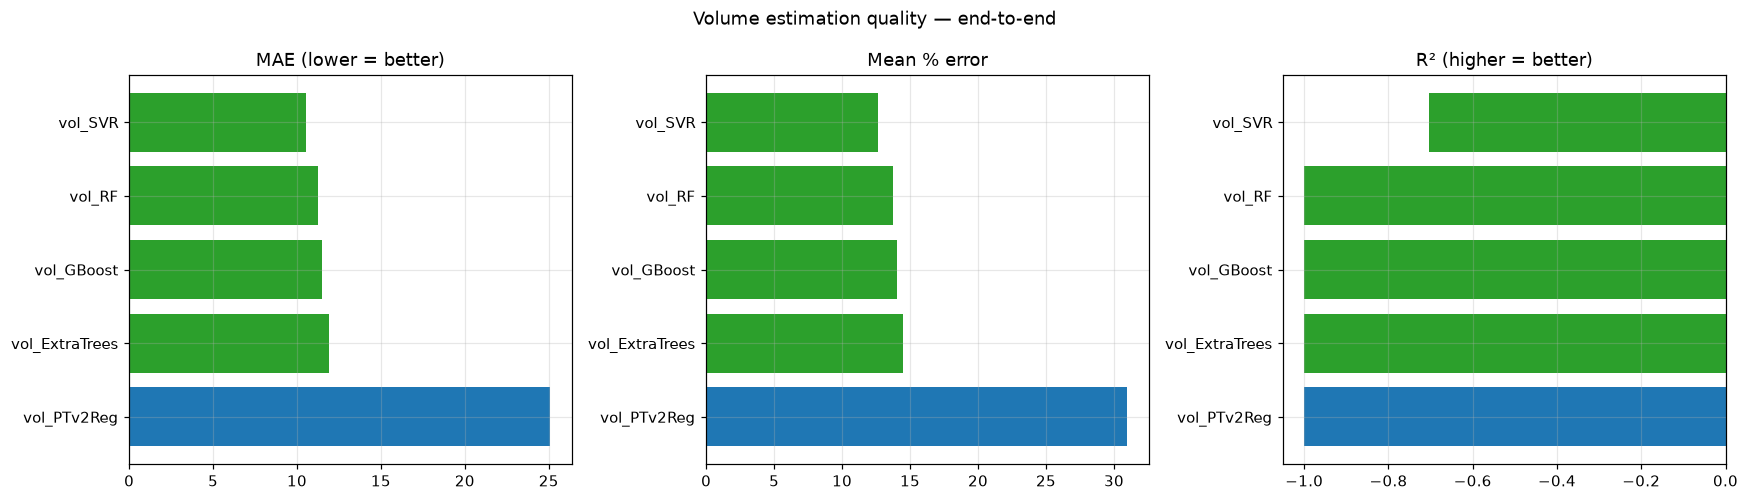

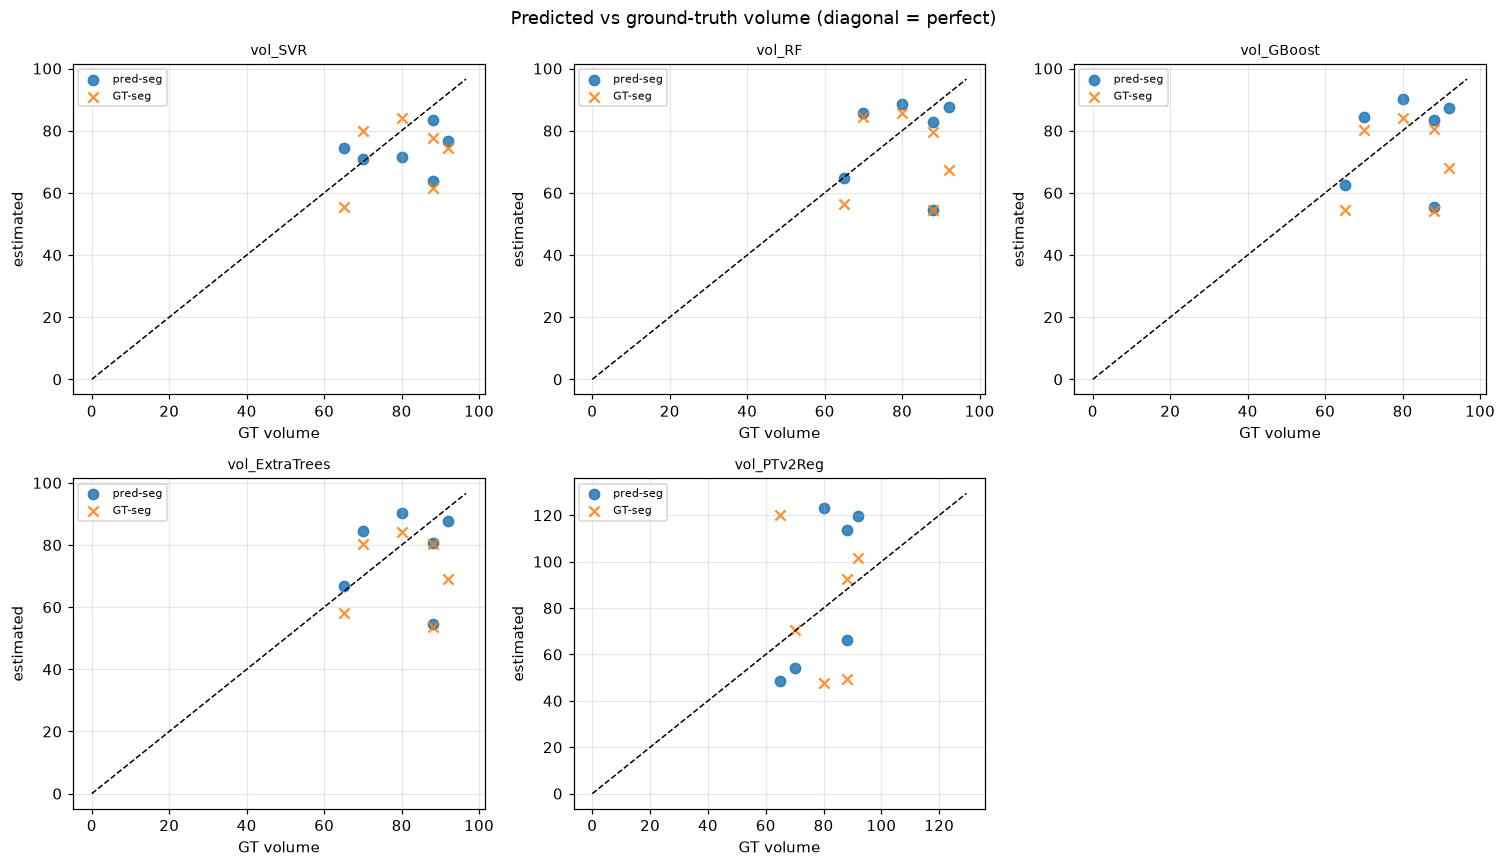

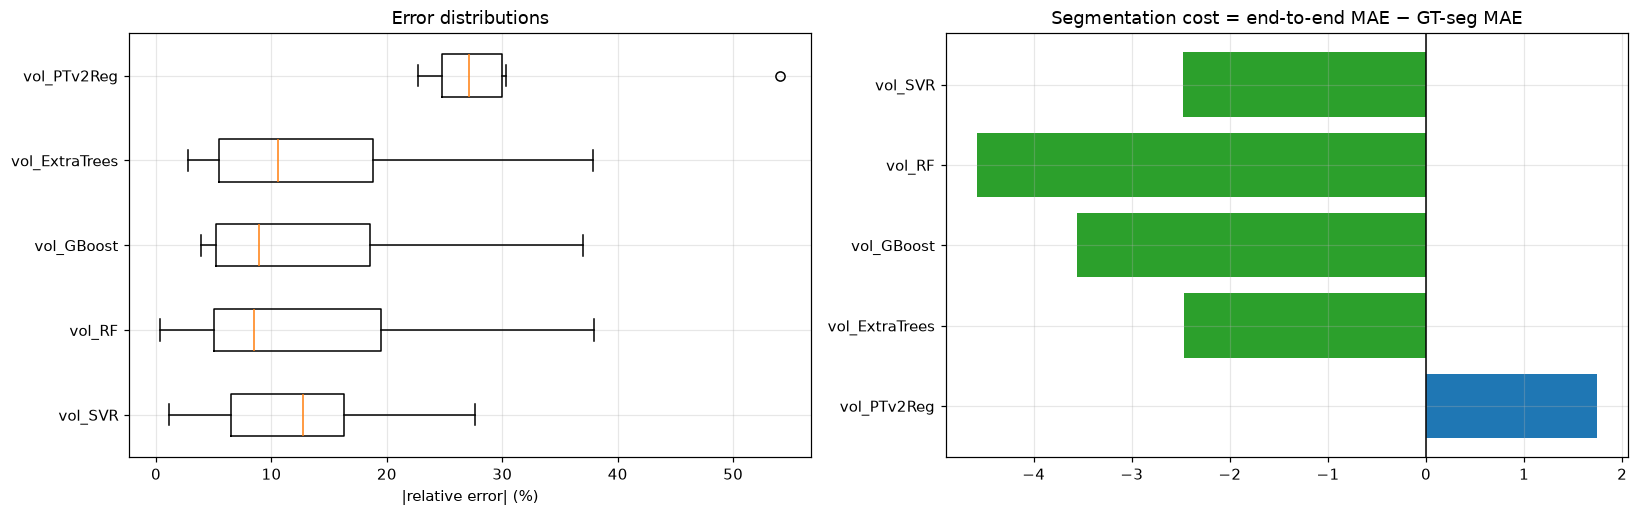

>>> Best volume method (end-to-end MAE): vol_SVR


In [25]:
# ================================================================ VOLUME COMPARISON
if VOL_RESULTS:
    gt = np.array([s["gt_volume"] for s in VOL_EVAL])
    vrows = []
    for r in VOL_RESULTS.values():
        m_end = volume_metrics(gt, r.pred_model_seg)
        m_gts = volume_metrics(gt, r.pred_gt_seg)
        vrows.append({"method": r.name, "family": r.family,
                      **{k: m_end[k] for k in ("MAE", "RMSE", "MSE", "RelErr",
                                               "PctErr", "R2")},
                      "MAE_gtseg": m_gts["MAE"], "PctErr_gtseg": m_gts["PctErr"],
                      "seg_cost_MAE": m_end["MAE"] - m_gts["MAE"],
                      "fit_time_s": r.fit_time, "est_time_s": r.est_time,
                      "failures": int(np.sum(~np.isfinite(r.pred_model_seg)))})
    VOL_TABLE = pd.DataFrame(vrows).sort_values("MAE").reset_index(drop=True)
    print("=" * 100)
    print("VOLUME BENCHMARK — end-to-end (predicted segmentation) vs GT volumes")
    print("=" * 100)
    display(VOL_TABLE.round(4))

    fam_col = {"Geometry": "#ff7f0e", "ML-Regression": "#2ca02c",
               "DL-Regression": "#1f77b4", "GNN-Regression": "#9467bd"}
    vcolors = [fam_col.get(f, "gray") for f in VOL_TABLE["family"]]

    fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
    ax[0].barh(VOL_TABLE["method"], VOL_TABLE["MAE"], color=vcolors)
    ax[0].set_title("MAE (lower = better)"); ax[0].invert_yaxis()
    ax[1].barh(VOL_TABLE["method"], VOL_TABLE["PctErr"], color=vcolors)
    ax[1].set_title("Mean % error"); ax[1].invert_yaxis()
    ax[2].barh(VOL_TABLE["method"], VOL_TABLE["R2"].clip(-1), color=vcolors)
    ax[2].set_title("R² (higher = better)"); ax[2].invert_yaxis()
    plt.suptitle("Volume estimation quality — end-to-end")
    plt.tight_layout(); plt.show()

    # ---- predicted vs GT scatter grid ----
    top_v = VOL_TABLE.head(min(6, len(VOL_TABLE)))["method"]
    ncol = 3
    nrow = int(np.ceil(len(top_v) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 4.0 * nrow))
    for a, name in zip(np.ravel(axes), top_v):
        r = VOL_RESULTS[name]
        a.scatter(gt, r.pred_model_seg, s=45, label="pred-seg", alpha=0.85)
        a.scatter(gt, r.pred_gt_seg, s=45, marker="x", label="GT-seg", alpha=0.85)
        lim = [0, max(np.nanmax(gt), np.nanmax(r.pred_model_seg)) * 1.05]
        a.plot(lim, lim, "k--", lw=1)
        a.set_title(name, fontsize=9)
        a.set_xlabel("GT volume"); a.set_ylabel("estimated")
        a.legend(fontsize=7)
    for a in np.ravel(axes)[len(top_v):]:
        a.axis("off")
    plt.suptitle("Predicted vs ground-truth volume (diagonal = perfect)")
    plt.tight_layout(); plt.show()

    # ---- relative-error distribution + segmentation impact ----
    fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))
    box_data, labels = [], []
    for name in VOL_TABLE["method"]:
        r = VOL_RESULTS[name]
        rel = np.abs(np.array(r.pred_model_seg) - gt) / np.clip(np.abs(gt), 1e-9, None)
        box_data.append(rel[np.isfinite(rel)] * 100); labels.append(name)
    try:
        ax[0].boxplot(box_data, orientation="horizontal", tick_labels=labels,
                      showfliers=True)
    except TypeError:                       # matplotlib < 3.9
        ax[0].boxplot(box_data, vert=False, labels=labels, showfliers=True)
    ax[0].set_xlabel("|relative error| (%)"); ax[0].set_title("Error distributions")
    ax[1].barh(VOL_TABLE["method"], VOL_TABLE["seg_cost_MAE"], color=vcolors)
    ax[1].axvline(0, color="k", lw=1)
    ax[1].set_title("Segmentation cost = end-to-end MAE − GT-seg MAE")
    ax[1].invert_yaxis()
    plt.tight_layout(); plt.show()

    BEST_VOL_NAME = VOL_TABLE.iloc[0]["method"]
    print(f">>> Best volume method (end-to-end MAE): {BEST_VOL_NAME}")
else:
    VOL_TABLE, BEST_VOL_NAME = pd.DataFrame(), None
    log.warning("No volume results (no GT volumes?) -> Sections 7-8 volume parts skipped")

## 8 · Cross-Benchmark Analysis — Overall Ranking, Strengths & Weaknesses

The composite segmentation score min-max-normalizes each criterion and applies the
weights from `CONFIG["rank_weights"]` (accuracy-dominant by default — edit them to
match *your* priorities, e.g. an embedded deployment would upweight memory).

In [26]:
# ================================================================ CROSS ANALYSIS
def _norm(v, invert=False):
    v = np.asarray(v, float)
    v = np.where(np.isfinite(v), v, np.nanmax(v[np.isfinite(v)]) * 2
                 if np.isfinite(v).any() else 1.0)
    rng = v.max() - v.min()
    n = (v - v.min()) / rng if rng > 0 else np.zeros_like(v)
    return 1 - n if invert else n

w = CONFIG["rank_weights"]
mem_all = SEG_TABLE[["gpu_MB", "cpu_MB"]].max(axis=1)
SEG_TABLE["composite"] = (
    w["miou"] * _norm(SEG_TABLE["miou"])
    + w["dice"] * _norm(SEG_TABLE["dice"])
    + w["accuracy"] * _norm(SEG_TABLE["accuracy"])
    + w["train_time"] * _norm(SEG_TABLE["train_time_s"], invert=True)
    + w["infer_time"] * _norm(SEG_TABLE["infer_s_per_file"], invert=True)
    + w["memory"] * _norm(mem_all, invert=True))
RANKING = SEG_TABLE.sort_values("composite", ascending=False).reset_index(drop=True)
print("OVERALL SEGMENTATION RANKING (composite of quality + speed + memory)")
display(RANKING[["method", "family", "miou", "dice", "accuracy",
                 "train_time_s", "infer_s_per_file", "composite"]].round(4))

print("\nBEST-OF SUMMARY")
best_of = {
    "Best accuracy": SEG_TABLE.loc[SEG_TABLE["accuracy"].idxmax(), "method"],
    "Best IoU/mIoU": SEG_TABLE.loc[SEG_TABLE["miou"].idxmax(), "method"],
    "Best Dice": SEG_TABLE.loc[SEG_TABLE["dice"].idxmax(), "method"],
    "Fastest training": SEG_TABLE.loc[SEG_TABLE["train_time_s"].idxmin(), "method"],
    "Fastest inference": SEG_TABLE.loc[SEG_TABLE["infer_s_per_file"].idxmin(), "method"],
    "Lowest memory": SEG_TABLE.loc[mem_all.idxmin(), "method"],
    "Overall champion": RANKING.iloc[0]["method"],
}
if len(VOL_TABLE):
    best_of |= {
        "Best volume MAE": VOL_TABLE.loc[VOL_TABLE["MAE"].idxmin(), "method"],
        "Best volume RMSE": VOL_TABLE.loc[VOL_TABLE["RMSE"].idxmin(), "method"],
    }
    if VOL_TABLE["R2"].notna().any():          # guard: R2 can be all-NaN when too
        best_of["Best volume R²"] = VOL_TABLE.loc[VOL_TABLE["R2"].idxmax(), "method"]
    else:
        log.warning("R2 is undefined for every volume method (too few GT-volume "
                    "eval files) -> 'Best volume R²' skipped")
for k, v in best_of.items():
    print(f"  {k:<20}: {v}")

# ---- strengths & weaknesses: curated notes + measured evidence ----
NOTES = {
 "PointNet": "Simplest & fastest DL; no local context -> struggles at class borders.",
 "PointNet++": "Hierarchical neighbourhoods; solid all-rounder; FPS makes it slower.",
 "DGCNN": "Dynamic feature-space graphs capture fine structure; memory-hungry (kNN each layer).",
 "PointNeXt": "PointNet++ + residual blocks; usually the best accuracy/cost trade-off.",
 "PointTransformerV1": "Vector attention = strong context; kNN attention costs time.",
 "PointTransformerV2": "Grouped attention + grid pooling; scales better than V1.",
 "PointMLP": "Pure MLPs + affine norm; surprisingly strong, very portable.",
 "RandomForest": "Robust on handcrafted features; no spatial learning beyond them.",
 "ExtraTrees": "Like RF with more randomness; fast, slightly noisier.",
 "DecisionTree": "Interpretable but overfits; baseline only.",
 "LogisticRegression": "Linear boundary on features; fast sanity baseline.",
 "KNN": "No training but slow inference; capped subsample here.",
 "SVM": "Strong on small data; O(N²) -> capped subsample, not scalable.",
 "XGBoost": "Boosted trees; typically the best classical performer.",
 "LightGBM": "Fastest boosted trees at similar accuracy.",
 "CatBoost": "Boosting with strong defaults; slower to train.",
 "RANSAC-Planes": "Finds planar structure (floors/walls) without labels; semantic-blind.",
 "EuclideanClustering": "Density clusters; depends heavily on eps; semantic-blind.",
 "RegionGrowing": "Smooth-surface regions; sensitive to normal quality.",
 "ConnectedComponents": "Cheapest spatial partition; only separates disjoint objects.",
 "GCN": "Mean aggregation; smooths across class borders.",
 "GraphSAGE": "Self+neighbour split resists over-smoothing; good speed.",
 "GAT": "Learned edge attention; the most expressive & most expensive GNN here.",
}
print("\nSTRENGTHS & WEAKNESSES (with measured evidence)")
for _, r in RANKING.iterrows():
    note = NOTES.get(r["method"], "")
    print(f"  • {r['method']:<20} [{r['family']:<11}] mIoU {r['miou']:.3f}, "
          f"train {r['train_time_s']:.1f}s, infer {r['infer_s_per_file']:.2f}s/file — {note}")

OVERALL SEGMENTATION RANKING (composite of quality + speed + memory)


,method,family,miou,dice,accuracy,train_time_s,infer_s_per_file,composite
0,KNN,ClassicalML,0.8260,0.9028,0.9246,0.0237,1.2194,0.9556
1,RandomForest,ClassicalML,0.8402,0.9117,0.9303,4.1541,0.1361,0.9522
2,LogisticRegression,ClassicalML,0.7959,0.8838,0.9090,0.2121,0.0022,0.9454
3,ExtraTrees,ClassicalML,0.8382,0.9104,0.9296,1.3054,0.1616,0.9303
4,DecisionTree,ClassicalML,0.7712,0.8678,0.8932,1.4481,0.0047,0.9121
5,SVM,ClassicalML,0.8320,0.9065,0.9271,4.8548,7.5698,0.8374
6,RANSAC-Planes,Geometry,0.6373,0.7677,0.8249,0.0000,0.0985,0.7393
7,ConnectedComponents,Geometry,0.3621,0.4220,0.7214,0.0000,0.3468,0.3557
8,EuclideanClustering,Geometry,0.3637,0.4249,0.7222,0.0000,0.2955,0.3552
9,RegionGrowing,Geometry,0.3808,0.4793,0.6905,0.0000,3.3785,0.3160



BEST-OF SUMMARY
  Best accuracy       : RandomForest
  Best IoU/mIoU       : RandomForest
  Best Dice           : RandomForest
  Fastest training    : RANSAC-Planes
  Fastest inference   : LogisticRegression
  Lowest memory       : LogisticRegression
  Overall champion    : KNN
  Best volume MAE     : vol_SVR
  Best volume RMSE    : vol_SVR
  Best volume R²      : vol_SVR

STRENGTHS & WEAKNESSES (with measured evidence)
  • KNN                  [ClassicalML] mIoU 0.826, train 0.0s, infer 1.22s/file — No training but slow inference; capped subsample here.
  • RandomForest         [ClassicalML] mIoU 0.840, train 4.2s, infer 0.14s/file — Robust on handcrafted features; no spatial learning beyond them.
  • LogisticRegression   [ClassicalML] mIoU 0.796, train 0.2s, infer 0.00s/file — Linear boundary on features; fast sanity baseline.
  • ExtraTrees           [ClassicalML] mIoU 0.838, train 1.3s, infer 0.16s/file — Like RF with more randomness; fast, slightly noisier.
  • DecisionTree      

## 9 · Best-Model Auto-Selection & Saving

Per the framework rules, **only the best model of each family** is written to
`checkpoints/` — no logs, no CSVs, no caches, no intermediate checkpoints.

In [27]:
# ================================================================ SAVE BEST MODELS
saved = []
for family in ("DeepLearning", "GNN"):
    fam = [r for r in SEG_RESULTS.values() if r.family == family and r.model is not None]
    if fam:
        best = max(fam, key=lambda r: r.metrics["miou"])
        path = os.path.join(CONFIG["checkpoint_dir"],
                            f"best_seg_{family}_{best.name}.pth".replace("+", "p"))
        torch.save({"model_state": best.model.state_dict(), "name": best.name,
                    "family": family, "metrics": best.metrics,
                    "num_classes": NUM_CLASSES, "class_remap": CLASS_REMAP,
                    "config": CONFIG["train"]}, path)
        saved.append(path)
fam_ml = [r for r in SEG_RESULTS.values()
          if r.family == "ClassicalML" and r.model is not None]
if fam_ml:
    best = max(fam_ml, key=lambda r: r.metrics["miou"])
    path = os.path.join(CONFIG["checkpoint_dir"], f"best_seg_ClassicalML_{best.name}.joblib")
    joblib.dump({"model": best.model, "scaler": SCALER, "name": best.name,
                 "feature_names": FEATURE_NAMES, "metrics": best.metrics}, path)
    saved.append(path)
if BEST_VOL_NAME and BEST_VOL_NAME in VOL_REG_MODELS:
    est, sc = VOL_REG_MODELS[BEST_VOL_NAME]
    path = os.path.join(CONFIG["checkpoint_dir"], f"best_volume_{BEST_VOL_NAME}")
    if isinstance(est, nn.Module):
        torch.save({"model_state": est.state_dict(), "name": BEST_VOL_NAME}, path + ".pth")
        saved.append(path + ".pth")
    else:
        joblib.dump({"model": est, "scaler": sc, "name": BEST_VOL_NAME,
                     "feature_names": VOL_FEATURE_NAMES,
                     "log_target": CONFIG["vol"]["log_target"]}, path + ".joblib")
        saved.append(path + ".joblib")
elif BEST_VOL_NAME:
    print(f"(best volume method '{BEST_VOL_NAME}' is a pure geometry formula — "
          "nothing to save)")
print("Saved best models only:")
for p in saved:
    print("  ", p)

Saved best models only:
   checkpoints/best_seg_DeepLearning_PointTransformerV2.pth
   checkpoints/best_seg_ClassicalML_RandomForest.joblib
   checkpoints/best_volume_vol_SVR.joblib


## 10 · Final Inference on `data/test` + Interactive Open3D Visualization

For every file in `data/test` (no labels needed): segment with the champion model,
estimate volume with the best volume method, and open interactive Open3D windows —
original cloud, predicted segmentation (auto palette, one distinct color per class),
GT overlay when labels exist, plus bounding box / convex hull / voxel grid with the
estimated volume in the window title. Close each window (`q`) to continue.
If windows ever crash your kernel, set `CONFIG["vis"]["show_windows"]=False`.

In [33]:
# ================================================================ OPEN3D VISUALIZATION
def _o3d_show(geoms, title):
    if not CONFIG["vis"]["show_windows"]:
        log.info("[VIS] window skipped (show_windows=False): %s", title); return
    if not (os.environ.get("DISPLAY") or os.environ.get("WAYLAND_DISPLAY")
            or sys.platform in ("win32", "darwin")):
        log.warning("[VIS] no display -> window skipped: %s", title); return
    try:
        w, h = CONFIG["vis"]["window"]
        frame=o3d.geometry.TriangleMesh.create_coordinate_frame(size=4,origin=(0,0,0))
        geoms.append(frame)
        o3d.visualization.draw_geometries(geoms, window_name=title, width=w, height=h)
    except Exception as e:
        log.warning("[VIS] Open3D window failed (%s)", e)

def colorize(pts, labels):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts.astype(np.float64)-np.mean(pts.astype(np.float64),axis=0))
    pcd.colors = o3d.utility.Vector3dVector(PALETTE[np.clip(labels, 0,
                                                            NUM_CLASSES - 1)])
    return pcd

# def legend():
#     return " | ".join(f"{CLASS_NAMES[c]}=rgb{tuple((PALETTE[c]*255).astype(int))}"
#                       for c in range(NUM_CLASSES))

def legend():
    return " | ".join(f"{CLASS_NAMES[c]}=rgb{tuple(int(v) for v in (PALETTE[c]*255))}"
                      for c in range(NUM_CLASSES))

def visualize_sample(pts_raw, pred, gt=None, vol_info="", name=""):
    """শুধু segmented wood-powder (target) part দেখায় — ORIGINAL / PREDICTED
    (full cloud) / GROUND TRUTH (full cloud) window বাদ দেওয়া হয়েছে। convex-hull /
    voxel overlay-ও বাদ (সেগুলো volume-এ extra অংশ যোগ করে দেখাতো)। শুধু target
    points + axis-aligned bounding box দেখানো হয়।"""
    if not HAS_OPEN3D:
        log.warning("open3d missing -> visualization skipped"); return
    obj = pts_raw[pred == GT_CLASS] if GT_CLASS is not None else pts_raw
    if len(obj) <= 10:
        log.warning("[VIS] too few target points to show: %s", name); return
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(
        obj.astype(np.float64) - np.mean(obj.astype(np.float64), axis=0))
    pcd.paint_uniform_color(PALETTE[GT_CLASS % len(PALETTE)])
    _o3d_show([pcd, pcd.get_axis_aligned_bounding_box()],
              f"TARGET (wood powder) | {name} | {vol_info}")
    if CONFIG["vis"]["save_ply"]:
        o3d.io.write_point_cloud(os.path.join(CONFIG["checkpoint_dir"],
                                              f"{name}_target.ply"),
                                 pcd)

In [34]:
# ================================================================ FINAL INFERENCE
def best_volume_estimate(pts):
    """Route to the winning volume method (learned model or geometry formula)."""
    if BEST_VOL_NAME is None:
        return float("nan"), "none"
    if BEST_VOL_NAME in GEO_VOLUME_FNS:
        return GEO_VOLUME_FNS[BEST_VOL_NAME](pts), BEST_VOL_NAME
    est, sc = VOL_REG_MODELS[BEST_VOL_NAME]
    if isinstance(est, nn.Module) and sc is None:
        return dl_estimate(est, pts), BEST_VOL_NAME
    if isinstance(est, nn.Module):                       # FeatMLP
        with torch.no_grad():
            x = torch.tensor(sc.transform(volume_features(pts).reshape(1, -1)),
                             dtype=torch.float32, device=HW.device)
            return max(float(np.expm1(est(x).item())), 0.0), BEST_VOL_NAME
    x = sc.transform(volume_features(pts).reshape(1, -1))
    v = float(est.predict(x)[0])
    return max(float(np.expm1(v)) if CONFIG["vol"]["log_target"] else v, 0.0), \
        BEST_VOL_NAME

infer_files = TEST_FILES or SPLIT["eval"]      # falls back to eval split if data/test empty
if not TEST_FILES:
    log.warning("data/test is empty -> demonstrating inference on the eval split")

INFER_ROWS = []
for f in infer_files:
    name = os.path.splitext(os.path.basename(f))[0]
    pts_raw, lbl_raw = load_pointcloud(f)
    gt = sanitize_labels(lbl_raw)
    entry = CACHE.get(f)
    TRACKER.start(f"inference_{name}", nested=True, tags={"phase": "inference"})
    t0 = time.perf_counter()
    # pred = (predict_full_cloud(BEST_SEG.model, entry)
    #         if BEST_SEG.model is not None else BEST_SEG.predictor(entry))
    pred = (full_cloud_labels(entry) if BEST_SEG.model is not None
            else BEST_SEG.predictor(entry))
    obj = pts_raw[pred == GT_CLASS] if GT_CLASS is not None else pts_raw
    vol, method = best_volume_estimate(obj)
    dt = time.perf_counter() - t0
    row = {"file": name, "n_points": len(pts_raw),
           "n_object_points": int(len(obj)),
           "estimated_volume": vol, "volume_method": method,
           "seg_model": BEST_SEG_NAME, "runtime_s": dt}
    if name in GT_VOLUMES:
        row["gt_volume"] = GT_VOLUMES[name]
        row["pct_error"] = abs(vol - GT_VOLUMES[name]) / max(
            abs(GT_VOLUMES[name]), 1e-9) * 100
    INFER_ROWS.append(row)
    TRACKER.metrics({"estimated_volume": vol, "runtime_s": dt,
                     "n_object_points": len(obj)})
    TRACKER.tag("seg_model", BEST_SEG_NAME); TRACKER.tag("volume_method", method)
    TRACKER.end()
    if len(INFER_ROWS) <= CONFIG["vis"]["max_vis_samples"]:
        visualize_sample(pts_raw, pred, gt,
                         vol_info=f"V={vol:.4f} ({method}) in {dt:.1f}s", name=name)

if isinstance(BEST_SEG.model, nn.Module):
    BEST_SEG.model.to("cpu")
HW.cleanup()                                      # all inference done -> VRAM free

INFER_TABLE = pd.DataFrame(INFER_ROWS)
print("FINAL INFERENCE RESULTS")
display(INFER_TABLE.round(4))

KeyboardInterrupt: 

### 10·A — Inference: per-file volume table with **all** algorithms (`data/test`)

For every inference file: segment once with the champion model, then run **every**
volume method (geometry + all trained regressors) on the predicted object points.
Files present in `gt_volume.csv` also get error columns.

all-method inference:   0%|          | 0/18 [00:00<?, ?it/s]

INFERENCE — VOLUME ESTIMATES BY EVERY ALGORITHM (data/test)


,file,object_points,gt_volume,vol_RF,vol_ExtraTrees,vol_GBoost,vol_SVR,vol_PTv2Reg
0,sample_data_0046,466224,64.0,79.5346,77.7627,73.1197,74.5691,69.6410
1,sample_data_0047,513553,45.0,74.4435,73.3129,73.0449,69.4355,141.3700
2,sample_data_0048,343137,81.0,84.1322,87.5254,86.7122,75.8747,101.2469
3,sample_data_0049,499259,80.0,88.6738,91.0636,90.6915,73.1733,61.9592
4,sample_data_0050,322018,70.0,82.0439,84.3155,80.7107,75.3033,40.9469
5,sample_data_0051,443541,56.0,85.3737,82.1988,79.4345,70.9811,69.2079
6,sample_data_0052,308105,67.0,76.2618,76.1308,72.9079,72.1974,123.6614
7,sample_data_0053,402654,86.0,85.8342,82.7173,84.7195,79.9261,29.6895
8,sample_data_0054,355282,98.0,89.0005,91.8684,90.7785,75.8160,19.5863
9,sample_data_0055,364197,64.0,77.6374,74.8395,71.1293,73.8200,108.3231



INFERENCE — PER-FILE |% ERROR| vs gt_volume.csv (files with GT only)


,file,vol_RF,vol_ExtraTrees,vol_GBoost,vol_SVR,vol_PTv2Reg,best_method
0,sample_data_0046,24.27,21.50,14.25,16.51,8.81,vol_PTv2Reg
1,sample_data_0047,65.43,62.92,62.32,54.30,214.16,vol_SVR
2,sample_data_0048,3.87,8.06,7.05,6.33,25.00,vol_RF
3,sample_data_0049,10.84,13.83,13.36,8.53,22.55,vol_SVR
4,sample_data_0050,17.21,20.45,15.30,7.58,41.50,vol_SVR
5,sample_data_0051,52.45,46.78,41.85,26.75,23.59,vol_PTv2Reg
6,sample_data_0052,13.82,13.63,8.82,7.76,84.57,vol_SVR
7,sample_data_0053,0.19,3.82,1.49,7.06,65.48,vol_RF
8,sample_data_0054,9.18,6.26,7.37,22.64,80.01,vol_ExtraTrees
9,sample_data_0055,21.31,16.94,11.14,15.34,69.25,vol_GBoost



MEAN |% ERROR| ACROSS INFERENCE FILES (lower = better)


,mean_pct_err
vol_GBoost,13.50
vol_ExtraTrees,16.00
vol_RF,16.42
vol_SVR,16.88
vol_PTv2Reg,59.50


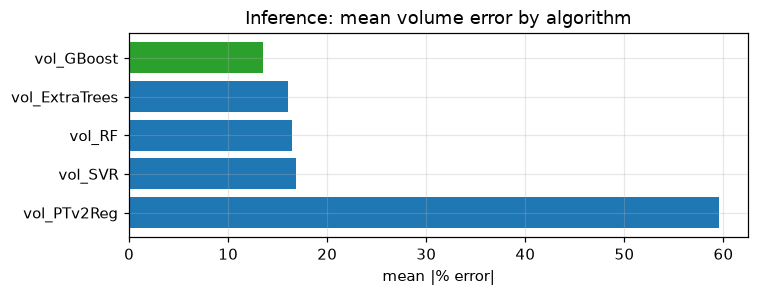

In [ ]:
# ================================================================ INFERENCE: ALL VOLUME METHODS PER FILE
def any_volume_estimate(name, pts):
    """Route any registered volume method (geometry / ML / DL / GNN) to its estimator."""
    try:
        if name in GEO_VOLUME_FNS:
            return float(GEO_VOLUME_FNS[name](pts))
        est, sc = VOL_REG_MODELS[name]
        if isinstance(est, nn.Module) and sc is None:          # point-based DL/GNN reg
            return float(dl_estimate(est, pts))
        if isinstance(est, nn.Module):                         # FeatMLP on features
            with torch.no_grad():
                x = torch.tensor(sc.transform(volume_features(pts).reshape(1, -1)),
                                 dtype=torch.float32, device=HW.device)
                return max(float(np.expm1(est.to(HW.device)(x).item())), 0.0)
        x = sc.transform(volume_features(pts).reshape(1, -1))  # sklearn regressor
        v = float(est.predict(x)[0])
        return max(float(np.expm1(v)) if CONFIG["vol"]["log_target"] else v, 0.0)
    except Exception as e:
        log.warning("[%s] estimate failed: %s", name, e)
        return float("nan")

_all_methods = ([n for n in GEO_VOLUME_FNS if n in VOL_RESULTS or
                 CONFIG["enabled"].get(n, False)]
                + [n for n in VOL_REG_MODELS if n not in GEO_VOLUME_FNS])
_ifiles = TEST_FILES or SPLIT["eval"]
if not TEST_FILES:
    log.warning("data/test empty -> demonstrating on eval split")

irows, ierrs = [], []
for f in tqdm(_ifiles, desc="all-method inference"):
    name = os.path.splitext(os.path.basename(f))[0]
    entry = CACHE.get(f)
    pred = (full_cloud_labels(entry) if BEST_SEG.model is not None
            else BEST_SEG.predictor(entry))
    pts_raw, _ = load_pointcloud(f)
    obj = pts_raw[pred == GT_CLASS] if GT_CLASS is not None else pts_raw
    row = {"file": name, "object_points": int(len(obj))}
    erow = {"file": name}
    gtv = GT_VOLUMES.get(name)
    if gtv is not None:
        row["gt_volume"] = gtv
    for m in _all_methods:
        v = any_volume_estimate(m, obj)
        row[m] = round(v, 4) if np.isfinite(v) else np.nan
        if gtv is not None:
            erow[m] = (round(abs(v - gtv) / max(abs(gtv), 1e-9) * 100, 2)
                       if np.isfinite(v) else np.nan)
    irows.append(row)
    if gtv is not None:
        ierrs.append(erow)
HW.cleanup()

INFER_ALL_TABLE = pd.DataFrame(irows)
print("=" * 110)
print("INFERENCE — VOLUME ESTIMATES BY EVERY ALGORITHM (data/test)")
print("=" * 110)
display(INFER_ALL_TABLE)

if ierrs:
    INFER_ERR_TABLE = pd.DataFrame(ierrs)
    _mc = [c for c in INFER_ERR_TABLE.columns if c != "file"]
    INFER_ERR_TABLE["best_method"] = INFER_ERR_TABLE[_mc].astype(float).idxmin(axis=1)
    print("\nINFERENCE — PER-FILE |% ERROR| vs gt_volume.csv (files with GT only)")
    display(INFER_ERR_TABLE)
    _sum = (INFER_ERR_TABLE[_mc].mean().sort_values().round(2)
            .rename("mean_pct_err").to_frame())
    print("\nMEAN |% ERROR| ACROSS INFERENCE FILES (lower = better)")
    display(_sum)
    plt.figure(figsize=(7, 0.32 * len(_sum) + 1.2))
    plt.barh(_sum.index, _sum["mean_pct_err"],
             color=["#2ca02c" if i == 0 else "#1f77b4" for i in range(len(_sum))])
    plt.gca().invert_yaxis(); plt.xlabel("mean |% error|")
    plt.title("Inference: mean volume error by algorithm")
    plt.tight_layout(); plt.show()
else:
    log.info("No inference file matched gt_volume.csv -> estimates only (no error table)")

---
## Conclusions & Learning Notes

- **Reading the benchmark:** mIoU/Dice rank segmentation quality; the composite
  ranking folds in speed and memory — change `CONFIG["rank_weights"]` to match your
  deployment constraints and rerun Section 8 only.
- **Volume:** compare the `MAE` vs `MAE_gtseg` columns — a big gap means your first
  investment should be a better segmenter, not a better volume formula. Geometry
  methods fail systematically on non-watertight scans (see Section 6 intro), which is
  why calibrated regression usually wins.
- **Fairness caveats:** SVM/KNN were trained on capped subsamples (documented);
  geometry segmenters are unsupervised and Hungarian-matched — their scores are
  optimistic upper bounds for such methods.
- **Scaling up:** set `quick_mode=False`, raise epochs, and rerun. Only best models
  are saved; every run is fully tracked in MLflow at the configured URI.


DIAGNOSTIC TABLE  —  MAE breakdown: end-to-end vs oracle segmentation
  seg_cost_MAE  > 0  →  segmentation is hurting this method
  seg_cost_MAE  ≈ 0  →  method is robust to segmentation error
  seg_cost_MAE  < 0  →  model-seg accidentally helped (rare / noise)


,method,family,MAE_end2end,MAE_oracle_seg,seg_cost_MAE,PctErr_end2end,PctErr_oracle,seg_pct_cost
0,vol_SVR,ML-Regression,10.5216,12.9985,-2.4769,12.67,15.81,-3.14
1,vol_RF,ML-Regression,11.2729,15.8536,-4.5807,13.72,19.20,-5.48
2,vol_GBoost,ML-Regression,11.4720,15.0353,-3.5633,14.05,18.18,-4.12
3,vol_ExtraTrees,ML-Regression,11.8978,14.3654,-2.4676,14.51,17.17,-2.66
4,vol_PTv2Reg,DL-Regression,25.0999,23.3588,1.7410,30.99,30.79,0.20



  Average end-to-end MAE       : 14.0528
  Average oracle-seg MAE       : 16.3223
  Average seg cost (MAE)       : -2.2695
  Segmentation's share of error: -16.1%

VERDICT:
🟢  VOLUME ALGORITHM is the bottleneck.
    Segmentation is clean enough — focus on volume method.
   (Only -16% of end-to-end MAE from segmentation.)

  Most hurt by bad segmentation : vol_PTv2Reg
  Most robust to bad segmentation: vol_RF
  Best end-to-end               : vol_SVR
  Best with perfect segmentation: vol_SVR


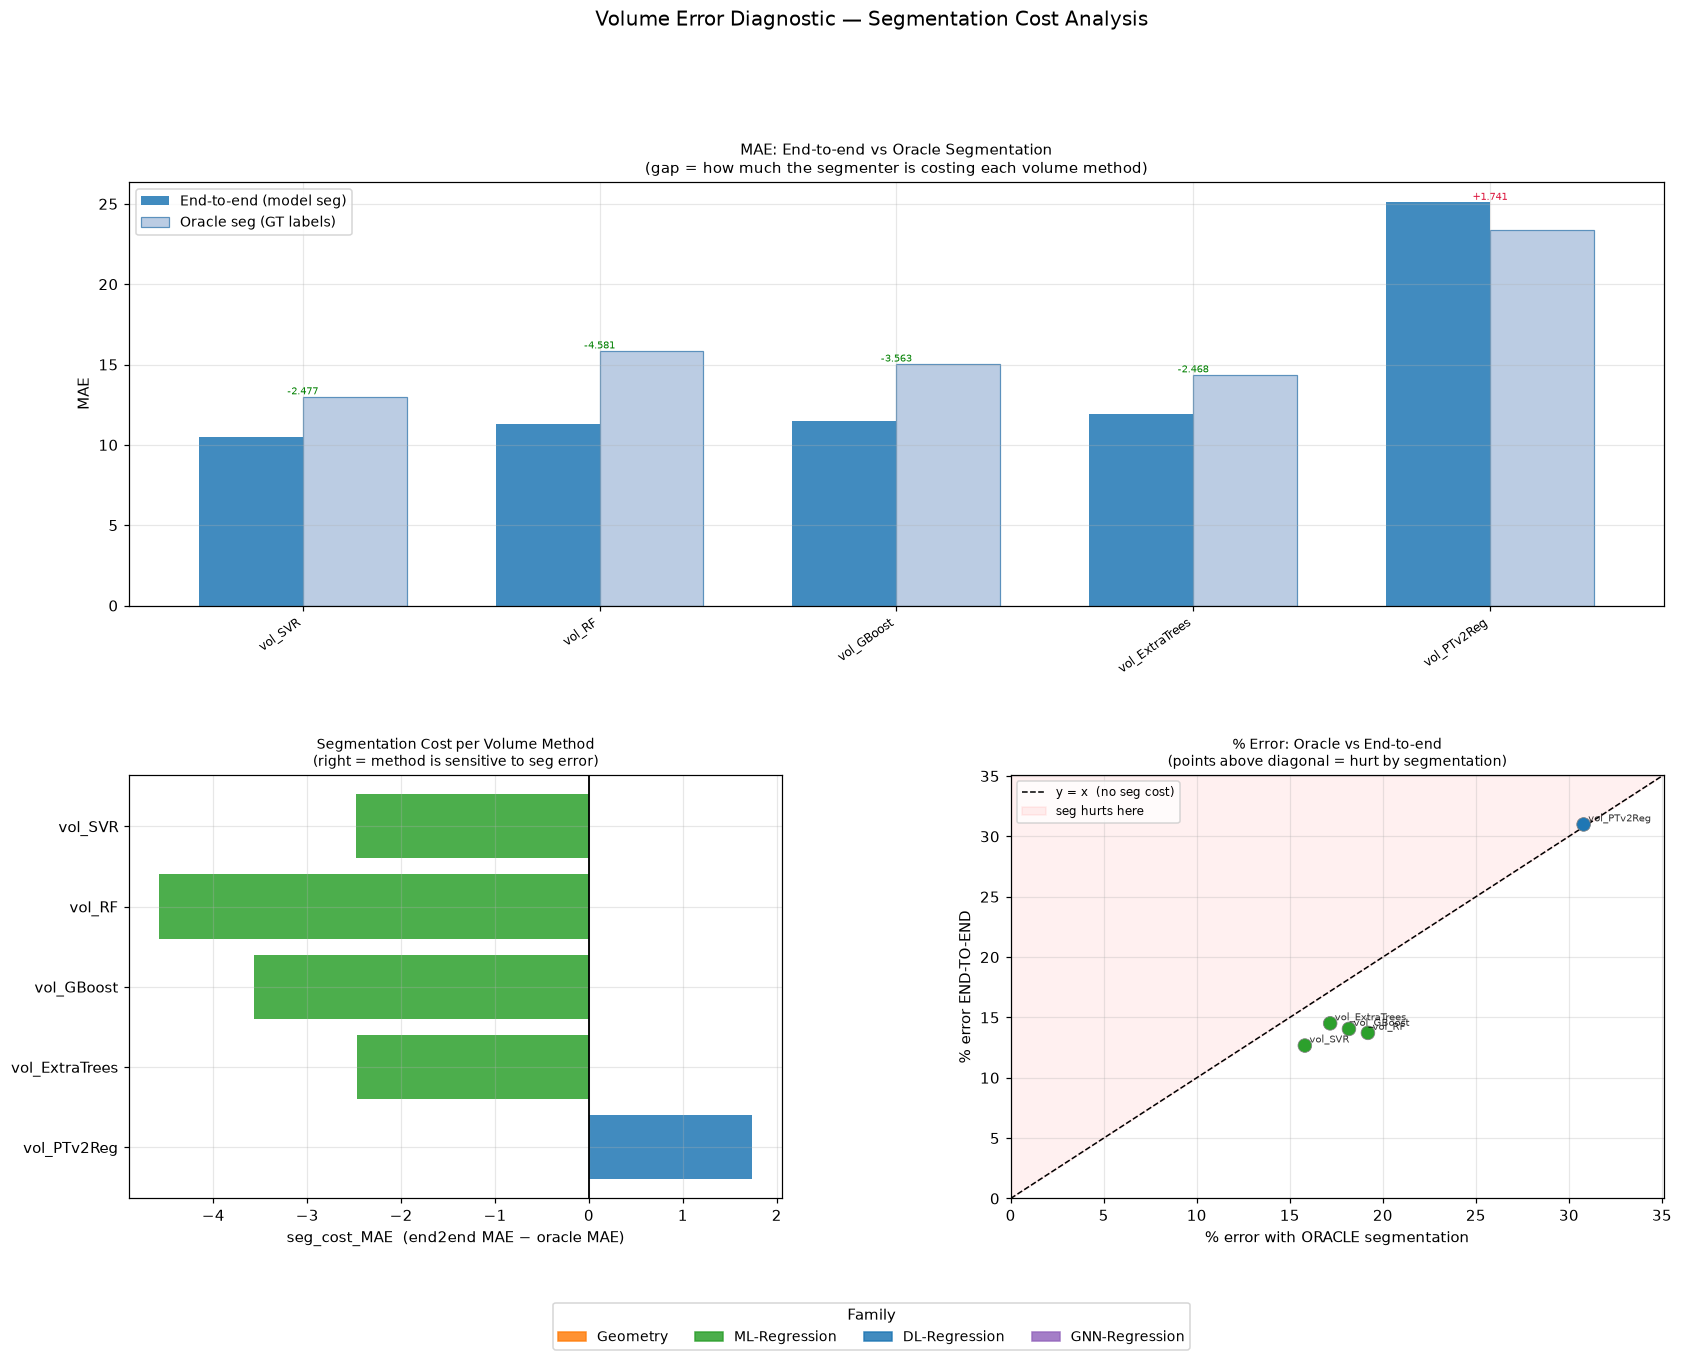

Plot saved: volume_diagnostic.png


In [ ]:
# ================================================================
# VOLUME DIAGNOSTIC: Is the error from SEGMENTATION or VOLUME ALGORITHM?
# Paste this cell right after Section 7 in your benchmark notebook.
# Requires: VOL_RESULTS, VOL_EVAL, VOL_TABLE to already exist.
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ----------------------------------------------------------------
# 1. Rebuild the core diagnostic table cleanly
# ----------------------------------------------------------------
assert VOL_RESULTS and VOL_EVAL, "Run Section 6 & 7 first."

gt = np.array([s["gt_volume"] for s in VOL_EVAL])
_files = [s["name"] for s in VOL_EVAL]

diag_rows = []
for name, r in VOL_RESULTS.items():
    pred_e2e = np.array(r.pred_model_seg, float)   # end-to-end (model segmentation)
    pred_gts = np.array(r.pred_gt_seg,   float)   # oracle   (GT segmentation)

    ok_e = np.isfinite(pred_e2e) & np.isfinite(gt)
    ok_g = np.isfinite(pred_gts) & np.isfinite(gt)

    mae_e2e   = float(np.abs(pred_e2e[ok_e] - gt[ok_e]).mean()) if ok_e.any() else np.nan
    mae_gts   = float(np.abs(pred_gts[ok_g] - gt[ok_g]).mean()) if ok_g.any() else np.nan
    seg_cost  = mae_e2e - mae_gts                           # how much the segmenter hurts

    pct_e2e = float(np.mean(np.abs(pred_e2e[ok_e] - gt[ok_e])
                             / np.clip(np.abs(gt[ok_e]), 1e-9, None) * 100)) \
        if ok_e.any() else np.nan
    pct_gts = float(np.mean(np.abs(pred_gts[ok_g] - gt[ok_g])
                             / np.clip(np.abs(gt[ok_g]), 1e-9, None) * 100)) \
        if ok_g.any() else np.nan

    diag_rows.append({
        "method":           name,
        "family":           r.family,
        "MAE_end2end":      round(mae_e2e, 4),
        "MAE_oracle_seg":   round(mae_gts, 4),
        "seg_cost_MAE":     round(seg_cost, 4),      # KEY column
        "PctErr_end2end":   round(pct_e2e, 2),
        "PctErr_oracle":    round(pct_gts, 2),
        "seg_pct_cost":     round(pct_e2e - pct_gts, 2),
    })

DIAG = pd.DataFrame(diag_rows).sort_values("MAE_end2end").reset_index(drop=True)

print("=" * 90)
print("DIAGNOSTIC TABLE  —  MAE breakdown: end-to-end vs oracle segmentation")
print("  seg_cost_MAE  > 0  →  segmentation is hurting this method")
print("  seg_cost_MAE  ≈ 0  →  method is robust to segmentation error")
print("  seg_cost_MAE  < 0  →  model-seg accidentally helped (rare / noise)")
print("=" * 90)
display(DIAG)

# ----------------------------------------------------------------
# 2. Verdict: where does the dominant error come from?
# ----------------------------------------------------------------
mean_mae_e2e  = DIAG["MAE_end2end"].mean()
mean_mae_gts  = DIAG["MAE_oracle_seg"].mean()
mean_seg_cost = DIAG["seg_cost_MAE"].mean()
seg_share     = mean_seg_cost / max(mean_mae_e2e, 1e-9) * 100

print(f"\n{'='*60}")
print(f"  Average end-to-end MAE       : {mean_mae_e2e:.4f}")
print(f"  Average oracle-seg MAE       : {mean_mae_gts:.4f}")
print(f"  Average seg cost (MAE)       : {mean_seg_cost:.4f}")
print(f"  Segmentation's share of error: {seg_share:.1f}%")
print(f"{'='*60}")

if seg_share > 40:
    verdict = ("🔴  SEGMENTATION is the bottleneck.\n"
               "    Fix the segmenter first — changing volume algorithms won't help much.\n"
               f"   ({seg_share:.0f}% of end-to-end MAE comes from segmentation error.)")
elif seg_share > 15:
    verdict = ("🟡  BOTH contribute meaningfully.\n"
               "    Improve segmentation AND try better volume algorithms in parallel.\n"
               f"   ({seg_share:.0f}% of end-to-end MAE from segmentation.)")
else:
    verdict = ("🟢  VOLUME ALGORITHM is the bottleneck.\n"
               "    Segmentation is clean enough — focus on volume method.\n"
               f"   (Only {seg_share:.0f}% of end-to-end MAE from segmentation.)")

print(f"\nVERDICT:\n{verdict}\n")

# ----------------------------------------------------------------
# 3. Per-method robustness: which volume algo suffers most from bad seg?
# ----------------------------------------------------------------
most_hurt    = DIAG.loc[DIAG["seg_cost_MAE"].idxmax(),  "method"]
least_hurt   = DIAG.loc[DIAG["seg_cost_MAE"].idxmin(),  "method"]
best_e2e     = DIAG.iloc[0]["method"]
best_oracle  = DIAG.sort_values("MAE_oracle_seg").iloc[0]["method"]

print(f"  Most hurt by bad segmentation : {most_hurt}")
print(f"  Most robust to bad segmentation: {least_hurt}")
print(f"  Best end-to-end               : {best_e2e}")
print(f"  Best with perfect segmentation: {best_oracle}")

# ----------------------------------------------------------------
# 4. Plots
# ----------------------------------------------------------------
fam_col = {"Geometry": "#ff7f0e", "ML-Regression": "#2ca02c",
           "DL-Regression": "#1f77b4", "GNN-Regression": "#9467bd"}
colors  = [fam_col.get(f, "gray") for f in DIAG["family"]]

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# ── Plot A: MAE end-to-end vs oracle (paired bars) ──
ax0 = fig.add_subplot(gs[0, :])          # full width
x   = np.arange(len(DIAG))
w   = 0.35
bars1 = ax0.bar(x - w/2, DIAG["MAE_end2end"],  w, label="End-to-end (model seg)", alpha=0.85)
bars2 = ax0.bar(x + w/2, DIAG["MAE_oracle_seg"], w, label="Oracle seg (GT labels)", alpha=0.85,
                color="lightsteelblue", edgecolor="steelblue", linewidth=0.8)
ax0.set_xticks(x)
ax0.set_xticklabels(DIAG["method"], rotation=35, ha="right", fontsize=8)
ax0.set_ylabel("MAE")
ax0.set_title("MAE: End-to-end vs Oracle Segmentation\n"
              "(gap = how much the segmenter is costing each volume method)", fontsize=10)
ax0.legend(fontsize=9)
ax0.grid(axis="y", alpha=0.3)
# annotate gap
for i, (e, g) in enumerate(zip(DIAG["MAE_end2end"], DIAG["MAE_oracle_seg"])):
    gap = e - g
    if abs(gap) > 1e-6:
        ax0.annotate(f"+{gap:.3f}" if gap > 0 else f"{gap:.3f}",
                     xy=(i, max(e, g)), ha="center", va="bottom",
                     fontsize=6.5, color="crimson" if gap > 0 else "green")

# ── Plot B: seg_cost_MAE bar (who is hurt most) ──
ax1 = fig.add_subplot(gs[1, 0])
ax1.barh(DIAG["method"], DIAG["seg_cost_MAE"], color=colors, alpha=0.85)
ax1.axvline(0, color="black", lw=1.2)
ax1.set_xlabel("seg_cost_MAE  (end2end MAE − oracle MAE)")
ax1.set_title("Segmentation Cost per Volume Method\n"
              "(right = method is sensitive to seg error)", fontsize=9)
ax1.invert_yaxis()
ax1.grid(axis="x", alpha=0.3)

# ── Plot C: % error comparison ──
ax2 = fig.add_subplot(gs[1, 1])
ax2.scatter(DIAG["PctErr_oracle"], DIAG["PctErr_end2end"],
            c=colors, s=80, zorder=3, edgecolors="gray", linewidths=0.5)
lim = [0, max(DIAG["PctErr_end2end"].max(), DIAG["PctErr_oracle"].max()) * 1.1 + 1]
ax2.plot(lim, lim, "k--", lw=1, label="y = x  (no seg cost)")
ax2.fill_between(lim, lim, [lim[1]]*2, alpha=0.06, color="red",
                 label="seg hurts here")
for _, row in DIAG.iterrows():
    ax2.annotate(row["method"], (row["PctErr_oracle"], row["PctErr_end2end"]),
                 fontsize=6.5, alpha=0.8, xytext=(3, 2), textcoords="offset points")
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_xlabel("% error with ORACLE segmentation")
ax2.set_ylabel("% error END-TO-END")
ax2.set_title("% Error: Oracle vs End-to-end\n"
              "(points above diagonal = hurt by segmentation)", fontsize=9)
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# legend for family colors
handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.85)
           for c in fam_col.values()]
fig.legend(handles, fam_col.keys(),
           loc="lower center", ncol=4, fontsize=9, title="Family",
           bbox_to_anchor=(0.5, -0.01))

plt.suptitle("Volume Error Diagnostic — Segmentation Cost Analysis", fontsize=13, y=1.01)
plt.savefig("volume_diagnostic.png", dpi=130, bbox_inches="tight")
plt.show()
print("Plot saved: volume_diagnostic.png")

## 12 · Target-Only Segmentation + Volume  

এই সেকশনটি **শুধুমাত্র wood-powder (target class) পয়েন্টগুলো** দেখায় — floor / wall / বাকি environment বাদ দিয়ে — এবং **শুধু সেই target-এর volume** estimate করে।  
আগের কোনো cell পরিবর্তন করা হয়নি; এটি বিদ্যমান `full_cloud_labels`, `best_volume_estimate`, `GT_CLASS` reuse করে।


In [ ]:
# ================================================================ TARGET-ONLY VIS + VOLUME
# শুধু wood-powder (GT_CLASS) দেখায় ও তার volume বের করে। অন্য কিছু render হয় না।

assert GT_CLASS is not None, "GT_CLASS undefined — Section 2 আগে চালান।"

def _clean_target_points(obj, eps_m=0.15, min_pts=10):
    """Stray mis-labeled points বাদ দিয়ে largest DBSCAN cluster রাখে।
    (Open3D থাকলে সেটা, নাহলে sklearn fallback — Colab-safe)."""
    if len(obj) < min_pts:
        return obj
    try:
        if HAS_OPEN3D:
            p = o3d.geometry.PointCloud()
            p.points = o3d.utility.Vector3dVector(obj.astype(np.float64))
            lab = np.asarray(p.cluster_dbscan(eps=eps_m, min_points=max(4, min_pts // 2)))
        else:
            from sklearn.cluster import DBSCAN
            lab = DBSCAN(eps=eps_m, min_samples=max(4, min_pts // 2)).fit_predict(obj)
        valid = lab[lab >= 0]
        if valid.size == 0:
            return obj
        keep = np.bincount(valid).argmax()
        sub = obj[lab == keep]
        return sub if len(sub) >= min_pts else obj
    except Exception as e:
        log.warning("[TARGET] cluster clean skipped (%s)", e)
        return obj

def show_target_only(obj, vol_info="", name=""):
    """শুধু target পয়েন্ট + bounding box + convex hull দেখায়।"""
    if not HAS_OPEN3D:
        log.warning("open3d missing -> target window skipped"); return
    if len(obj) < 10:
        log.warning("[TARGET] too few points to show: %s", name); return
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(
        obj.astype(np.float64) - np.mean(obj.astype(np.float64), axis=0))
    pcd.paint_uniform_color(PALETTE[GT_CLASS % len(PALETTE)])
    geoms = [pcd, pcd.get_axis_aligned_bounding_box()]
    try:
        hull, _ = pcd.compute_convex_hull()
        ls = o3d.geometry.LineSet.create_from_triangle_mesh(hull)
        ls.paint_uniform_color([0.1, 0.1, 0.9]); geoms.append(ls)
    except Exception:
        pass
    _o3d_show(geoms, f"TARGET (wood powder) | {name} | {vol_info}")

# ---------------------------------------------------------------- run
_infer_files = TEST_FILES or SPLIT["eval"]
if not TEST_FILES:
    log.warning("data/test empty -> target-only demo on eval split")

TARGET_ROWS = []
for _i, f in enumerate(_infer_files):
    name = os.path.splitext(os.path.basename(f))[0]
    pts_raw, _ = load_pointcloud(f)
    entry = CACHE.get(f)
    pred = (full_cloud_labels(entry) if BEST_SEG.model is not None
            else BEST_SEG.predictor(entry))

    obj_raw = pts_raw[pred == GT_CLASS]              # শুধু target class
    obj = _clean_target_points(obj_raw)             # stray points বাদ
    vol, method = best_volume_estimate(obj)

    row = {"file": name, "n_total": len(pts_raw),
           "n_target_raw": int(len(obj_raw)),
           "n_target_clean": int(len(obj)),
           "target_volume": vol, "volume_method": method,
           "seg_model": BEST_SEG_NAME}
    if name in GT_VOLUMES:
        row["gt_volume"] = GT_VOLUMES[name]
        row["pct_error"] = abs(vol - GT_VOLUMES[name]) / max(abs(GT_VOLUMES[name]), 1e-9) * 100
    TARGET_ROWS.append(row)

    if _i < CONFIG["vis"]["max_vis_samples"]:
        show_target_only(obj, vol_info=f"V={vol:.4f} m^3 ({method})", name=name)

if isinstance(BEST_SEG.model, nn.Module):
    BEST_SEG.model.to("cpu")
HW.cleanup()

TARGET_TABLE = pd.DataFrame(TARGET_ROWS)
print("TARGET-ONLY VOLUME RESULTS (wood powder)")
display(TARGET_TABLE.round(4))


TARGET-ONLY VOLUME RESULTS (wood powder)


,file,n_total,n_target_raw,n_target_clean,target_volume,volume_method,seg_model,gt_volume,pct_error
0,sample_data_0046,601991,466224,461957,76.1469,vol_SVR,RandomForest,64.0,18.9795
1,sample_data_0047,678899,513553,513150,69.6514,vol_SVR,RandomForest,45.0,54.7809
2,sample_data_0048,506292,343137,340594,87.2620,vol_SVR,RandomForest,81.0,7.7309
3,sample_data_0049,717491,499259,497406,81.5960,vol_SVR,RandomForest,80.0,1.9950
4,sample_data_0050,453747,322018,316931,80.6090,vol_SVR,RandomForest,70.0,15.1557
5,sample_data_0051,727068,443541,442961,74.7489,vol_SVR,RandomForest,56.0,33.4801
6,sample_data_0052,501649,308105,306358,78.4871,vol_SVR,RandomForest,67.0,17.1450
7,sample_data_0053,606372,402654,402271,83.4875,vol_SVR,RandomForest,86.0,2.9215
8,sample_data_0054,552492,355282,349555,83.3770,vol_SVR,RandomForest,98.0,14.9214
9,sample_data_0055,459550,364197,363389,74.9408,vol_SVR,RandomForest,64.0,17.0950


## 13 · Speed Fix — GPU offload বন্ধ করে দ্রুত inference/volume  

সমস্যা: প্রতিটা eval/inference file-এর জন্য model বারবার GPU→CPU move হচ্ছিল 
(`predict_full_cloud`-এ `.to(GPU)` এবং predictor/`full_cloud_labels`-এ `.to("cpu")` + 
`torch.cuda.empty_cache()`)। এই per-file load/offload-ই মূল দেরির কারণ।  

এই cell একটা **context manager `keep_model_resident()`** দেয় যা loop চলাকালীন model-কে 
একবারই GPU-তে রাখে ও per-file offload বন্ধ করে। RTX 3060 (11.6 GB)-এ একটা seg-model + 
একটা cloud-এর chunk সহজেই ধরে, তাই per-file cleanup অপ্রয়োজনীয়।  

**কোনো পুরনো cell বদলানো হয়নি** — এটা runtime-এ monkey-patch করে, `with` block শেষে সব 
আগের মতো restore করে দেয়। Section 12 চালানোর আগে এই cell একবার run করুন।


In [ ]:
# ================================================================ SPEED FIX: keep model resident
import contextlib, types

@contextlib.contextmanager
def keep_model_resident(model=None):
    """Loop চলাকালীন model GPU-তে ধরে রাখে; per-file .to("cpu")/empty_cache() বন্ধ রাখে।
    with-block শেষে HW.cleanup / full_cloud_labels আগের আচরণে restore হয়।

    ব্যবহার:
        with keep_model_resident():
            ...  # Section 12 বা VOL_EVAL build বা inference loop এখানে
    """
    m = model if model is not None else getattr(BEST_SEG, "model", None)

    # 1) model একবার GPU-তে (torch হলে)
    if isinstance(m, nn.Module):
        m.to(HW.device); m.eval()

    # 2) HW.cleanup() no-op করে দিই (loop-এ per-file empty_cache/sync এড়াতে)
    _orig_cleanup = HW.cleanup
    HW.cleanup = types.MethodType(lambda self: None, HW)

    # 3) full_cloud_labels-এর ভেতরের per-cloud offload বাদ:
    #    torch হলে predict_full_cloud সরাসরি ব্যবহার করি, .to("cpu") ছাড়া।
    _orig_fcl = globals().get("full_cloud_labels")
    def _fast_full_cloud_labels(entry):
        if isinstance(BEST_SEG.model, nn.Module):
            return predict_full_cloud(BEST_SEG.model, entry)   # NO offload
        # classical ML path — অপরিবর্তিত
        n = len(entry["norm"]); out = np.empty(n, np.int64)
        for s in range(0, n, 100_000):
            idx = np.arange(s, min(s + 100_000, n))
            out[idx] = BEST_SEG.model.predict(
                SCALER.transform(point_features(entry["norm"], idx)))
        return out
    globals()["full_cloud_labels"] = _fast_full_cloud_labels

    try:
        yield
    finally:
        HW.cleanup = _orig_cleanup
        if _orig_fcl is not None:
            globals()["full_cloud_labels"] = _orig_fcl
        if isinstance(m, nn.Module):
            m.to("cpu")
        _orig_cleanup()          # block শেষে একবারই VRAM ছাড়ে

log.info("[SPEED] keep_model_resident() ready — Section 12 কে "
         "`with keep_model_resident():` দিয়ে wrap করুন দ্রুততার জন্য।")


2026-07-08 22:50:05,278 | INFO    | [SPEED] keep_model_resident() ready — Section 12 কে `with keep_model_resident():` দিয়ে wrap করুন দ্রুততার জন্য।


### 13·A — Section 12 এর দ্রুত (offload-free) version  
Section 12 এর একই কাজ, কিন্তু পুরো loop `keep_model_resident()`-এর ভেতরে — 
model একবার GPU-তে ওঠে, per-file offload হয় না। **এই cell চালালে Section 12 আলাদা করে চালানোর দরকার নেই।**


In [ ]:
# ================================================================ TARGET-ONLY (FAST, no offload)
assert GT_CLASS is not None, "GT_CLASS undefined — Section 2 আগে চালান।"

_infer_files = TEST_FILES or SPLIT["eval"]
if not TEST_FILES:
    log.warning("data/test empty -> target-only demo on eval split")

TARGET_ROWS = []
with keep_model_resident():                 # <-- model একবার GPU-তে, offload বন্ধ
    for _i, f in enumerate(_infer_files):
        name = os.path.splitext(os.path.basename(f))[0]
        pts_raw, _ = load_pointcloud(f)
        entry = CACHE.get(f)
        pred = (full_cloud_labels(entry) if BEST_SEG.model is not None
                else BEST_SEG.predictor(entry))

        obj_raw = pts_raw[pred == GT_CLASS]
        obj = _clean_target_points(obj_raw)
        vol, method = best_volume_estimate(obj)

        row = {"file": name, "n_total": len(pts_raw),
               "n_target_raw": int(len(obj_raw)),
               "n_target_clean": int(len(obj)),
               "target_volume": vol, "volume_method": method,
               "seg_model": BEST_SEG_NAME}
        if name in GT_VOLUMES:
            row["gt_volume"] = GT_VOLUMES[name]
            row["pct_error"] = abs(vol - GT_VOLUMES[name]) / max(abs(GT_VOLUMES[name]), 1e-9) * 100
        TARGET_ROWS.append(row)

        if _i < CONFIG["vis"]["max_vis_samples"]:
            show_target_only(obj, vol_info=f"V={vol:.4f} m^3 ({method})", name=name)
# with-block শেষে model CPU-তে ফেরে, VRAM একবারই ছাড়ে

TARGET_TABLE = pd.DataFrame(TARGET_ROWS)
print("TARGET-ONLY VOLUME RESULTS (wood powder) — fast, offload-free")
display(TARGET_TABLE.round(4))


TARGET-ONLY VOLUME RESULTS (wood powder) — fast, offload-free


,file,n_total,n_target_raw,n_target_clean,target_volume,volume_method,seg_model,gt_volume,pct_error
0,sample_data_0046,601991,466224,461957,76.1469,vol_SVR,RandomForest,64.0,18.9795
1,sample_data_0047,678899,513553,513150,69.6514,vol_SVR,RandomForest,45.0,54.7809
2,sample_data_0048,506292,343137,340594,87.2620,vol_SVR,RandomForest,81.0,7.7309
3,sample_data_0049,717491,499259,497406,81.5960,vol_SVR,RandomForest,80.0,1.9950
4,sample_data_0050,453747,322018,316931,80.6090,vol_SVR,RandomForest,70.0,15.1557
5,sample_data_0051,727068,443541,442961,74.7489,vol_SVR,RandomForest,56.0,33.4801
6,sample_data_0052,501649,308105,306358,78.4871,vol_SVR,RandomForest,67.0,17.1450
7,sample_data_0053,606372,402654,402271,83.4875,vol_SVR,RandomForest,86.0,2.9215
8,sample_data_0054,552492,355282,349555,83.3770,vol_SVR,RandomForest,98.0,14.9214
9,sample_data_0055,459550,364197,363389,74.9408,vol_SVR,RandomForest,64.0,17.0950


## 14 · Surface-Under Volume — pile-এর নিচের আয়তন (convex-hull-এর extra অংশ বাদ)  

সমস্যা: LiDAR শুধু pile-এর outer shell scan করেছে, floor নেই। convex hull / alpha-shape 
সব points-কে উত্তল খোলসে মুড়ে দেয়, তাই pile-এর concave (অবতল) surface-এর উপরের ফাঁকা জায়গাও 
volume-এ ঢুকে যায় — ছবির লাল **"extra part"**।  

সমাধান — **2.5D height-map integration** (`vol_SurfaceUnder`): pile উপর থেকে দেখে প্রতিটা 
(x,y) grid-cell-এ top surface height নেওয়া হয়, target points-এর নিচু level = floor baseline, 
তারপর প্রতি column-এর `(top - floor) × cell_area` যোগ করা হয়। শুধু **surface-এর নিচের** ভরাট 
আয়তন আসে, উপরের খালি অংশ নয়।  

কোনো পুরনো cell বদলানো হয়নি — এটা `GEO_VOLUME_FNS`-এ নতুন method যোগ করে এবং একটা 
`estimate_target_volume()` helper দেয় যা Section 12/13A সরাসরি ব্যবহার করতে পারে।


In [ ]:
# ================================================================ SURFACE-UNDER VOLUME (2.5D)
# pile-এর top surface-এর নিচের আয়তন। convex-hull-এর উপরের "extra part" বাদ যায়।

def vol_surface_under(pts, cell=None, floor_pct=2.0, top_stat="max"):
    """2.5D height-map integration for a pile scanned as an outer shell (no floor).

    ধাপ:
      1) horizontal plane-টা বড় extent দুটো axis দিয়ে নেওয়া হয় (সাধারণত x,y)।
      2) grid cell-এ ভাগ করে প্রতি cell-এর top height = সেই cell-এর points-এর max
         (বা 95th pct)।
      3) floor baseline = সব target points-এর নিচের floor_pct percentile height
         (stray নিচু point robust করে)।
      4) volume = Σ  max(top_cell - floor, 0) × cell_area।

    Params
      cell      : grid cell size (m)। None হলে CONFIG["vol"]["voxel"]*4 (density-safe)।
      floor_pct : floor baseline percentile (নিচের দিক থেকে)।
      top_stat  : "max" (shell-এর প্রকৃত top) বা "p95" (stray উঁচু point robust)।
    """
    p = _clean_pts(pts, cap=1_000_000)
    if len(p) < 8:
        return float("nan")

    ext = p.max(0) - p.min(0)
    # উপরের axis = সবচেয়ে ছোট extent (height); বাকি দুটো = horizontal plane
    up = int(np.argmin(ext))
    horiz = [a for a in range(3) if a != up]
    h = p[:, horiz]                    # (N,2) plane coords
    z = p[:, up]                       # height along pile axis

    cs = cell or (CONFIG["vol"]["voxel"] * 4.0)
    ij = np.floor((h - h.min(0)) / cs).astype(np.int64)
    key = ij[:, 0] * 2_000_003 + ij[:, 1]

    order = np.argsort(key)
    ks, zs = key[order], z[order]
    bounds = np.r_[0, np.flatnonzero(np.diff(ks)) + 1]
    if top_stat == "p95":
        # per-cell 95th percentile (stray উঁচু point বাদ)
        seg_ids = np.repeat(np.arange(len(bounds)), np.diff(np.r_[bounds, len(zs)]))
        top = np.array([np.percentile(zs[seg_ids == g], 95) for g in range(len(bounds))])
    else:
        top = np.maximum.reduceat(zs, bounds)          # per-cell max height

    floor = float(np.percentile(z, floor_pct))         # robust floor baseline
    col_h = np.clip(top - floor, 0.0, None)            # প্রতি column-এর উচ্চতা
    return float(col_h.sum() * cs * cs)                 # Σ height × cell_area


# GEO registry-তে যোগ (এখন benchmark/BEST auto-select-এও অংশ নিতে পারে)
GEO_VOLUME_FNS["vol_SurfaceUnder"] = vol_surface_under


def estimate_volume_by_method(pts, method):
    """যেকোনো নির্দিষ্ট volume method নাম দিয়ে route করে — geometry (GEO_VOLUME_FNS)
    বা ML regression (VOL_REG_MODELS) দুটোই। best_volume_estimate()-এর মতো নয়,
    এটা সবসময় দেওয়া method-ই ব্যবহার করে, global BEST_VOL_NAME নয়।"""
    if method in GEO_VOLUME_FNS:
        return float(GEO_VOLUME_FNS[method](pts)), method
    if method in VOL_REG_MODELS:
        est, sc = VOL_REG_MODELS[method]
        if isinstance(est, nn.Module) and sc is None:
            return dl_estimate(est, pts), method
        if isinstance(est, nn.Module):                    # FeatMLP
            with torch.no_grad():
                x = torch.tensor(sc.transform(volume_features(pts).reshape(1, -1)),
                                 dtype=torch.float32, device=HW.device)
                return max(float(np.expm1(est(x).item())), 0.0), method
        x = sc.transform(volume_features(pts).reshape(1, -1))
        v = float(est.predict(x)[0])
        return max(float(np.expm1(v)) if CONFIG["vol"]["log_target"] else v, 0.0), method
    return best_volume_estimate(pts)                      # unknown -> global best fallback


def estimate_target_volume(pts, method="vol_SurfaceUnder"):
    """Target points → volume, নির্দিষ্ট method দিয়ে (default: surface-under)।
    method geometry বা ML regression যেকোনো নাম হতে পারে (GEO_VOLUME_FNS / VOL_REG_MODELS)।
    Section 12/13A-তে best_volume_estimate() এর বদলে ব্যবহার করুন সঠিক pile volume-এর জন্য।
    """
    return estimate_volume_by_method(pts, method)

log.info("[VOL] vol_SurfaceUnder ready. Section 12/13A-তে "
         "`estimate_target_volume(obj)` ব্যবহার করুন (best_volume_estimate এর বদলে)।")


2026-07-08 22:56:48,265 | INFO    | [VOL] vol_SurfaceUnder ready. Section 12/13A-তে `estimate_target_volume(obj)` ব্যবহার করুন (best_volume_estimate এর বদলে)।


### 14·A — Target-only + **surface-under** volume (final)  
Section 13A এর মতোই, কিন্তু volume `estimate_target_volume()` (surface-under) দিয়ে — 
convex-hull-এর extra অংশ ছাড়া। visualization-এ hull wireframe বাদ, শুধু target + bbox।


In [ ]:
# ================================================================ TARGET-ONLY + SURFACE-UNDER VOL
assert GT_CLASS is not None, "GT_CLASS undefined — Section 2 আগে চালান।"
assert "vol_SurfaceUnder" in GEO_VOLUME_FNS, "Section 14 আগে চালান।"

def show_target_clean(obj, vol_info="", name=""):
    """শুধু target points + axis-aligned bbox (convex-hull wireframe ছাড়া)।"""
    if not HAS_OPEN3D or len(obj) < 10:
        return
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(
        obj.astype(np.float64) - np.mean(obj.astype(np.float64), axis=0))
    pcd.paint_uniform_color(PALETTE[GT_CLASS % len(PALETTE)])
    _o3d_show([pcd, pcd.get_axis_aligned_bounding_box()],
              f"TARGET (surface-under) | {name} | {vol_info}")

_infer_files = TEST_FILES or SPLIT["eval"]
if not TEST_FILES:
    log.warning("data/test empty -> demo on eval split")

TARGET_ROWS = []
with keep_model_resident():
    for _i, f in enumerate(_infer_files):
        name = os.path.splitext(os.path.basename(f))[0]
        pts_raw, _ = load_pointcloud(f)
        entry = CACHE.get(f)
        pred = (full_cloud_labels(entry) if BEST_SEG.model is not None
                else BEST_SEG.predictor(entry))

        obj_raw = pts_raw[pred == GT_CLASS]
        obj = _clean_target_points(obj_raw)
        vol, method = estimate_target_volume(obj)       # <-- surface-under

        row = {"file": name, "n_total": len(pts_raw),
               "n_target_raw": int(len(obj_raw)),
               "n_target_clean": int(len(obj)),
               "target_volume": vol, "volume_method": method,
               "seg_model": BEST_SEG_NAME}
        if name in GT_VOLUMES:
            row["gt_volume"] = GT_VOLUMES[name]
            row["pct_error"] = abs(vol - GT_VOLUMES[name]) / max(abs(GT_VOLUMES[name]), 1e-9) * 100
        TARGET_ROWS.append(row)

        if _i < CONFIG["vis"]["max_vis_samples"]:
            show_target_clean(obj, vol_info=f"V={vol:.4f} m^3", name=name)

TARGET_TABLE = pd.DataFrame(TARGET_ROWS)
print("TARGET-ONLY SURFACE-UNDER VOLUME (wood powder)")
display(TARGET_TABLE.round(4))


TARGET-ONLY SURFACE-UNDER VOLUME (wood powder)


,file,n_total,n_target_raw,n_target_clean,target_volume,volume_method,seg_model,gt_volume,pct_error
0,sample_data_0046,601991,466224,461957,76.8547,vol_SurfaceUnder,RandomForest,64.0,20.0855
1,sample_data_0047,678899,513553,513150,42.6120,vol_SurfaceUnder,RandomForest,45.0,5.3068
2,sample_data_0048,506292,343137,340594,76.1308,vol_SurfaceUnder,RandomForest,81.0,6.0114
3,sample_data_0049,717491,499259,497406,95.1617,vol_SurfaceUnder,RandomForest,80.0,18.9522
4,sample_data_0050,453747,322018,316931,88.5686,vol_SurfaceUnder,RandomForest,70.0,26.5266
5,sample_data_0051,727068,443541,442961,73.5537,vol_SurfaceUnder,RandomForest,56.0,31.3460
6,sample_data_0052,501649,308105,306358,70.5252,vol_SurfaceUnder,RandomForest,67.0,5.2615
7,sample_data_0053,606372,402654,402271,91.5387,vol_SurfaceUnder,RandomForest,86.0,6.4403
8,sample_data_0054,552492,355282,349555,107.7289,vol_SurfaceUnder,RandomForest,98.0,9.9275
9,sample_data_0055,459550,364197,363389,77.7080,vol_SurfaceUnder,RandomForest,64.0,21.4188


## 15 · Wall Removal — ভুল-labeled উল্লম্ব সমতল (wall) বাদ দিয়ে volume  

model কিছু **wall points** wood-powder হিসেবে ধরছে (ছবির বিচ্ছিন্ন সবুজ patch)। wall হলো 
**উল্লম্ব সমতল** — powder pile নয়। তাই volume-এর আগে geometric guard দিয়ে সেগুলো বাদ দিই 
(retrain ছাড়াই এখনই কাজ করে)।  

`remove_walls()` তিন স্তরে পরিষ্কার করে:  
1. **Statistical outlier removal** — sparse বিচ্ছিন্ন point বাদ।  
2. **Vertical-plane RANSAC** — normal প্রায় অনুভূমিক (মানে সমতলটা উল্লম্ব) এমন বড় plane খুঁজে বাদ। 
pile-এর উপরিতল উপরমুখী, তাই এতে pile নিরাপদ থাকে।  
3. **Largest cluster** — বাকিদের মধ্যে মূল স্তূপটাই রাখে।  

Open3D থাকলে সেটা, নাহলে sklearn fallback (Colab-safe)। কোনো পুরনো cell বদলানো হয়নি।


In [ ]:
# ================================================================ WALL REMOVAL (geometric guard)
from sklearn.linear_model import RANSACRegressor
from sklearn.cluster import DBSCAN as _SKDBSCAN

def _statistical_outlier(pts, k=16, std_ratio=2.0):
    """প্রতিটা point-এর k-NN গড় দূরত্ব; global mean+std_ratio*std এর বেশি হলে বাদ।"""
    if len(pts) < k + 1:
        return np.ones(len(pts), bool)
    try:
        from scipy.spatial import cKDTree
        tree = cKDTree(pts)
        d, _ = tree.query(pts, k=k + 1)          # includes self at col 0
        md = d[:, 1:].mean(1)
        thr = md.mean() + std_ratio * md.std()
        return md <= thr
    except Exception:
        return np.ones(len(pts), bool)

def _normals(pts, k=24):
    """প্রতি point-এর surface normal (local PCA-র smallest eigenvector)।"""
    try:
        if HAS_OPEN3D:
            pcd = o3d.geometry.PointCloud()
            pcd.points = o3d.utility.Vector3dVector(pts.astype(np.float64))
            pcd.estimate_normals(o3d.geometry.KDTreeSearchParamKNN(k))
            return np.asarray(pcd.normals)
    except Exception:
        pass
    # fallback: per-neighborhood PCA
    from scipy.spatial import cKDTree
    tree = cKDTree(pts); _, idx = tree.query(pts, k=min(k, len(pts)))
    nrm = np.zeros_like(pts, float)
    for i, nb_i in enumerate(idx):
        q = pts[nb_i] - pts[nb_i].mean(0)
        w, v = np.linalg.eigh(q.T @ q)
        nrm[i] = v[:, 0]
    return nrm

def remove_walls(pts, up_axis=None, vert_normal_cos=0.30,
                 min_wall_frac=0.10, ransac_thr=0.03, n_planes=2,
                 sor_k=16, sor_std=2.0, cluster_eps=0.15):
    """ভুল-labeled উল্লম্ব সমতল (wall) বাদ দিয়ে শুধু powder pile ফেরত দেয়।

    Params
      up_axis        : উপরমুখী axis (None হলে সবচেয়ে ছোট extent = height)।
      vert_normal_cos: |normal·up| < এই মান হলে point-টা উল্লম্ব-সমতলীয় (wall-প্রবণ)।
      min_wall_frac  : RANSAC plane-কে wall গণ্য করতে ন্যূনতম inlier ভগ্নাংশ।
      ransac_thr     : plane inlier দূরত্ব সীমা (m)।
      n_planes       : সর্বোচ্চ কতগুলো wall-plane খুঁজবে।
    """
    p = np.asarray(pts, np.float64)
    if len(p) < 30:
        return p, np.ones(len(p), bool)

    keep = _statistical_outlier(p, sor_k, sor_std)      # (1) SOR
    p1 = p[keep]

    ext = p1.max(0) - p1.min(0)
    up = up_axis if up_axis is not None else int(np.argmin(ext))
    up_vec = np.zeros(3); up_vec[up] = 1.0
    horiz = [a for a in range(3) if a != up]

    nrm = _normals(p1)                                  # (2) normal-based
    vert_like = np.abs(nrm @ up_vec) < vert_normal_cos  # normal অনুভূমিক => সমতল উল্লম্ব

    wall_mask = np.zeros(len(p1), bool)
    cand = np.flatnonzero(vert_like)
    for _ in range(n_planes):
        if len(cand) < max(50, int(min_wall_frac * len(p1))):
            break
        # RANSAC: horizontal coords থেকে depth ফিট করে উল্লম্ব plane শনাক্ত
        X = p1[cand][:, horiz]; y = p1[cand][:, up]
        try:
            r = RANSACRegressor(residual_threshold=ransac_thr, max_trials=200,
                                random_state=0).fit(X, y)
        except Exception:
            break
        inl = r.inlier_mask_
        if inl.sum() < min_wall_frac * len(p1):
            break
        wall_idx = cand[inl]
        wall_mask[wall_idx] = True
        cand = cand[~inl]

    p2 = p1[~wall_mask]                                  # wall বাদ
    if len(p2) < 30:
        p2 = p1                                          # over-removal guard

    # (3) largest cluster
    try:
        if HAS_OPEN3D:
            pc = o3d.geometry.PointCloud()
            pc.points = o3d.utility.Vector3dVector(p2)
            lab = np.asarray(pc.cluster_dbscan(eps=cluster_eps, min_points=8))
        else:
            lab = _SKDBSCAN(eps=cluster_eps, min_samples=8).fit_predict(p2)
        valid = lab[lab >= 0]
        if valid.size:
            main = p2[lab == np.bincount(valid).argmax()]
            if len(main) >= 30:
                p2 = main
    except Exception:
        pass

    # final boolean mask back onto original pts
    final = np.zeros(len(p), bool)
    kept_idx = np.flatnonzero(keep)
    # map p2 rows back via nearest match on kept set
    from scipy.spatial import cKDTree
    tree = cKDTree(p[kept_idx])
    _, mi = tree.query(p2, k=1)
    final[kept_idx[np.unique(mi)]] = True
    return p[final], final


def estimate_target_volume_clean(pts, method="vol_SurfaceUnder", **wall_kw):
    """wall removal + surface-under volume — full clean pipeline।"""
    obj, _ = remove_walls(pts, **wall_kw)
    v, m = estimate_target_volume(obj, method=method)
    return v, m, obj

log.info("[WALL] remove_walls() ready — vertical-plane wall বাদ। "
         "estimate_target_volume_clean(obj) ব্যবহার করুন।")


NameError: name 'log' is not defined

### 15·A — Final: wall-removal + surface-under volume (before/after)  
প্রতিটা file-এ wall বাদ দেওয়ার আগে ও পরে volume আর pct_error পাশাপাশি দেখায়, 
এবং cleaned target visualize করে।


In [ ]:
# ================================================================ FINAL CLEAN VOLUME + COMPARISON
assert GT_CLASS is not None
assert "remove_walls" in globals(), "Section 15 আগে চালান।"

_infer_files = TEST_FILES or SPLIT["eval"]
if not TEST_FILES:
    log.warning("data/test empty -> demo on eval split")

CLEAN_ROWS = []
with keep_model_resident():
    for _i, f in enumerate(_infer_files):
        name = os.path.splitext(os.path.basename(f))[0]
        pts_raw, _ = load_pointcloud(f)
        entry = CACHE.get(f)
        pred = (full_cloud_labels(entry) if BEST_SEG.model is not None
                else BEST_SEG.predictor(entry))
        obj_raw = pts_raw[pred == GT_CLASS]

        # BEFORE: শুধু largest cluster (আগের পদ্ধতি) + surface-under
        obj_before = _clean_target_points(obj_raw)
        v_before, _ = estimate_target_volume(obj_before)

        # AFTER: wall removal + surface-under
        v_after, method, obj_after = estimate_target_volume_clean(obj_raw)

        row = {"file": name,
               "n_raw": int(len(obj_raw)),
               "n_after_wall": int(len(obj_after)),
               "vol_before": round(v_before, 4),
               "vol_after": round(v_after, 4),
               "method": method}
        if name in GT_VOLUMES:
            gt = GT_VOLUMES[name]; row["gt_volume"] = gt
            row["pct_before"] = round(abs(v_before-gt)/max(abs(gt),1e-9)*100, 2)
            row["pct_after"]  = round(abs(v_after -gt)/max(abs(gt),1e-9)*100, 2)
        CLEAN_ROWS.append(row)

        if _i < CONFIG["vis"]["max_vis_samples"]:
            show_target_clean(obj_after, vol_info=f"V={v_after:.4f} m^3 (wall-removed)", name=name)

CLEAN_TABLE = pd.DataFrame(CLEAN_ROWS)
print("WALL-REMOVED SURFACE-UNDER VOLUME  (before vs after)")
display(CLEAN_TABLE)

if "pct_after" in CLEAN_TABLE.columns:
    print(f"\nMean pct-error  BEFORE: {CLEAN_TABLE['pct_before'].mean():.2f}%"
          f"   AFTER: {CLEAN_TABLE['pct_after'].mean():.2f}%")


WALL-REMOVED SURFACE-UNDER VOLUME  (before vs after)


,file,n_raw,n_after_wall,vol_before,vol_after,method,gt_volume,pct_before,pct_after
0,sample_data_0046,466224,448077,76.8547,75.7434,vol_SurfaceUnder,64.0,20.09,18.35
1,sample_data_0047,513553,495688,42.6120,41.6834,vol_SurfaceUnder,45.0,5.31,7.37
2,sample_data_0048,343137,296439,76.1308,74.8903,vol_SurfaceUnder,81.0,6.01,7.54
3,sample_data_0049,499259,480141,95.1617,93.4809,vol_SurfaceUnder,80.0,18.95,16.85
4,sample_data_0050,322018,275481,88.5686,86.4642,vol_SurfaceUnder,70.0,26.53,23.52
5,sample_data_0051,443541,429591,73.5537,72.8734,vol_SurfaceUnder,56.0,31.35,30.13
6,sample_data_0052,308105,264085,70.5252,69.9338,vol_SurfaceUnder,67.0,5.26,4.38
7,sample_data_0053,402654,346060,91.5387,89.8423,vol_SurfaceUnder,86.0,6.44,4.47
8,sample_data_0054,355282,339378,107.7289,106.3213,vol_SurfaceUnder,98.0,9.93,8.49
9,sample_data_0055,364197,348356,77.7080,76.3503,vol_SurfaceUnder,64.0,21.42,19.30



Mean pct-error  BEFORE: 13.57%   AFTER: 13.01%


## 16 · Segmentation উন্নত করা — wall→powder ভুল কমানোর গাইড  

geometric wall-removal (Section 15) এখনই কাজ করবে, কিন্তু আসল সমাধান হলো model-কে wall আর 
powder ভালোভাবে আলাদা করতে শেখানো। নিচের পরিবর্তনগুলো `CONFIG`-এ করে DL benchmark আবার চালান 
(cell 3 + cell 20)।  

**১. Class imbalance ঠিক করা.** wall আর floor-এর point powder-এর চেয়ে অনেক বেশি হলে model 
powder over-predict করে। `CLASS_W` (loss weight) inverse-frequency দিয়ে সেট করা আছে কিনা দেখুন; 
powder class-এ weight বাড়ালে boundary tightening হয়।  

**২. Height-above-floor feature জোর দেওয়া.** 7-channel feature-এ height-above-floor আছে — 
wall উঁচু ও উল্লম্ব, powder নিচু ও চ্যাপ্টা, তাই এটা সবচেয়ে discriminative। normal-এর z-component 
(উপরমুখীতা) feature-এ থাকলে wall আরও সহজে আলাদা হয়।  

**৩. যথেষ্ট training.** আপনার note অনুযায়ী quick_mode-এ DL collapse করে। `CONFIG["quick_mode"]=False` 
রেখে `full.epochs` (400) + `patience` যথেষ্ট রাখুন। PTv2 boundary-aware, তাই wall-powder ধার 
ভালো ধরে — এটাই recommended।  

**৪. Augmentation.** random scale / flip / jitter / point-dropout দিলে model wall-এর সমতল 
গঠনে over-fit না করে powder-এর texture শেখে।  

**৫. Post-process consistency.** inference-এর পর height-above-floor threshold-এর নিচের ও 
vertical-normal point গুলো powder থেকে বাদ দেওয়া — যা Section 15 করছে। train + geometric guard 
একসাথে সবচেয়ে ভালো ফল দেয়।  

চালানোর ক্রম: Section 15/15·A এখনই ব্যবহার করুন (retrain ছাড়া), সমান্তরালে উপরের CONFIG দিয়ে 
PTv2 retrain করে segmentation নিজেই উন্নত করুন।


## 17 · Mesh-Surface Volume (paper-style triangular-mesh integration)  

Chowa Giken paper (attached PDF)-এর পদ্ধতি: segmented target points থেকে triangular mesh বানিয়ে, প্রতিটা triangle-এর XY-plane-এর সাপেক্ষে prism volume বের করে সব যোগ করা হয়। এটা surface-under-এর মতোই ধারণা, কিন্তু grid quantization ছাড়া — সরাসরি mesh triangle থেকে হিসাব, তাই সাধারণত smoother/আরও নির্ভুল।  

`vol_MeshSurface()`: ball-pivoting দিয়ে mesh বানায় (radius auto নেয়া হয় nearest-neighbor দূরত্ব থেকে); ব্যর্থ হলে alpha-shape mesh-এ fallback করে। প্রতি triangle-এর signed projected-XY-area × (mean height − floor baseline) যোগ করে total volume দেয়। `GEO_VOLUME_FNS`-এ যোগ হলো — `estimate_target_volume(obj, method="vol_MeshSurface")` দিয়ে ব্যবহার করা যাবে।


In [ ]:
# ================================================================ MESH-SURFACE VOLUME (paper-style)
def _build_mesh(pcd, nn_mult=(1.5, 2.0, 3.0)):
    """Ball-pivoting mesh; radius auto থেকে average nearest-neighbor distance।
    ব্যর্থ হলে alpha-shape (tetra-based) mesh-এ fallback।"""
    d = pcd.compute_nearest_neighbor_distance()
    avg = float(np.mean(d)) if len(d) else 0.01
    radii = o3d.utility.DoubleVector([avg * m for m in nn_mult])
    try:
        mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(pcd, radii)
        if len(mesh.triangles) >= 4:
            return mesh
    except Exception:
        pass
    try:                                                  # fallback: alpha shape
        mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(
            pcd, alpha=avg * 3.0)
        if len(mesh.triangles) >= 4:
            return mesh
    except Exception:
        pass
    return None


def vol_mesh_surface(pts, floor_pct=2.0):
    """Paper-style: mesh triangle -> XY-plane prism volume, সব যোগ।
    floor_pct percentile-কে floor baseline ধরে height মাপা হয় (LiDAR shell-only
    scan-এ প্রকৃত floor নেই, তাই target points থেকেই estimate)।"""
    if not HAS_OPEN3D:
        return float("nan")
    p = _clean_pts(pts, cap=300_000)
    if len(p) < 30:
        return float("nan")

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(p.astype(np.float64))
    pcd.estimate_normals(o3d.geometry.KDTreeSearchParamKNN(24))
    pcd.orient_normals_consistent_tangent_plane(20)

    mesh = _build_mesh(pcd)
    if mesh is None:
        return float("nan")

    V = np.asarray(mesh.vertices)
    T = np.asarray(mesh.triangles)
    if len(T) == 0:
        return float("nan")

    floor = float(np.percentile(p[:, 2] if p.shape[1] == 3 else p[:, -1], floor_pct))
    v0, v1, v2 = V[T[:, 0]], V[T[:, 1]], V[T[:, 2]]
    cross_z = ((v1[:, 0] - v0[:, 0]) * (v2[:, 1] - v0[:, 1])
              - (v1[:, 1] - v0[:, 1]) * (v2[:, 0] - v0[:, 0]))     # 2x signed XY area
    mean_h = (v0[:, 2] + v1[:, 2] + v2[:, 2]) / 3.0 - floor
    vol = np.abs(np.sum(0.5 * cross_z * mean_h))
    return float(vol)


GEO_VOLUME_FNS["vol_MeshSurface"] = vol_mesh_surface
log.info("[VOL] vol_MeshSurface ready (paper-style triangular-mesh integration).")


NameError: name 'GEO_VOLUME_FNS' is not defined

## 18 · Geometry vs ML-Regression Volume — কোনটা ভালো (empirical)  

আপনার প্রশ্ন: geometry ছাড়া অন্য (regression) ভাবে ভালো volume estimate করা যায় কিনা।  
উত্তর: **হ্যাঁ** — আপনার notebook-এই already ML regression family আছে (`vol_RF`, `vol_ExtraTrees`, `vol_SVR`, `vol_XGBoost`, `vol_LightGBM`, `vol_CatBoost`)। এগুলো `volume_features(pts)` (14-dim geometric feature: n_points, bbox_vol, extents, hull_vol/area, voxel counts, density...) থেকে সরাসরি volume regress করে — geometric formula-র বদলে **learned mapping**। আপনার memory-অনুযায়ী আগে ExtraTrees/SVR/CatBoost geometry-কে হারিয়েছিল। এই cell সেটা **wall-removed target points**-এর উপর সরাসরি যাচাই করে।  

চালানোর ক্রম: Section 15 (wall removal) + Section 17 (mesh) আগে চালান, তারপর এই cell।


In [ ]:
# ================================================================ GEOMETRY vs REGRESSION (empirical)
assert "remove_walls" in globals(), "Section 15 আগে চালান।"

_candidate_methods = ["vol_SurfaceUnder", "vol_MeshSurface"] + list(VOL_REG_MODELS.keys())
_infer_files = TEST_FILES or SPLIT["eval"]
if not TEST_FILES:
    log.warning("data/test empty -> demo on eval split")

METHOD_ROWS = []
with keep_model_resident():
    for f in _infer_files:
        name = os.path.splitext(os.path.basename(f))[0]
        if name not in GT_VOLUMES:
            continue                                       # gt লাগবে error মাপতে
        pts_raw, _ = load_pointcloud(f)
        entry = CACHE.get(f)
        pred = (full_cloud_labels(entry) if BEST_SEG.model is not None
                else BEST_SEG.predictor(entry))
        obj_raw = pts_raw[pred == GT_CLASS]
        obj, _ = remove_walls(obj_raw)                      # wall-cleaned target
        gt = GT_VOLUMES[name]

        for m in _candidate_methods:
            try:
                v, _ = estimate_volume_by_method(obj, m)
            except Exception as e:
                log.warning("[%s] failed on %s (%s)", m, name, e); continue
            if not np.isfinite(v):
                continue
            METHOD_ROWS.append({
                "file": name, "method": m, "volume": v, "gt_volume": gt,
                "pct_error": abs(v - gt) / max(abs(gt), 1e-9) * 100})

METHOD_TABLE = pd.DataFrame(METHOD_ROWS)
SUMMARY = (METHOD_TABLE.groupby("method")["pct_error"]
                       .agg(["mean", "std", "count"])
                       .sort_values("mean"))
print("MEAN pct-ERROR BY METHOD (wall-removed target points, sorted best-first)")
display(SUMMARY.round(2))
print("\nRecommended production method:", SUMMARY.index[0])


2026-07-08 23:17:46,919 | WARNING | [vol_MeshSurface] failed on sample_data_0049 (QH6347 qhull precision error (qh_mergefacet): wide merge for facet f216 into f215 for mergetype 7 (dupridge).  maxdist 1e-05 (109.3x) mindist  0 (-0.0x) vertexdist 3.5e+02  Allow with 'Q12' (allow-wide)
ERRONEOUS FACET:
- f216
    - flags: bottom upperDelaunay newfacet dupridge mergeridge2
    - normal:   -0.1149  -0.9934 -0.0001134 2.14e-06
    - offset:    4550228
    - vertices: p239161(v24) p239032(v22) p193257(v14) p83713(v8)
    - neighboring facets: f189 f219 f214 f215
    - ridges:
     - r253 simplicialtop simplicialbot
           vertices: p239032(v22) p193257(v14) p83713(v8)
           between f189 and f216
     - r254 simplicialtop simplicialbot
           vertices: p239161(v24) p193257(v14) p83713(v8)
           between f216 and f219
     - r255 simplicialtop simplicialbot
           vertices: p239161(v24) p239032(v22) p83713(v8)
           between f214 and f216
     - r256 simplicialtop
    


Qhull messages at ~Qhull()
QH7089 qhull precision warning: The initial hull is narrow.  Is the input lower
dimensional (e.g., a square in 3-d instead of a cube)?  Cosine of the minimum
angle is 0.9999999999999996.  If so, Qhull may produce a wide facet.
Options 'Qs' (search all points), 'Qbb' (scale last coordinate), or
'QbB' (scale to unit box) may remove this warning.
See 'Limitations' in qh-impre.htm.  Use 'Pp' to skip this warning.


2026-07-08 23:26:32,474 | WARNING | [vol_MeshSurface] failed on sample_data_0053 (QH7088 Qhull precision warning: in post-processing (qh_check_maxout) p49450 for f337 is 2.7e-05 above hidden facet f2606 nearest vertices 2.4e+04
QH7088 Qhull precision warning: in post-processing (qh_check_maxout) p227502 for f337 is 3.3e-05 above hidden facet f2606 nearest vertices 2.4e+04
QH6297 Qhull precision error (qh_check_maxout): large increase in qh.max_outside during post-processing dist 3.3e-05 (194.0x).  See warning QH0032/QH0033.  Allow with 'Q12' (allow-wide) and 'Pp'
ERRONEOUS FACET:
- f2606
    - flags: top simplicial upperDelaunay tested
    - normal:   -0.1138  -0.9935 0.001466 1.405e-06
    - offset:    4550209
    - center: 522568.2743588357 4520115.786686205 74.79369157714751 4476688.332275391 
    - maxoutside: 3.253932e-05
    - vertices: p44519(v170) p229854(v73) p256783(v4) p130750(v2)
    - neighboring facets: f1565 f2607 f2370 f2677
    - ridges:
     - r2277 tested simplicialt

: 

: 